In [38]:
import pandas as pd
import os
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("Set2")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 100)

pd.set_option('display.notebook_repr_html', True)

def create_seaborn_boxplot(data, x, y, ax, title, ylabel, xlabel, custom_means=None):
    colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854', '#ffd92f', '#e5c494', '#b3b3b3']
    unique_vals = sorted(data[x].unique())
    palette = colors[:len(unique_vals)]
    
    sns.boxplot(data=data, x=x, y=y, ax=ax, palette=palette,
                medianprops={'color': 'black', 'linewidth': 2.5, 'linestyle': ':'})
    
    # Get the actual order of categories as they appear in the plot
    plot_labels = [tick.get_text() for tick in ax.get_xticklabels()]
    
    if custom_means is not None:
        # Use custom means if provided, mapping them to the correct plot positions
        for i, plot_label in enumerate(plot_labels):
            # Convert plot label back to original category name
            reverse_mapping = {
                'Anthropic': 'anthropic',
                'OpenAI': 'openai', 
                'Google': 'google',
                'DeepSeek': 'deepseek',
                'Common': 'common',
                'Complex': 'complex',
                'Script': 'script',
                'Transcript': 'transcript', 
                'Tanenbaum': 'tanenbaum',
                'Script (Manipulated)': 'script_manipulated',
                'No Source': 'no_source',
                'Exp 1a': '1a',
                'Exp 1b': '1b'
            }
            original_category = reverse_mapping.get(plot_label, plot_label.lower())
            
            if original_category in custom_means.index:
                mean_val = custom_means[original_category]
                ax.scatter(i, mean_val, color='red', marker='D', s=50, zorder=3, 
                          edgecolor='darkred', linewidth=1)
    else:
        # Use original behavior if no custom means provided
        for i, val in enumerate(unique_vals):
            mean_val = data[data[x] == val][y].mean()
            ax.scatter(i, mean_val, color='red', marker='D', s=50, zorder=3, 
                      edgecolor='darkred', linewidth=1)
    
    label_mapping = {
        'anthropic': 'Anthropic',
        'openai': 'OpenAI', 
        'google': 'Google',
        'deepseek': 'DeepSeek',
        'common': 'Common',
        'complex': 'Complex',
        'script': 'Script',
        'transcript': 'Transcript', 
        'tanenbaum': 'Tanenbaum',
        'script_manipulated': 'Script (Manipulated)',
        'no_source': 'No Source',
        '1a': 'Exp 1a',
        '1b': 'Exp 1b'
    }
    
    current_labels = [tick.get_text() for tick in ax.get_xticklabels()]
    new_labels = [label_mapping.get(label, label) for label in current_labels]
    ax.set_xticklabels(new_labels, rotation=0)
    
    if 'cosine_similarity' in y.lower():
        ylabel = 'Cosine Similarity'
        if '(-1 to 1)' not in title:
            title = title.replace('Cosine Similarity', 'Cosine Similarity (-1 to 1)')
    elif 'adherence_score' in y.lower():
        ylabel = 'Adherence Score'
        if '(0 to 1)' not in title:
            title = title.replace('Adherence Score', 'Adherence Score (0 to 1)')
    
    if x.lower() == 'llm':
        xlabel = 'LLM'
    elif x.lower() == 'prompt_type':
        xlabel = 'Prompt Type'
    elif x.lower() == 'input_source':
        xlabel = 'Input Source'
    elif x.lower() == 'comparison_source':
        xlabel = 'Comparison Source'
    elif x.lower() == 'layer':
        xlabel = 'Layer'
    elif x.lower() == 'experiment':
        xlabel = 'Experiment'
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=11, labelpad=15)
    ax.set_xlabel(xlabel, fontsize=11, labelpad=10)
    ax.grid(True, alpha=0.3)

BASE_PROJECT_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))

exp1a_path = os.path.join(
    BASE_PROJECT_PATH, "20_experiments/60_analyses/csv_files/quantitative/exp1a.csv"
)
exp1b_path = os.path.join(
    BASE_PROJECT_PATH, "20_experiments/60_analyses/csv_files/quantitative/exp1b.csv"
)

exp1a_no_source_path = os.path.join(
    BASE_PROJECT_PATH, "20_experiments/60_analyses/csv_files/quantitative/exp1a_no_source.csv"
)

output_dir_exp1a = os.path.join(
    BASE_PROJECT_PATH, "40_evaluation/exp1/quantitative/tables/exp1a"
)
output_dir_exp1b = os.path.join(
    BASE_PROJECT_PATH, "40_evaluation/exp1/quantitative/tables/exp1b"
)
output_plot_dir_exp1a = os.path.join(
    BASE_PROJECT_PATH, "40_evaluation/exp1/quantitative/plots/exp1a"
)
output_plot_dir_exp1b = os.path.join(
    BASE_PROJECT_PATH, "40_evaluation/exp1/quantitative/plots/exp1b"
)

tables = {}
plots = {}

for path in [output_dir_exp1a, output_dir_exp1b, output_plot_dir_exp1a, output_plot_dir_exp1b]:
    os.makedirs(path, exist_ok=True)

if not os.path.exists(exp1a_path) or not os.path.exists(exp1b_path):
    print("Error: Quantitative data files not found.")
    print(f"Looked for {exp1a_path} and {exp1b_path}")
else:
    exp1a_df = pd.read_csv(exp1a_path)
    exp1b_df = pd.read_csv(exp1b_path)
    
    # Load exp1a_no_source if available
    exp1a_no_source_df = None
    if os.path.exists(exp1a_no_source_path):
        exp1a_no_source_df = pd.read_csv(exp1a_no_source_path)
        if 'comparison_source' in exp1a_no_source_df.columns:
            # For expanded CSV structure
            exp1a_no_source_df["adherence_score"] = exp1a_no_source_df[
                ["adherence_score_openai", "adherence_score_anthropic"]
            ].mean(axis=1)
            exp1a_no_source_df = exp1a_no_source_df.drop(
                columns=["adherence_score_openai", "adherence_score_anthropic"]
            )
        else:
            # For legacy CSV structure
            exp1a_no_source_df["adherence_score"] = exp1a_no_source_df[
                ["adherence_score_openai", "adherence_score_anthropic"]
            ].mean(axis=1)
            exp1a_no_source_df = exp1a_no_source_df.drop(
                columns=["adherence_score_openai", "adherence_score_anthropic"]
            )
        
        print("Data loaded and preprocessed for exp1a, exp1b, and exp1a_no_source.")
    else:
        print("Warning: exp1a_no_source data not found. Some plots may be skipped.")
        print("Data loaded and preprocessed for exp1a and exp1b only.")

    exp1a_df["adherence_score"] = exp1a_df[
        ["adherence_score_openai", "adherence_score_anthropic"]
    ].mean(axis=1)
    exp1b_df["adherence_score"] = exp1b_df[
        ["adherence_score_openai", "adherence_score_anthropic"]
    ].mean(axis=1)

    exp1a_df = exp1a_df.drop(
        columns=["adherence_score_openai", "adherence_score_anthropic"]
    )
    exp1b_df = exp1b_df.drop(
        columns=["adherence_score_openai", "adherence_score_anthropic"]
    )

Data loaded and preprocessed for exp1a, exp1b, and exp1a_no_source.


In [39]:
# Add exp1a_no_source path
exp1a_no_source_path = os.path.join(
    BASE_PROJECT_PATH, "20_experiments/60_analyses/csv_files/quantitative/exp1a_no_source.csv"
)

# Add output directories for no_source
output_dir_exp1a_no_source = os.path.join(
    BASE_PROJECT_PATH, "40_evaluation/exp1/quantitative/tables/exp1a_no_source"
)
output_plot_dir_exp1a_no_source = os.path.join(
    BASE_PROJECT_PATH, "40_evaluation/exp1/quantitative/plots/exp1a_no_source"
)

for path in [output_dir_exp1a_no_source, output_plot_dir_exp1a_no_source]:
    os.makedirs(path, exist_ok=True)

## Experiment 1a

### 1.1: Metrics by LLM

In [40]:
llm_metrics_1a = exp1a_df.groupby("llm")[["cosine_similarity", "adherence_score"]].agg(
    ["mean", "std"]
)
tables["exp1a_metrics_by_llm"] = llm_metrics_1a
display(llm_metrics_1a)

cosine_similarity           adherence_score          
                       mean       std            mean       std
llm                                                            
anthropic          0.578823  0.136459        0.935238  0.110993
deepseek           0.490059  0.142076        0.958690  0.049879
google             0.634277  0.142834        0.940714  0.079300
openai             0.543139  0.154746        0.965833  0.083731

### 1.2: Metrics by Input Source

In [41]:
input_source_metrics_1a = exp1a_df.groupby("input_source")[
    ["cosine_similarity", "adherence_score"]
].agg(["mean", "std"])
tables["exp1a_metrics_by_input_source"] = input_source_metrics_1a
display(input_source_metrics_1a)

cosine_similarity           adherence_score          
                          mean       std            mean       std
input_source                                                      
script                0.637166  0.107065        0.947054  0.075364
tanenbaum             0.551117  0.131404        0.951696  0.092713
transcript            0.496441  0.177308        0.951607  0.084521

### 1.3: Metrics by Prompt Type

In [42]:
prompt_type_metrics_1a = exp1a_df.groupby("prompt_type")[
    ["cosine_similarity", "adherence_score"]
].agg(["mean", "std"])
tables["exp1a_metrics_by_prompt_type"] = prompt_type_metrics_1a
display(prompt_type_metrics_1a)

cosine_similarity           adherence_score          
                         mean       std            mean       std
prompt_type                                                      
common               0.539460  0.166316        0.978571  0.055077
complex              0.583689  0.134205        0.921667  0.097626

### 1.4: Metrics by Layer

In [43]:
layer_metrics_1a = exp1a_df.groupby("layer")[["cosine_similarity", "adherence_score"]].agg(
    ["mean", "std"]
)
tables["exp1a_metrics_by_layer"] = layer_metrics_1a
display(layer_metrics_1a)

cosine_similarity           adherence_score          
                   mean       std            mean       std
layer                                                      
1              0.544263  0.136847        0.953333  0.089475
2              0.541102  0.188342        0.965000  0.047204
3              0.506294  0.180749        0.952708  0.062171
4              0.516466  0.191584        0.942083  0.085197
5              0.570953  0.096305        0.964375  0.050440
6              0.584212  0.083876        0.958750  0.085214
7              0.667732  0.100277        0.914583  0.134786

In [44]:
import os
import glob
import re
import pandas as pd

def extract_info_from_path(file_path):
    parts = file_path.split(os.sep)
    
    input_source = None
    layer = None
    llm = None
    prompt_type = None
    
    for i, part in enumerate(parts):
        if part in ['common_prompt', 'complex_prompt']:
            prompt_type = 'common' if part == 'common_prompt' else 'complex'
            if i + 1 < len(parts):
                llm = parts[i + 1]
            if i + 2 < len(parts):
                input_source = parts[i + 2]
            if i + 3 < len(parts):
                filename = parts[i + 3]
                if 'layer' in filename:
                    layer_match = re.search(r'layer(\d+)', filename)
                    if layer_match:
                        layer = int(layer_match.group(1))
            break
    
    return input_source, layer, llm, prompt_type

def find_free_text_questions_with_scores():
    free_text_data = []
    
    base_path = os.path.join(BASE_PROJECT_PATH, "20_experiments/10_exp1")
    all_files = glob.glob(os.path.join(base_path, "**/*.txt"), recursive=True)
    
    for file_path in all_files:
        if "_question.txt" in file_path:
            try:
                with open(file_path, 'r', encoding='utf-8') as f:
                    content = f.read()
                
                if "Antwort:" in content and "Antwortmöglichkeiten:" not in content:
                    input_source, layer, llm_file, prompt_type = extract_info_from_path(file_path)
                    
                    llm_mapping = {
                        'anthropic': 'anthropic',
                        'openai': 'openai', 
                        'google': 'google',
                        'deepseek': 'deepseek'
                    }
                    
                    llm = llm_mapping.get(llm_file, llm_file)
                    
                    df = None
                    experiment = None
                    if "run_a_content" in file_path:
                        df = exp1a_df
                        experiment = "Exp1a"
                    elif "run_b_error" in file_path:
                        df = exp1b_df
                        experiment = "Exp1b"
                        if input_source == 'script':
                            input_source = 'script_manipulated'
                    
                    cosine_sim = None
                    adherence_score = None
                    
                    if df is not None and input_source and layer is not None and llm and prompt_type:
                        matching_rows = df[
                            (df['input_source'] == input_source) & 
                            (df['layer'] == layer) & 
                            (df['llm'] == llm) & 
                            (df['prompt_type'] == prompt_type)
                        ]
                        
                        if not matching_rows.empty:
                            cosine_sim = matching_rows['cosine_similarity'].iloc[0]
                            adherence_score = matching_rows['adherence_score'].iloc[0]
                        else:
                            fallback_rows = df[
                                (df['input_source'] == input_source) & 
                                (df['layer'] == layer)
                            ]
                            if not fallback_rows.empty:
                                cosine_sim = fallback_rows['cosine_similarity'].mean()
                                adherence_score = fallback_rows['adherence_score'].mean()
                    
                    free_text_data.append({
                        'path': file_path,
                        'experiment': experiment,
                        'input_source': input_source,
                        'layer': layer,
                        'llm': llm,
                        'prompt_type': prompt_type,
                        'cosine_similarity': cosine_sim,
                        'adherence_score': adherence_score
                    })
            except Exception as e:
                print(f"Error processing {file_path}: {e}")
                pass
    
    return sorted(free_text_data, key=lambda x: x['path'])

def count_total_questions():
    base_path = os.path.join(BASE_PROJECT_PATH, "20_experiments/10_exp1")
    all_files = glob.glob(os.path.join(base_path, "**/*.txt"), recursive=True)
    
    exp1a_total = 0
    exp1b_total = 0
    
    for file_path in all_files:
        if "_question.txt" in file_path:
            if "run_a_content" in file_path:
                exp1a_total += 1
            elif "run_b_error" in file_path:
                exp1b_total += 1
    
    return exp1a_total, exp1b_total

free_text_data = find_free_text_questions_with_scores()
exp1a_total, exp1b_total = count_total_questions()

print("Free Text Questions with Scores:")
print("=" * 80)

exp1a_count = 0
exp1b_count = 0

for item in free_text_data:
    print(f"\nFile: {item['path']}")
    print(f"Experiment: {item['experiment']}")
    print(f"Input Source: {item['input_source']} | Layer: {item['layer']} | LLM: {item['llm']} | Prompt: {item['prompt_type']}")
    
    if item['cosine_similarity'] is not None:
        print(f"Cosine Similarity: {item['cosine_similarity']:.4f}")
    else:
        print("Cosine Similarity: Not found")
    
    if item['adherence_score'] is not None:
        print(f"Adherence Score: {item['adherence_score']:.4f}")
    else:
        print("Adherence Score: Not found")
    
    if item['experiment'] == "Exp1a":
        exp1a_count += 1
    elif item['experiment'] == "Exp1b":
        exp1b_count += 1

print(f"\n" + "=" * 80)
print(f"SUMMARY:")
print(f"Free Text Questions:")
print(f"  Exp1a (run_a_content): {exp1a_count}")
print(f"  Exp1b (run_b_error): {exp1b_count}")
print(f"  Total Free Text: {len(free_text_data)}")

print(f"\nTotal Questions (All Types):")
print(f"  Exp1a (run_a_content): {exp1a_total}")
print(f"  Exp1b (run_b_error): {exp1b_total}")
print(f"  Total All Questions: {exp1a_total + exp1b_total}")

print(f"\nPercentages:")
if exp1a_total > 0:
    print(f"  Exp1a Free Text: {exp1a_count}/{exp1a_total} ({100*exp1a_count/exp1a_total:.1f}%)")
if exp1b_total > 0:
    print(f"  Exp1b Free Text: {exp1b_count}/{exp1b_total} ({100*exp1b_count/exp1b_total:.1f}%)")
if (exp1a_total + exp1b_total) > 0:
    print(f"  Overall Free Text: {len(free_text_data)}/{exp1a_total + exp1b_total} ({100*len(free_text_data)/(exp1a_total + exp1b_total):.1f}%)")

print(f"\n" + "=" * 80)
print("MEAN SCORES FOR FREE TEXT QUESTIONS BY SUBEXPERIMENT:")
print("=" * 80)

free_text_df = pd.DataFrame(free_text_data)
valid_data = free_text_df.dropna(subset=['cosine_similarity', 'adherence_score'])

if not valid_data.empty:
    summary_stats = valid_data.groupby('experiment')[['cosine_similarity', 'adherence_score']].agg(['mean', 'std', 'count']).round(4)
    
    print("\nDetailed Statistics:")
    display(summary_stats)
    
    simple_summary = valid_data.groupby('experiment')[['cosine_similarity', 'adherence_score']].mean().round(4)
    simple_summary['n_questions'] = valid_data.groupby('experiment').size()
    
    print("\nSimple Summary (Mean Values):")
    display(simple_summary)
    
    overall_stats = {
        'Mean Cosine Similarity': valid_data['cosine_similarity'].mean(),
        'Mean Adherence Score': valid_data['adherence_score'].mean(),
        'Total Free Text Questions': len(valid_data)
    }
    
    print("\nOverall Free Text Questions Statistics:")
    for key, value in overall_stats.items():
        if isinstance(value, float):
            print(f"  {key}: {value:.4f}")
        else:
            print(f"  {key}: {value}")
            
    tables["free_text_summary_by_experiment"] = simple_summary
    tables["free_text_detailed_stats"] = summary_stats
    
else:
    print("No valid free text questions with scores found!")

Free Text Questions with Scores:

File: /home/malde/git/bachelor-thesis/20_experiments/10_exp1/run_a_content/complex_prompt/google/tanenbaum/layer2_question.txt
Experiment: Exp1a
Input Source: tanenbaum | Layer: 2 | LLM: google | Prompt: complex
Cosine Similarity: 0.6686
Adherence Score: 0.9800

File: /home/malde/git/bachelor-thesis/20_experiments/10_exp1/run_a_content/complex_prompt/google/transcript/layer3_question.txt
Experiment: Exp1a
Input Source: transcript | Layer: 3 | LLM: google | Prompt: complex
Cosine Similarity: 0.8445
Adherence Score: 1.0000

File: /home/malde/git/bachelor-thesis/20_experiments/10_exp1/run_a_content/complex_prompt/openai/script/layer1_question.txt
Experiment: Exp1a
Input Source: script | Layer: 1 | LLM: openai | Prompt: complex
Cosine Similarity: 0.6587
Adherence Score: 0.9500

File: /home/malde/git/bachelor-thesis/20_experiments/10_exp1/run_a_content/complex_prompt/openai/script/layer5_question.txt
Experiment: Exp1a
Input Source: script | Layer: 5 | LLM: 

cosine_similarity               adherence_score              
                        mean     std count            mean     std count
experiment                                                              
Exp1a                 0.6727  0.0793     9          0.9200  0.1683     9
Exp1b                 0.5010  0.1844     4          0.7638  0.3380     4


Simple Summary (Mean Values):


,cosine_similarity,adherence_score,n_questions
experiment,,,
Exp1a,0.6727,0.9200,9
Exp1b,0.5010,0.7638,4



Overall Free Text Questions Statistics:
  Mean Cosine Similarity: 0.6199
  Mean Adherence Score: 0.8719
  Total Free Text Questions: 13


### 1.5: Cosine Similarity: LLM vs Input Source

In [45]:
llm_vs_input_source_cos_sim_1a = pd.pivot_table(
    exp1a_df,
    values="cosine_similarity",
    index="llm",
    columns="input_source",
    aggfunc=["mean", "std"],
)
tables["exp1a_cosine_sim_llm_vs_input_source"] = llm_vs_input_source_cos_sim_1a
display(llm_vs_input_source_cos_sim_1a)

mean                            std                     
input_source    script tanenbaum transcript    script tanenbaum transcript
llm                                                                       
anthropic     0.665448  0.558400   0.512622  0.083972  0.127495   0.148904
deepseek      0.583646  0.487522   0.399008  0.115115  0.129716   0.123360
google        0.674851  0.618073   0.609906  0.126135  0.101522   0.188233
openai        0.624718  0.540471   0.464228  0.081499  0.142488   0.186273

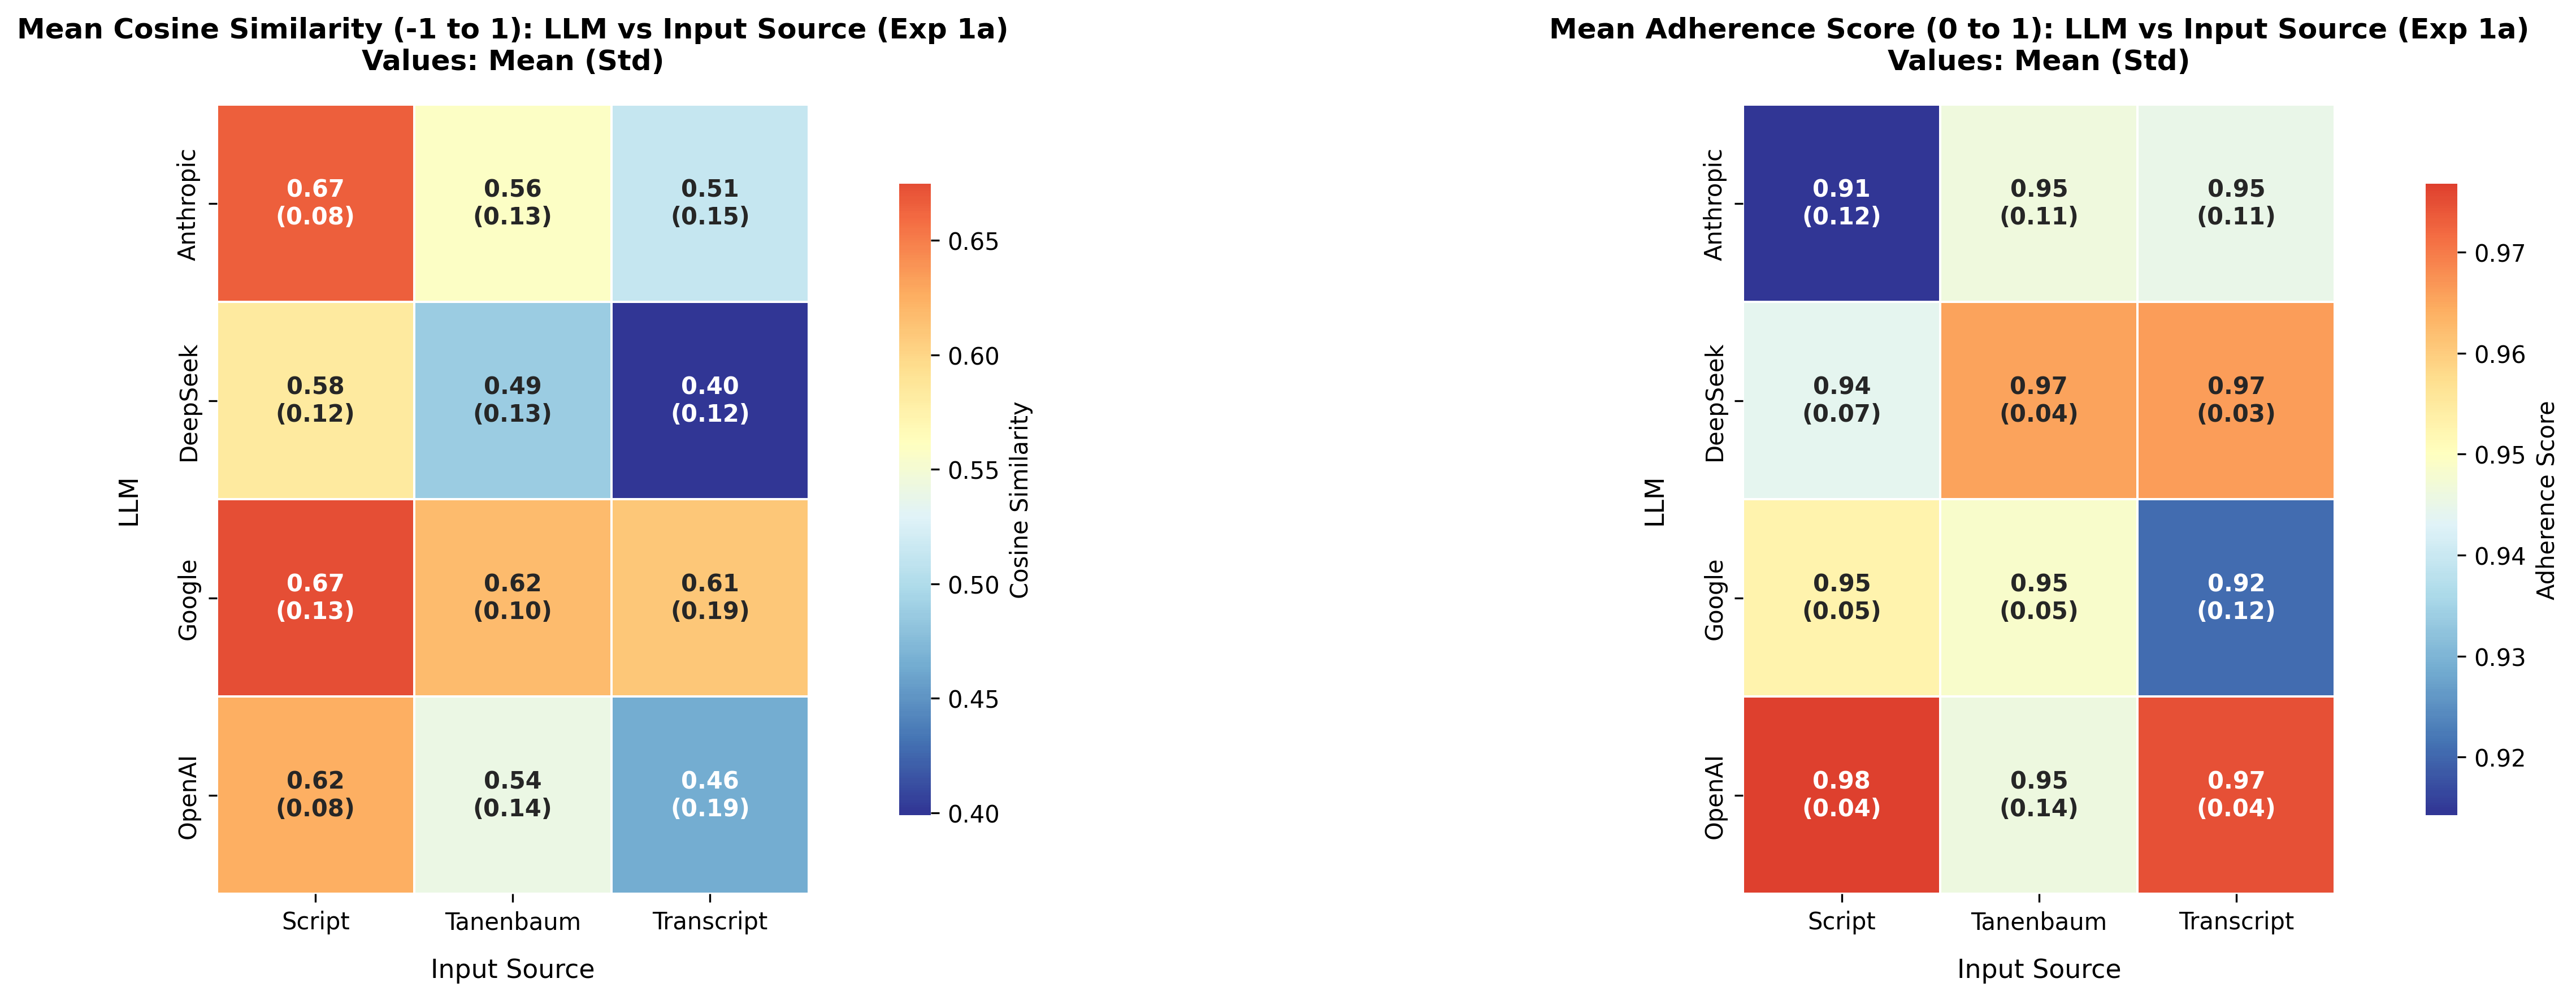

In [46]:
# TODO important die tendenz zum script
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
plots['exp1a_combined_llm_vs_input_source'] = fig

llm_vs_input_source_cos_sim_1a_display = llm_vs_input_source_cos_sim_1a["mean"].copy()
llm_vs_input_source_cos_sim_1a_std = llm_vs_input_source_cos_sim_1a["std"].copy()

# Create annotation matrix with mean and std
annot_matrix_cosine = llm_vs_input_source_cos_sim_1a_display.copy()
for i in range(len(llm_vs_input_source_cos_sim_1a_display.index)):
    for j in range(len(llm_vs_input_source_cos_sim_1a_display.columns)):
        mean_val = llm_vs_input_source_cos_sim_1a_display.iloc[i, j]
        std_val = llm_vs_input_source_cos_sim_1a_std.iloc[i, j]
        if pd.notna(mean_val) and pd.notna(std_val):
            annot_matrix_cosine.iloc[i, j] = f"{mean_val:.2f}\n({std_val:.2f})"
        elif pd.notna(mean_val):
            annot_matrix_cosine.iloc[i, j] = f"{mean_val:.2f}"

llm_vs_input_source_cos_sim_1a_display.index = llm_vs_input_source_cos_sim_1a_display.index.map({
    'anthropic': 'Anthropic', 'openai': 'OpenAI', 'google': 'Google', 'deepseek': 'DeepSeek'
})
llm_vs_input_source_cos_sim_1a_display.columns = llm_vs_input_source_cos_sim_1a_display.columns.map({
    'script': 'Script', 'transcript': 'Transcript', 'tanenbaum': 'Tanenbaum'
})
annot_matrix_cosine.index = annot_matrix_cosine.index.map({
    'anthropic': 'Anthropic', 'openai': 'OpenAI', 'google': 'Google', 'deepseek': 'DeepSeek'
})
annot_matrix_cosine.columns = annot_matrix_cosine.columns.map({
    'script': 'Script', 'transcript': 'Transcript', 'tanenbaum': 'Tanenbaum'
})

sns.heatmap(llm_vs_input_source_cos_sim_1a_display, 
            annot=annot_matrix_cosine, 
            fmt='', 
            cmap='RdYlBu_r',
            center=llm_vs_input_source_cos_sim_1a_display.mean().mean(),
            square=True,
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Cosine Similarity'},
            annot_kws={'size': 10, 'weight': 'bold'},
            ax=ax1)
ax1.set_title("Mean Cosine Similarity (-1 to 1): LLM vs Input Source (Exp 1a)\nValues: Mean (Std)", 
              fontsize=12, fontweight='bold', pad=15)
ax1.set_xlabel("Input Source", fontsize=11, labelpad=10)
ax1.set_ylabel("LLM", fontsize=11, labelpad=15)

llm_vs_input_source_adherence_1a = pd.pivot_table(
    exp1a_df,
    values="adherence_score",
    index="llm",
    columns="input_source",
    aggfunc=["mean", "std"],
)

llm_vs_input_source_adherence_1a_display = llm_vs_input_source_adherence_1a["mean"].copy()
llm_vs_input_source_adherence_1a_std = llm_vs_input_source_adherence_1a["std"].copy()

# Create annotation matrix with mean and std
annot_matrix_adherence = llm_vs_input_source_adherence_1a_display.copy()
for i in range(len(llm_vs_input_source_adherence_1a_display.index)):
    for j in range(len(llm_vs_input_source_adherence_1a_display.columns)):
        mean_val = llm_vs_input_source_adherence_1a_display.iloc[i, j]
        std_val = llm_vs_input_source_adherence_1a_std.iloc[i, j]
        if pd.notna(mean_val) and pd.notna(std_val):
            annot_matrix_adherence.iloc[i, j] = f"{mean_val:.2f}\n({std_val:.2f})"
        elif pd.notna(mean_val):
            annot_matrix_adherence.iloc[i, j] = f"{mean_val:.2f}"

llm_vs_input_source_adherence_1a_display.index = llm_vs_input_source_adherence_1a_display.index.map({
    'anthropic': 'Anthropic', 'openai': 'OpenAI', 'google': 'Google', 'deepseek': 'DeepSeek'
})
llm_vs_input_source_adherence_1a_display.columns = llm_vs_input_source_adherence_1a_display.columns.map({
    'script': 'Script', 'transcript': 'Transcript', 'tanenbaum': 'Tanenbaum'
})
annot_matrix_adherence.index = annot_matrix_adherence.index.map({
    'anthropic': 'Anthropic', 'openai': 'OpenAI', 'google': 'Google', 'deepseek': 'DeepSeek'
})
annot_matrix_adherence.columns = annot_matrix_adherence.columns.map({
    'script': 'Script', 'transcript': 'Transcript', 'tanenbaum': 'Tanenbaum'
})

sns.heatmap(llm_vs_input_source_adherence_1a_display, 
            annot=annot_matrix_adherence, 
            fmt='', 
            cmap='RdYlBu_r',
            center=llm_vs_input_source_adherence_1a_display.mean().mean(),
            square=True,
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Adherence Score'},
            annot_kws={'size': 10, 'weight': 'bold'},
            ax=ax2)
ax2.set_title("Mean Adherence Score (0 to 1): LLM vs Input Source (Exp 1a)\nValues: Mean (Std)", 
              fontsize=12, fontweight='bold', pad=15)
ax2.set_xlabel("Input Source", fontsize=11, labelpad=10)
ax2.set_ylabel("LLM", fontsize=11, labelpad=15)

plt.tight_layout()
plt.show()


### 1.6: Cosine Similarity: LLM vs Prompt Type

In [47]:
llm_vs_prompt_type_cos_sim_1a = pd.pivot_table(
    exp1a_df,
    values="cosine_similarity",
    index="llm",
    columns="prompt_type",
    aggfunc=["mean", "std"],
)
tables["exp1a_cosine_sim_llm_vs_prompt_type"] = llm_vs_prompt_type_cos_sim_1a
display(llm_vs_prompt_type_cos_sim_1a)

mean                 std          
prompt_type    common   complex    common   complex
llm                                                
anthropic    0.583207  0.574440  0.166589  0.101888
deepseek     0.485833  0.494285  0.141371  0.146142
google       0.580096  0.688457  0.158760  0.102245
openai       0.508703  0.577575  0.184646  0.111829

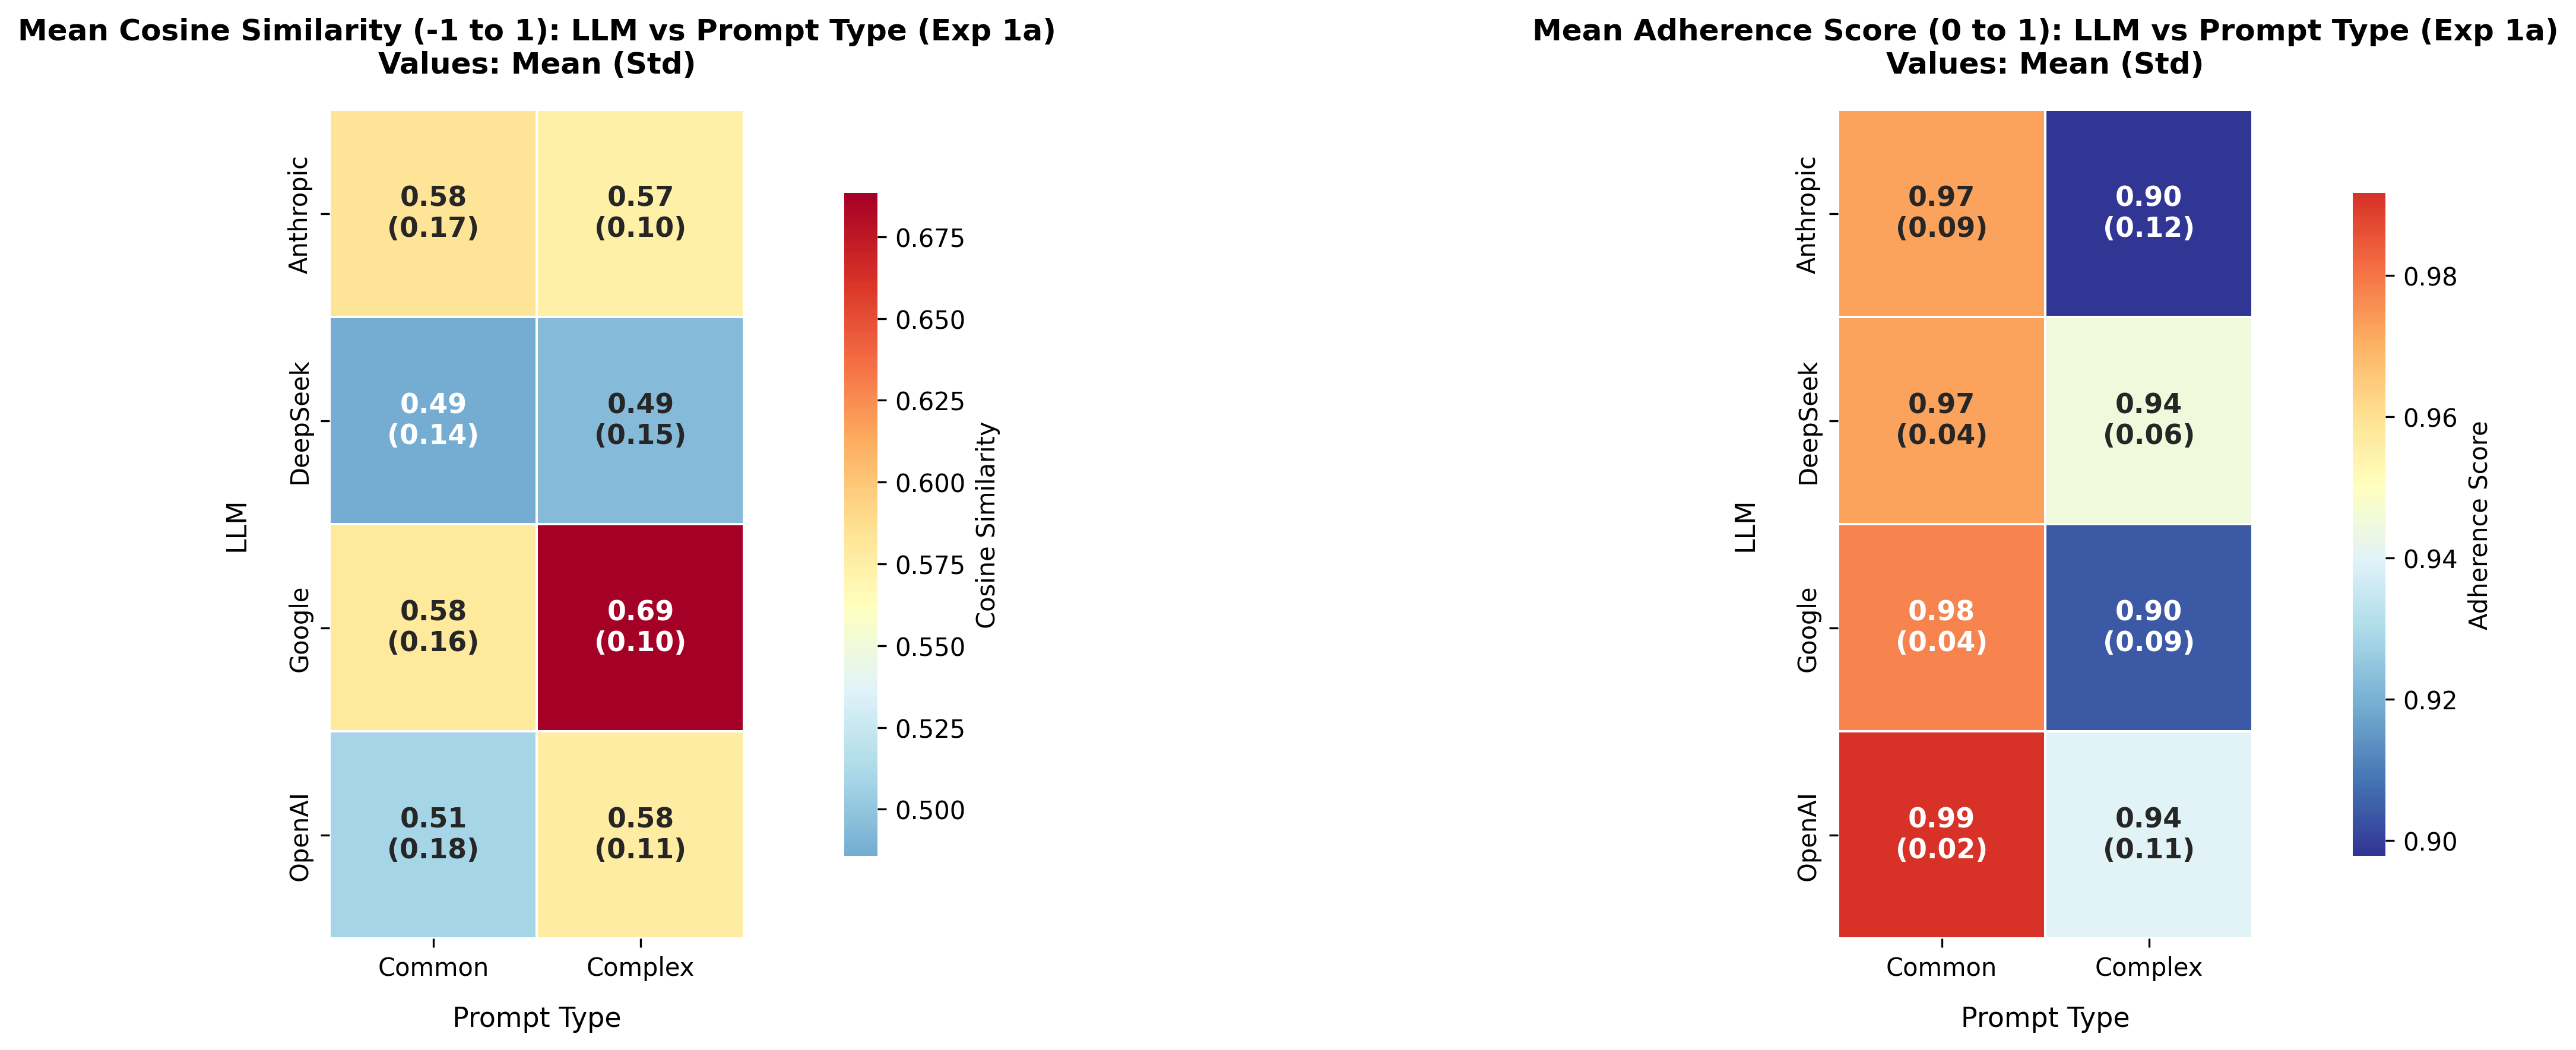

In [48]:
# Combined heatmaps: LLM vs Prompt Type (Exp 1a)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
plots['exp1a_combined_llm_vs_prompt_type'] = fig

llm_vs_prompt_type_cos_sim_1a_display = llm_vs_prompt_type_cos_sim_1a["mean"].copy()
llm_vs_prompt_type_cos_sim_1a_std = llm_vs_prompt_type_cos_sim_1a["std"].copy()

# Create annotation matrix with mean and std
annot_matrix_cosine_prompt = llm_vs_prompt_type_cos_sim_1a_display.copy()
for i in range(len(llm_vs_prompt_type_cos_sim_1a_display.index)):
    for j in range(len(llm_vs_prompt_type_cos_sim_1a_display.columns)):
        mean_val = llm_vs_prompt_type_cos_sim_1a_display.iloc[i, j]
        std_val = llm_vs_prompt_type_cos_sim_1a_std.iloc[i, j]
        if pd.notna(mean_val) and pd.notna(std_val):
            annot_matrix_cosine_prompt.iloc[i, j] = f"{mean_val:.2f}\n({std_val:.2f})"
        elif pd.notna(mean_val):
            annot_matrix_cosine_prompt.iloc[i, j] = f"{mean_val:.2f}"

llm_vs_prompt_type_cos_sim_1a_display.index = llm_vs_prompt_type_cos_sim_1a_display.index.map({
    'anthropic': 'Anthropic', 'openai': 'OpenAI', 'google': 'Google', 'deepseek': 'DeepSeek'
})
llm_vs_prompt_type_cos_sim_1a_display.columns = llm_vs_prompt_type_cos_sim_1a_display.columns.map({
    'common': 'Common', 'complex': 'Complex'
})
annot_matrix_cosine_prompt.index = annot_matrix_cosine_prompt.index.map({
    'anthropic': 'Anthropic', 'openai': 'OpenAI', 'google': 'Google', 'deepseek': 'DeepSeek'
})
annot_matrix_cosine_prompt.columns = annot_matrix_cosine_prompt.columns.map({
    'common': 'Common', 'complex': 'Complex'
})

sns.heatmap(llm_vs_prompt_type_cos_sim_1a_display, 
            annot=annot_matrix_cosine_prompt, 
            fmt='', 
            cmap='RdYlBu_r',
            center=llm_vs_prompt_type_cos_sim_1a_display.mean().mean(),
            square=True,
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Cosine Similarity'},
            annot_kws={'size': 11, 'weight': 'bold'},
            ax=ax1)
ax1.set_title("Mean Cosine Similarity (-1 to 1): LLM vs Prompt Type (Exp 1a)\nValues: Mean (Std)", 
              fontsize=12, fontweight='bold', pad=15)
ax1.set_xlabel("Prompt Type", fontsize=11, labelpad=10)
ax1.set_ylabel("LLM", fontsize=11, labelpad=15)

llm_vs_prompt_type_adherence_1a = pd.pivot_table(
    exp1a_df,
    values="adherence_score",
    index="llm",
    columns="prompt_type",
    aggfunc=["mean", "std"],
)

llm_vs_prompt_type_adherence_1a_display = llm_vs_prompt_type_adherence_1a["mean"].copy()
llm_vs_prompt_type_adherence_1a_std = llm_vs_prompt_type_adherence_1a["std"].copy()

# Create annotation matrix with mean and std
annot_matrix_adherence_prompt = llm_vs_prompt_type_adherence_1a_display.copy()
for i in range(len(llm_vs_prompt_type_adherence_1a_display.index)):
    for j in range(len(llm_vs_prompt_type_adherence_1a_display.columns)):
        mean_val = llm_vs_prompt_type_adherence_1a_display.iloc[i, j]
        std_val = llm_vs_prompt_type_adherence_1a_std.iloc[i, j]
        if pd.notna(mean_val) and pd.notna(std_val):
            annot_matrix_adherence_prompt.iloc[i, j] = f"{mean_val:.2f}\n({std_val:.2f})"
        elif pd.notna(mean_val):
            annot_matrix_adherence_prompt.iloc[i, j] = f"{mean_val:.2f}"

llm_vs_prompt_type_adherence_1a_display.index = llm_vs_prompt_type_adherence_1a_display.index.map({
    'anthropic': 'Anthropic', 'openai': 'OpenAI', 'google': 'Google', 'deepseek': 'DeepSeek'
})
llm_vs_prompt_type_adherence_1a_display.columns = llm_vs_prompt_type_adherence_1a_display.columns.map({
    'common': 'Common', 'complex': 'Complex'
})
annot_matrix_adherence_prompt.index = annot_matrix_adherence_prompt.index.map({
    'anthropic': 'Anthropic', 'openai': 'OpenAI', 'google': 'Google', 'deepseek': 'DeepSeek'
})
annot_matrix_adherence_prompt.columns = annot_matrix_adherence_prompt.columns.map({
    'common': 'Common', 'complex': 'Complex'
})

sns.heatmap(llm_vs_prompt_type_adherence_1a_display, 
            annot=annot_matrix_adherence_prompt, 
            fmt='', 
            cmap='RdYlBu_r',
            center=llm_vs_prompt_type_adherence_1a_display.mean().mean(),
            square=True,
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Adherence Score'},
            annot_kws={'size': 11, 'weight': 'bold'},
            ax=ax2)
ax2.set_title("Mean Adherence Score (0 to 1): LLM vs Prompt Type (Exp 1a)\nValues: Mean (Std)", 
              fontsize=12, fontweight='bold', pad=15)
ax2.set_xlabel("Prompt Type", fontsize=11, labelpad=10)
ax2.set_ylabel("LLM", fontsize=11, labelpad=15)

plt.tight_layout()
plt.show()


### 1.7: Adherence Score: LLM vs Prompt Type

In [49]:
llm_vs_prompt_type_adherence_1a = pd.pivot_table(
    exp1a_df,
    values="adherence_score",
    index="llm",
    columns="prompt_type",
    aggfunc=["mean", "std"],
)
tables["exp1a_adherence_llm_vs_prompt_type"] = llm_vs_prompt_type_adherence_1a
display(llm_vs_prompt_type_adherence_1a)

mean                 std          
prompt_type    common   complex    common   complex
llm                                                
anthropic    0.972619  0.897857  0.093843  0.116249
deepseek     0.972619  0.944762  0.036797  0.057781
google       0.977381  0.904048  0.043778  0.090286
openai       0.991667  0.940000  0.015995  0.112761

### 1.8: Adherence Score: LLM vs Input Source

In [50]:
llm_vs_input_source_adherence_1a = pd.pivot_table(
    exp1a_df,
    values="adherence_score",
    index="llm",
    columns="input_source",
    aggfunc=["mean", "std"],
)
tables["exp1a_adherence_llm_vs_input_source"] = llm_vs_input_source_adherence_1a
display(llm_vs_input_source_adherence_1a)

mean                            std                     
input_source    script tanenbaum transcript    script tanenbaum transcript
llm                                                                       
anthropic     0.914286  0.946429   0.945000  0.115806  0.111017   0.111390
deepseek      0.944286  0.965714   0.966071  0.066762  0.043847   0.033637
google        0.952857  0.948571   0.920714  0.051168  0.054647   0.116501
openai        0.976786  0.946071   0.974643  0.037293  0.137284   0.035217

### 1.9: Distribution Plots

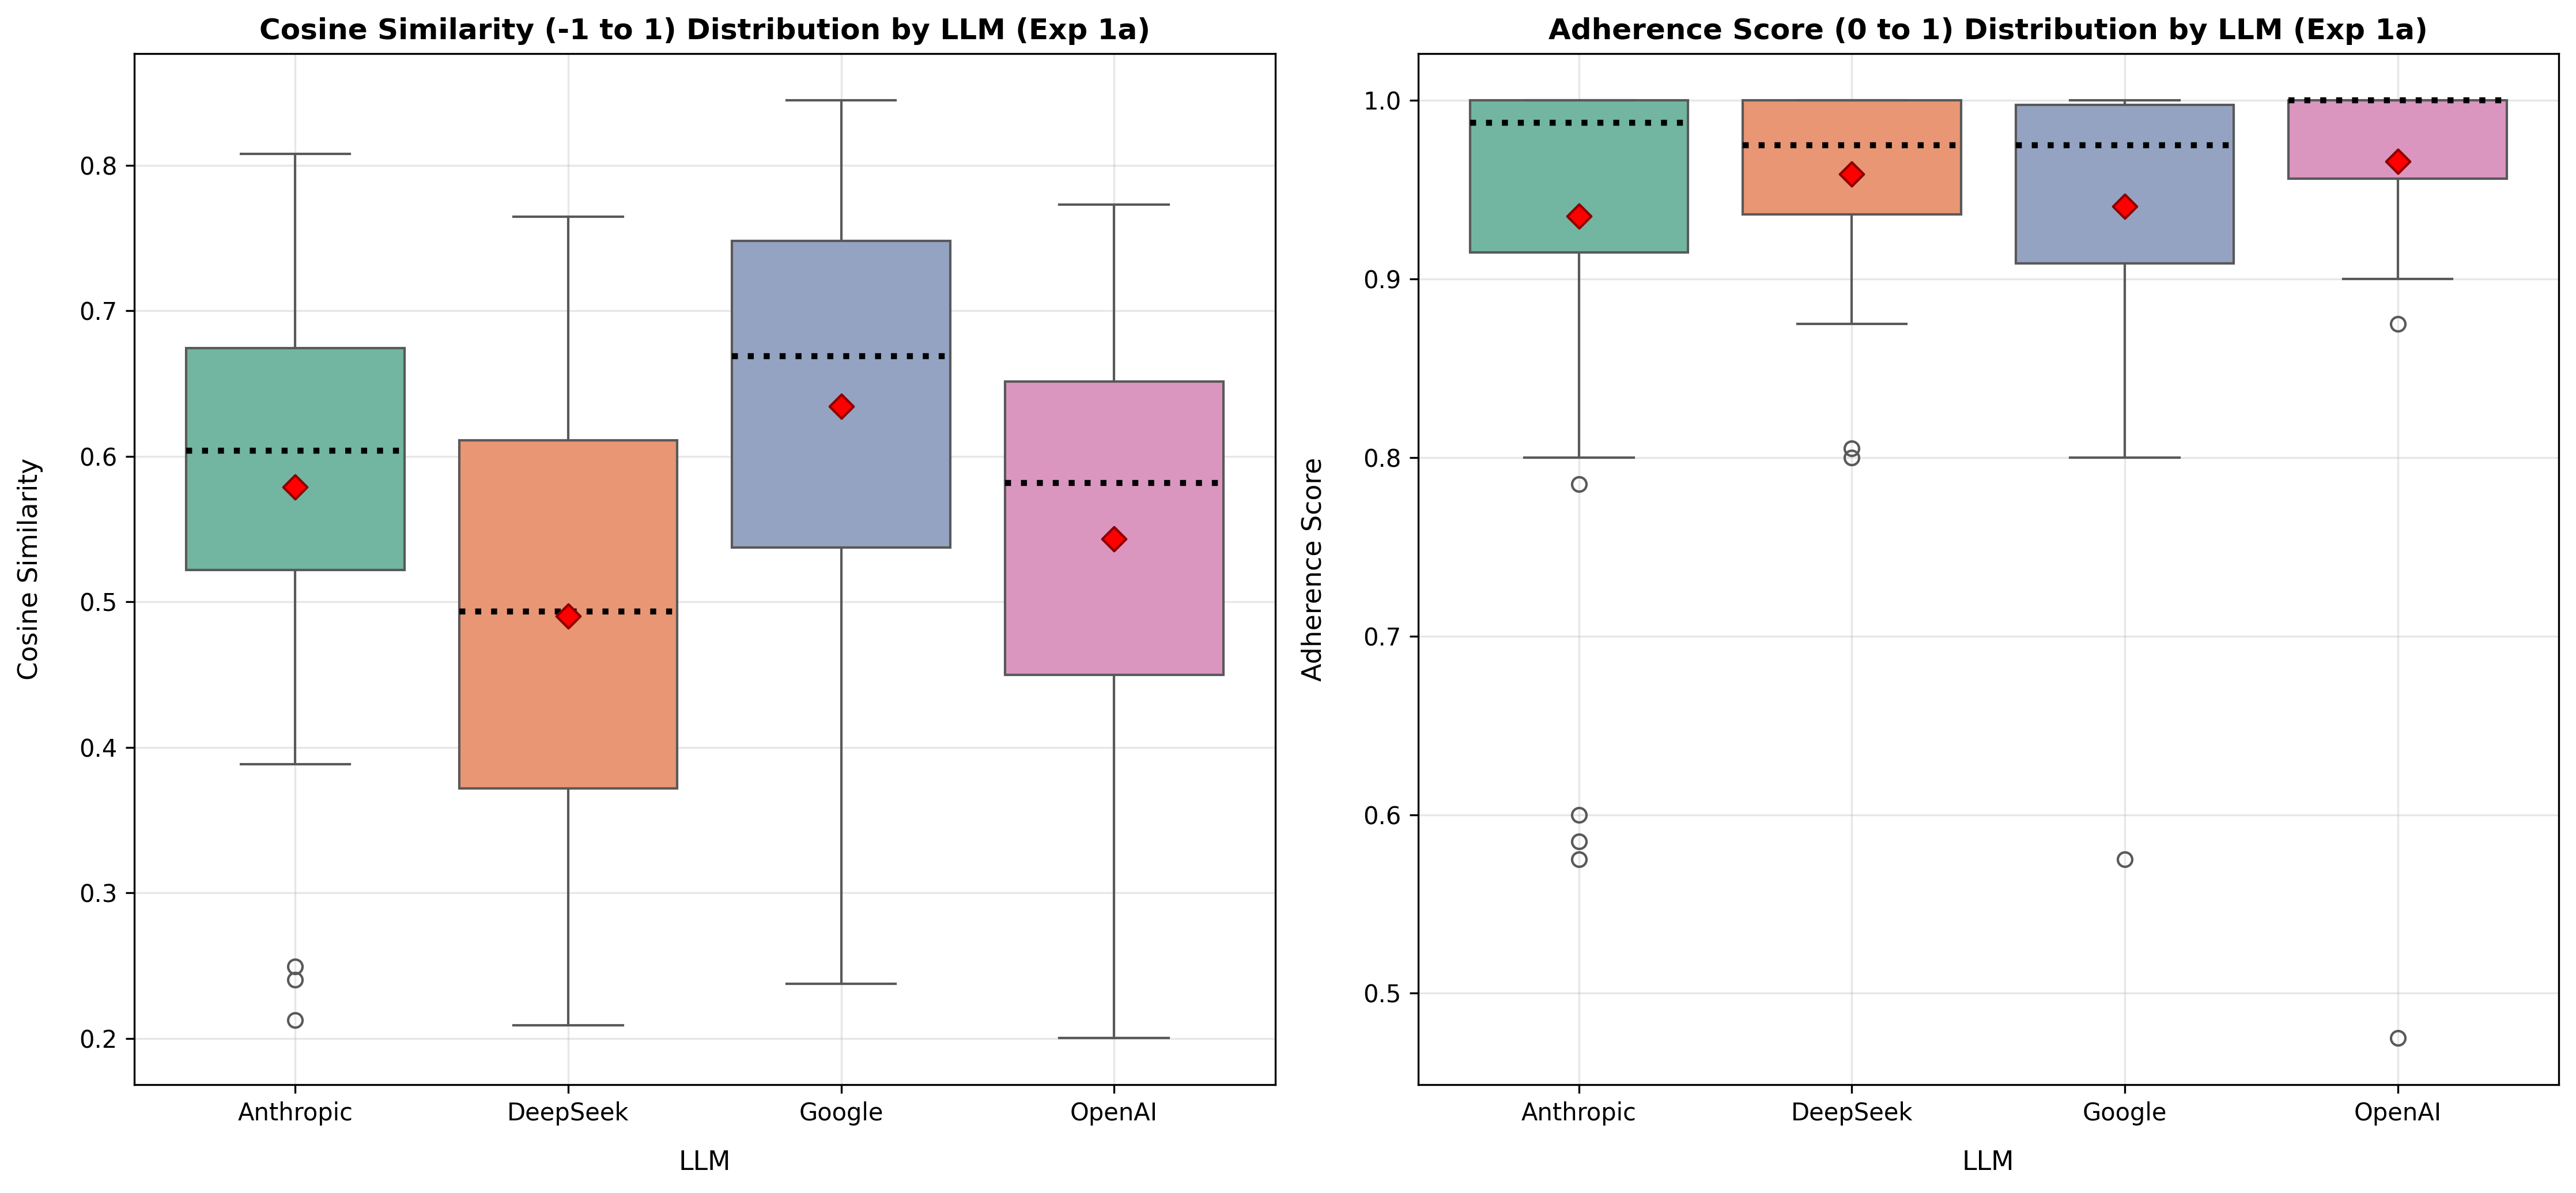

In [51]:
# Boxplot for cosine_similarity and adherence_score by LLM
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
plots['exp1a_dist_by_llm'] = fig

create_seaborn_boxplot(exp1a_df, 'llm', 'cosine_similarity', ax[0], 
                      'Cosine Similarity (-1 to 1) Distribution by LLM (Exp 1a)',
                      'Cosine Similarity', 'LLM')

create_seaborn_boxplot(exp1a_df, 'llm', 'adherence_score', ax[1],
                      'Adherence Score (0 to 1) Distribution by LLM (Exp 1a)', 
                      'Adherence Score', 'LLM')

plt.tight_layout()
plt.show()


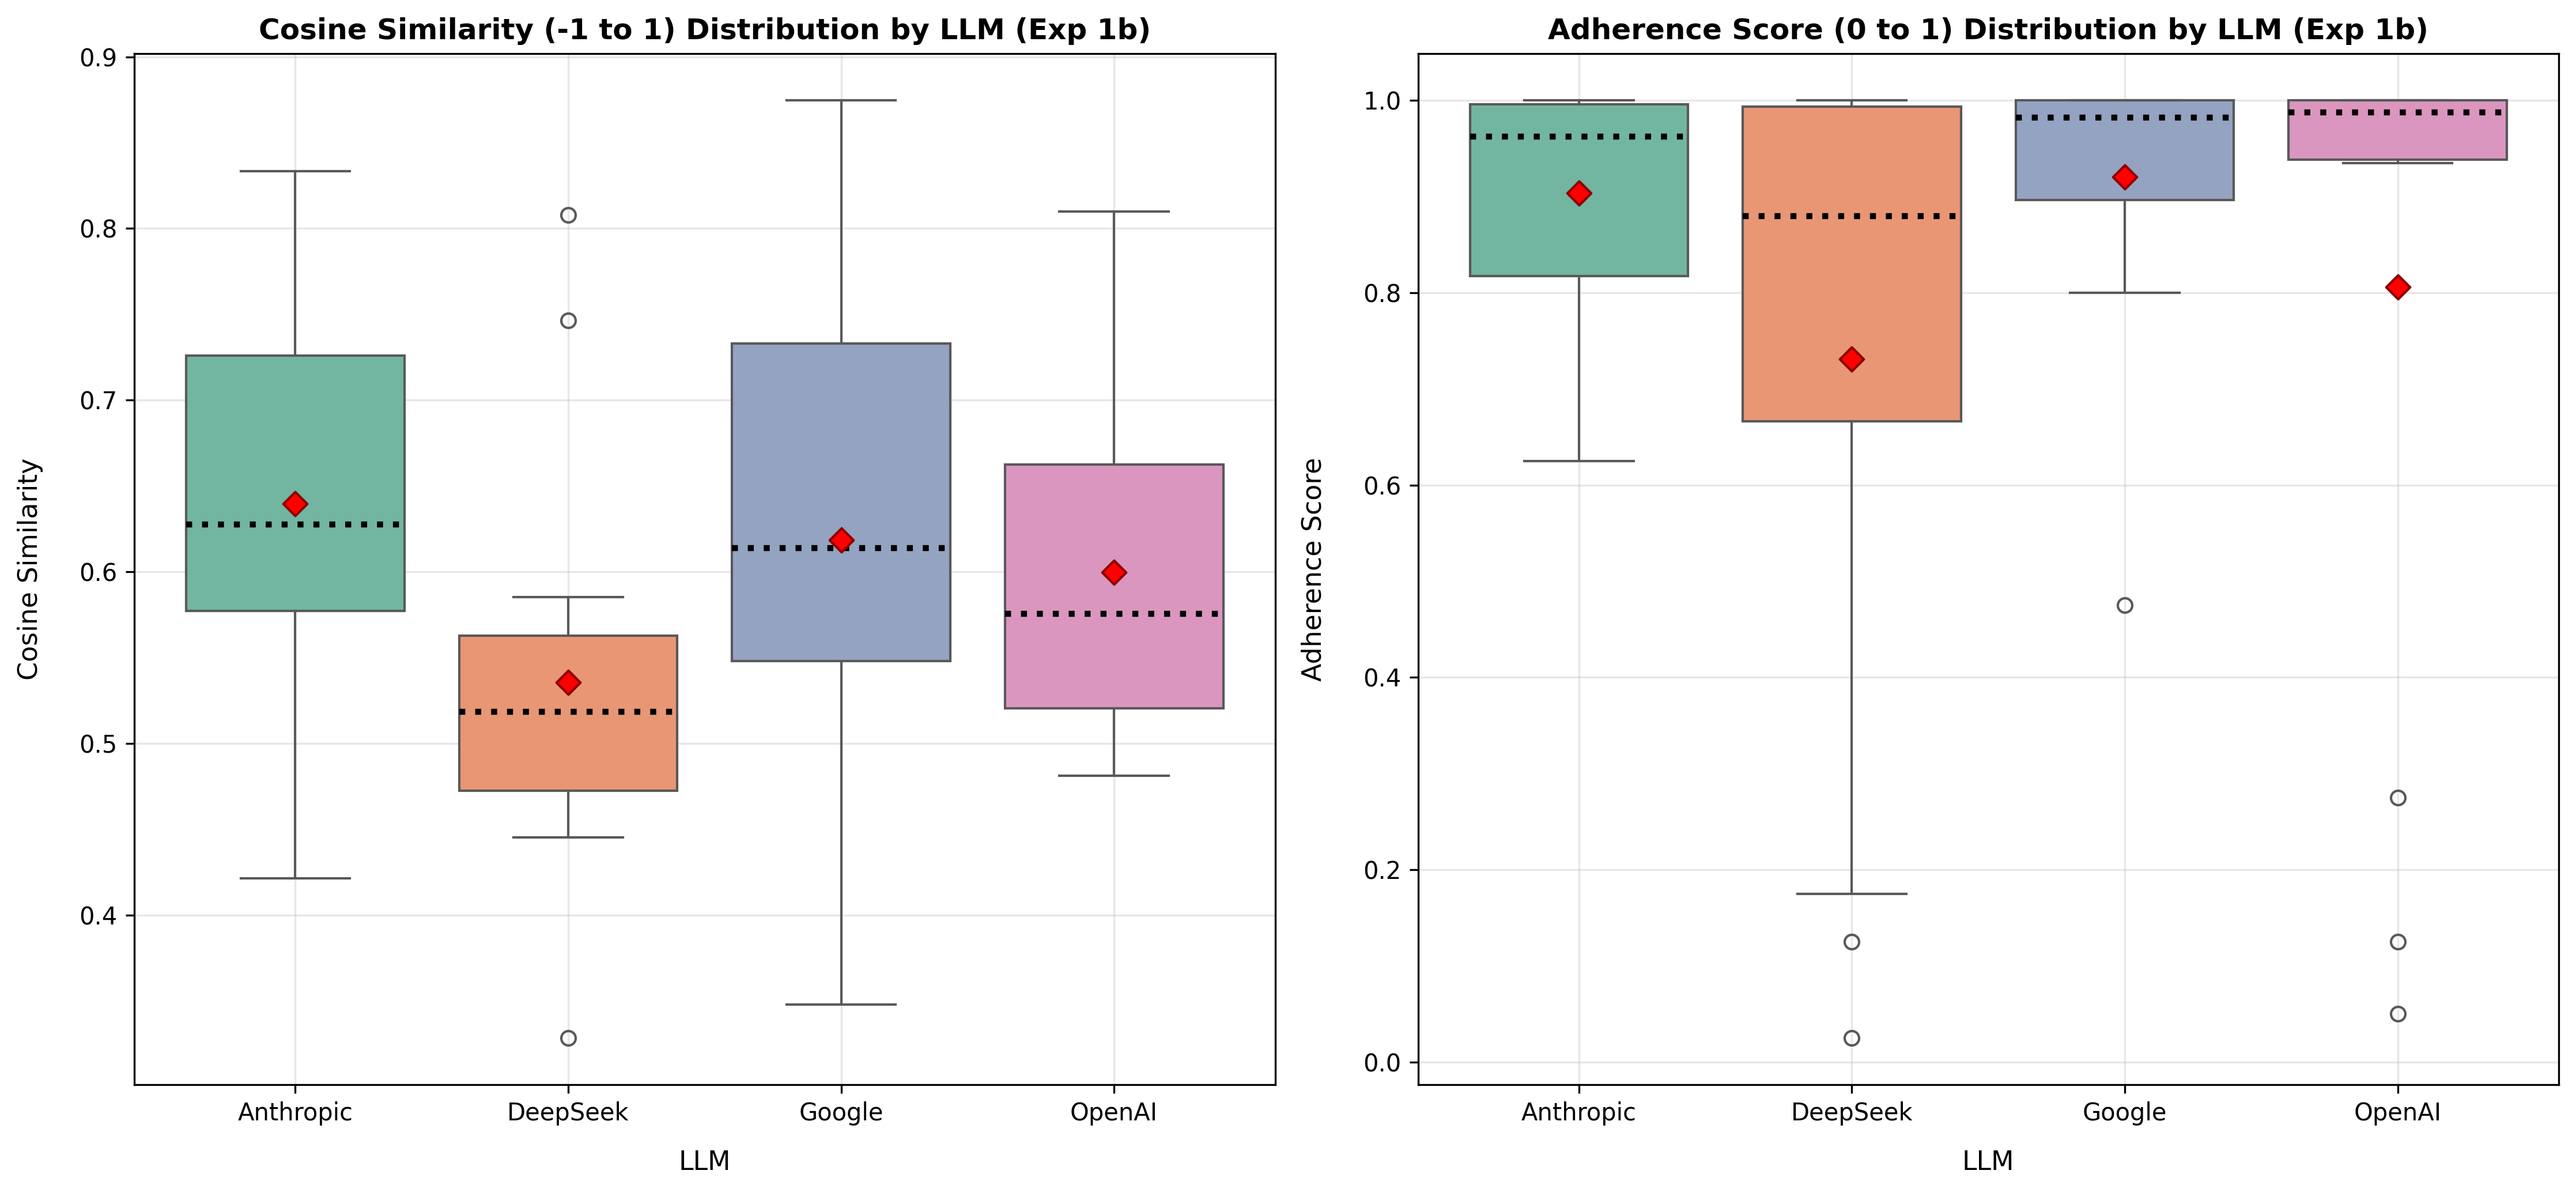

In [52]:
# Boxplot for cosine_similarity and adherence_score by LLM
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
plots['exp1b_dist_by_llm'] = fig

create_seaborn_boxplot(exp1b_df, 'llm', 'cosine_similarity', ax[0], 
                      'Cosine Similarity (-1 to 1) Distribution by LLM (Exp 1b)',
                      'Cosine Similarity', 'LLM')

create_seaborn_boxplot(exp1b_df, 'llm', 'adherence_score', ax[1],
                      'Adherence Score (0 to 1) Distribution by LLM (Exp 1b)', 
                      'Adherence Score', 'LLM')

plt.tight_layout()
plt.show()


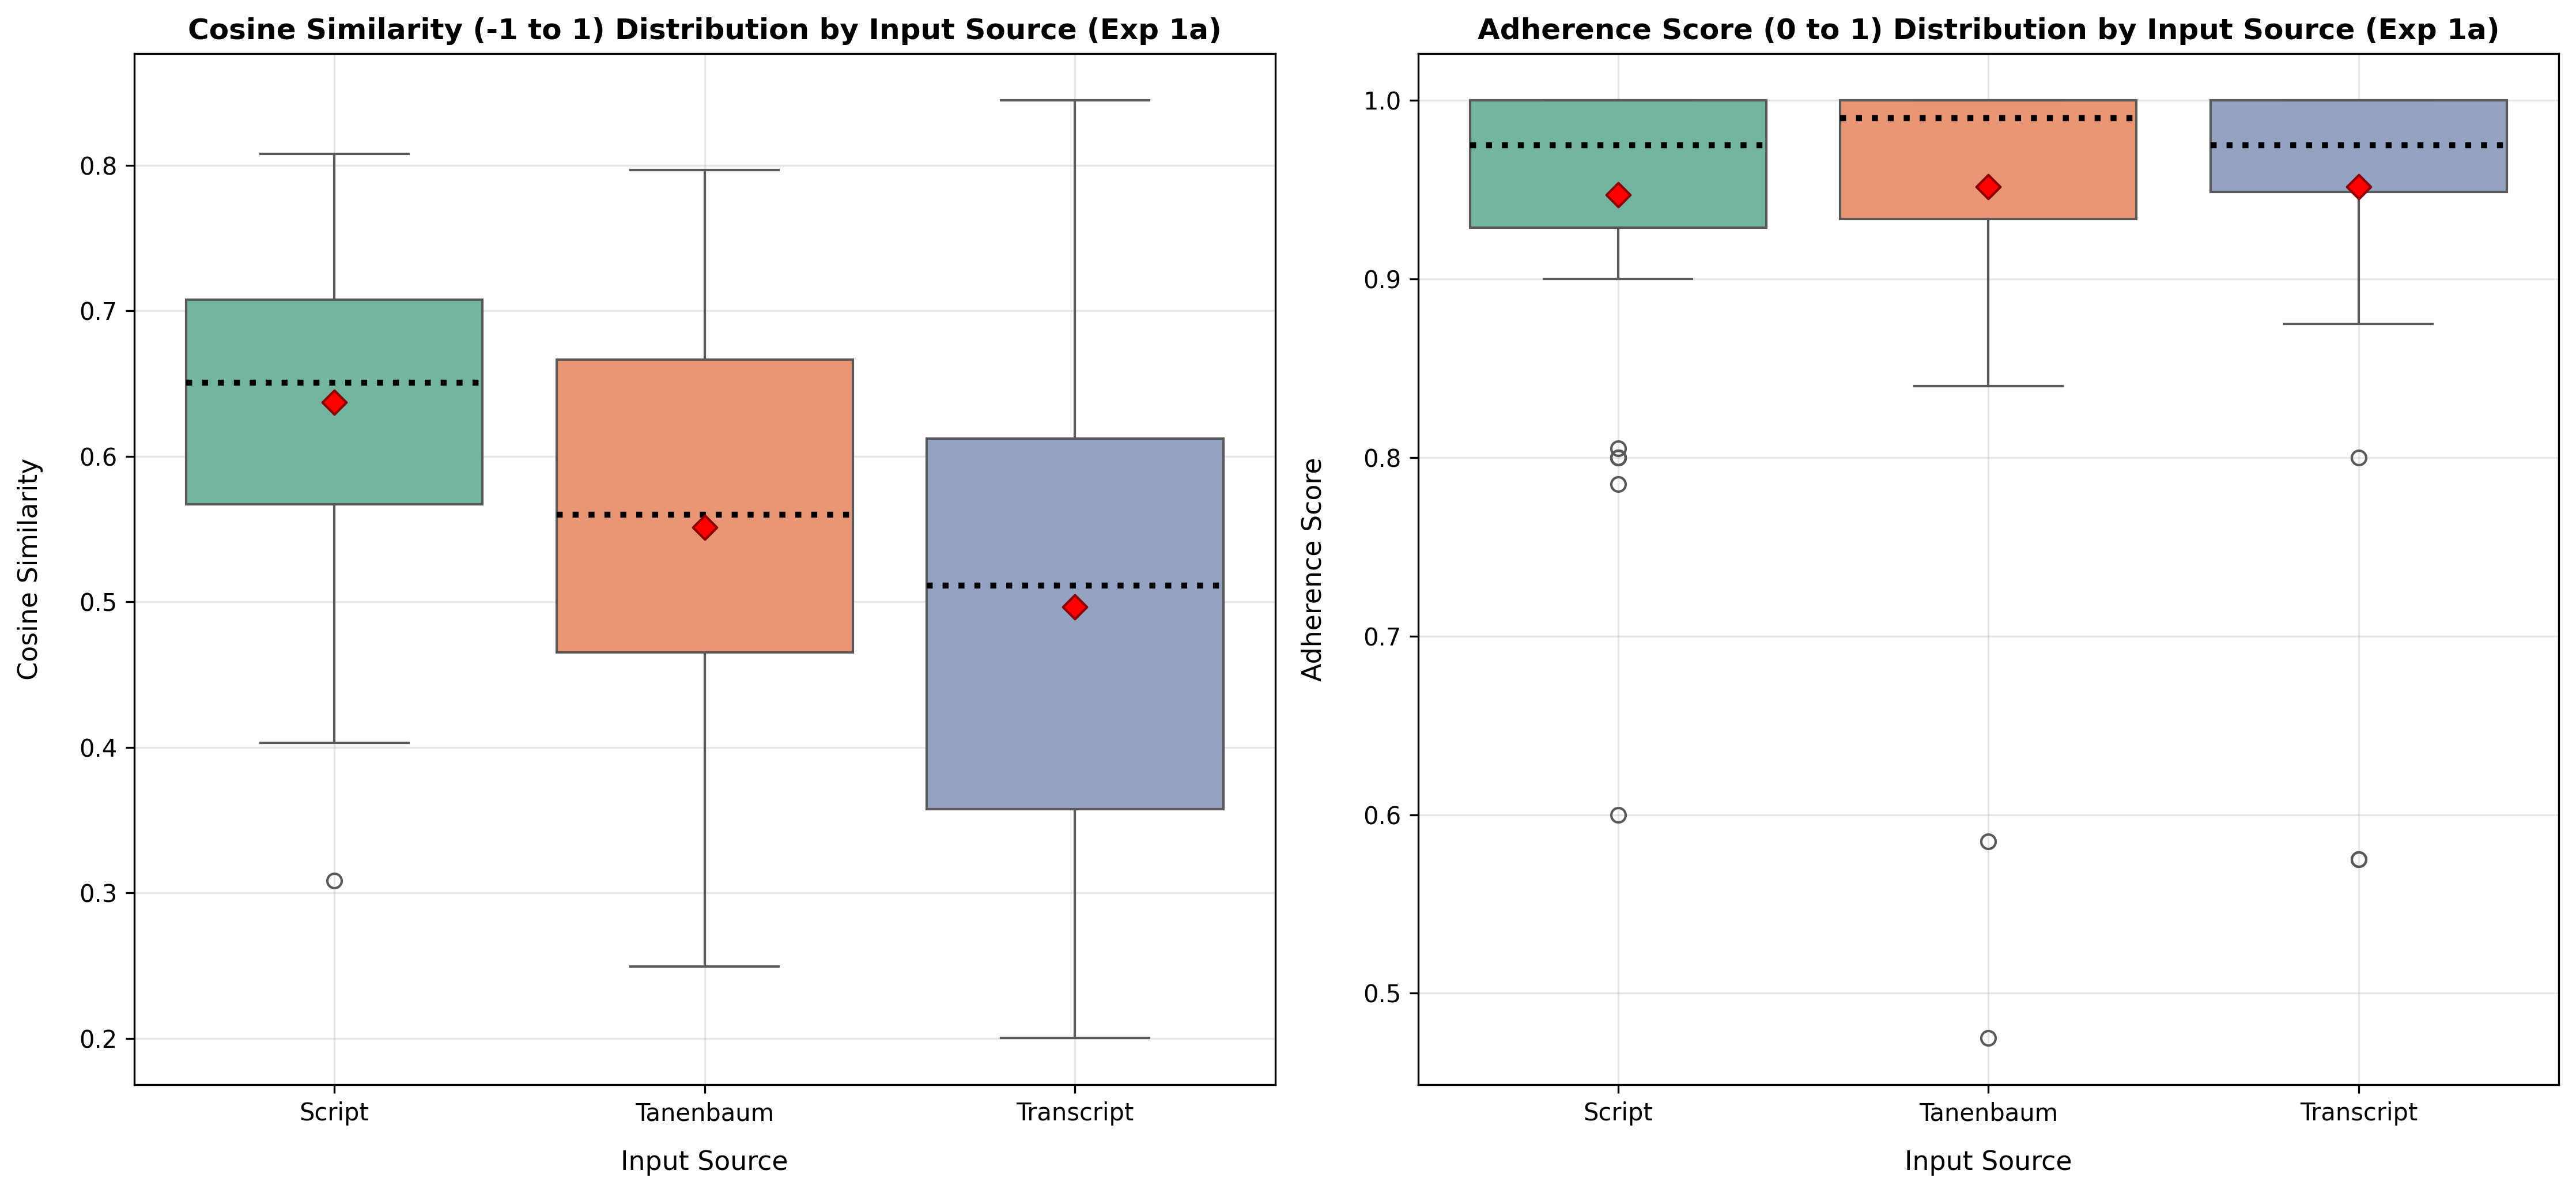

In [53]:
# Boxplot for cosine_similarity and adherence_score by input_source
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
plots['exp1a_dist_by_input_source'] = fig

create_seaborn_boxplot(exp1a_df, 'input_source', 'cosine_similarity', ax[0], 
                      'Cosine Similarity (-1 to 1) Distribution by Input Source (Exp 1a)',
                      'Cosine Similarity', 'Input Source')

create_seaborn_boxplot(exp1a_df, 'input_source', 'adherence_score', ax[1],
                      'Adherence Score (0 to 1) Distribution by Input Source (Exp 1a)', 
                      'Adherence Score', 'Input Source')

plt.tight_layout()
plt.show()

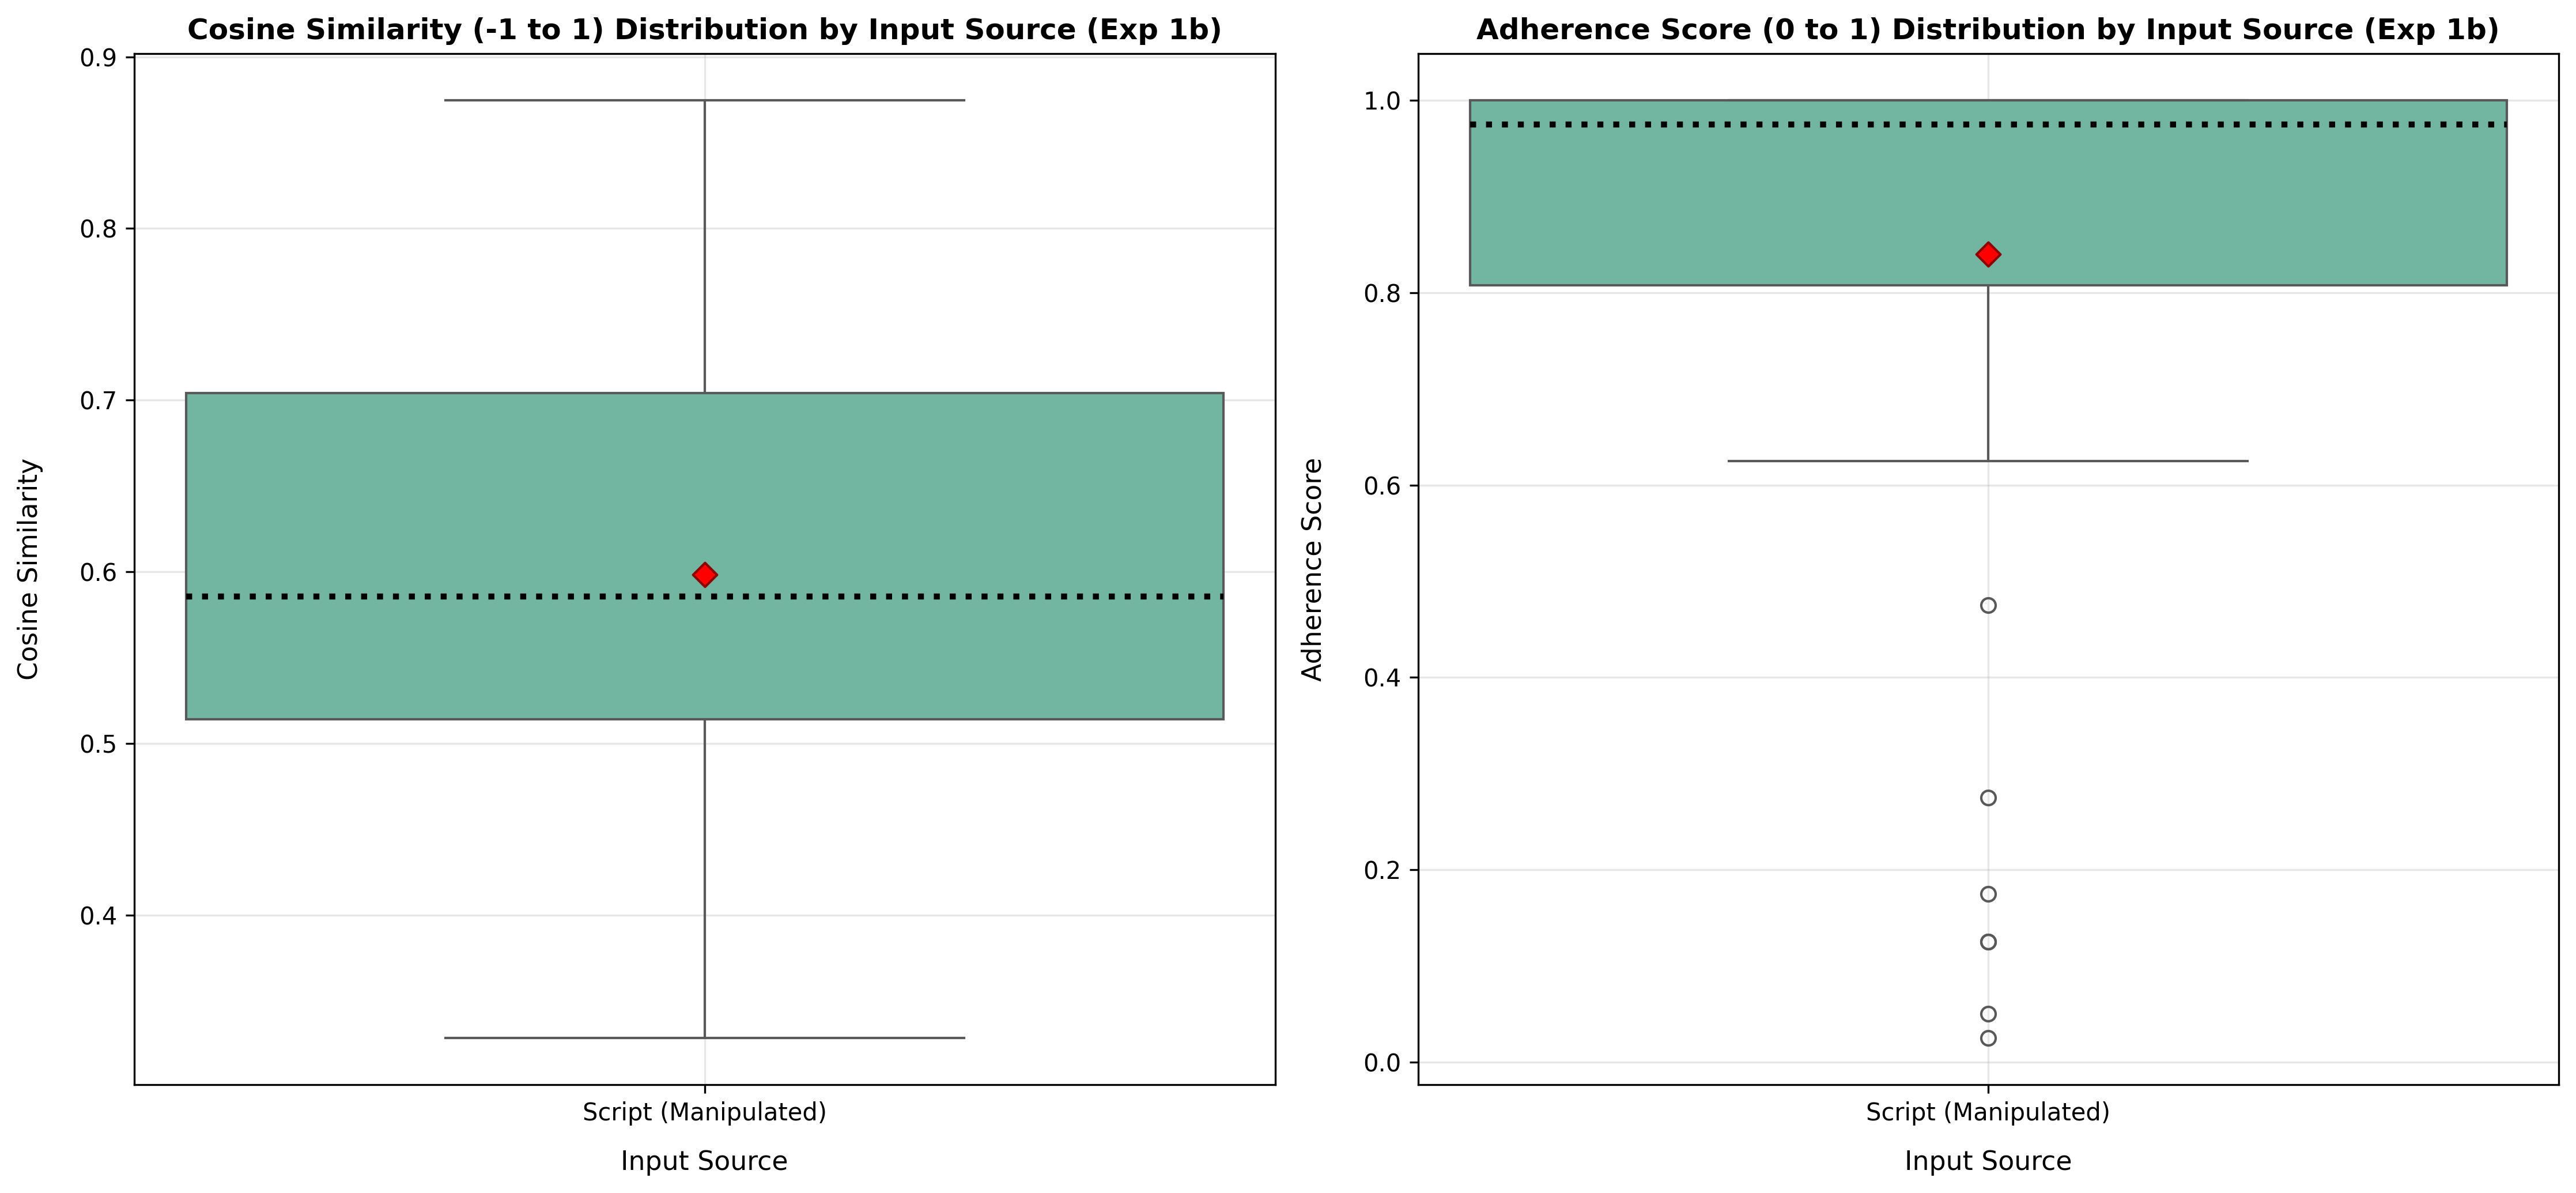

In [54]:
# Boxplot for cosine_similarity and adherence_score by input_source
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
plots['exp1b_dist_by_input_source'] = fig

create_seaborn_boxplot(exp1b_df, 'input_source', 'cosine_similarity', ax[0], 
                      'Cosine Similarity (-1 to 1) Distribution by Input Source (Exp 1b)',
                      'Cosine Similarity', 'Input Source')

create_seaborn_boxplot(exp1b_df, 'input_source', 'adherence_score', ax[1],
                      'Adherence Score (0 to 1) Distribution by Input Source (Exp 1b)', 
                      'Adherence Score', 'Input Source')

plt.tight_layout()
plt.show()

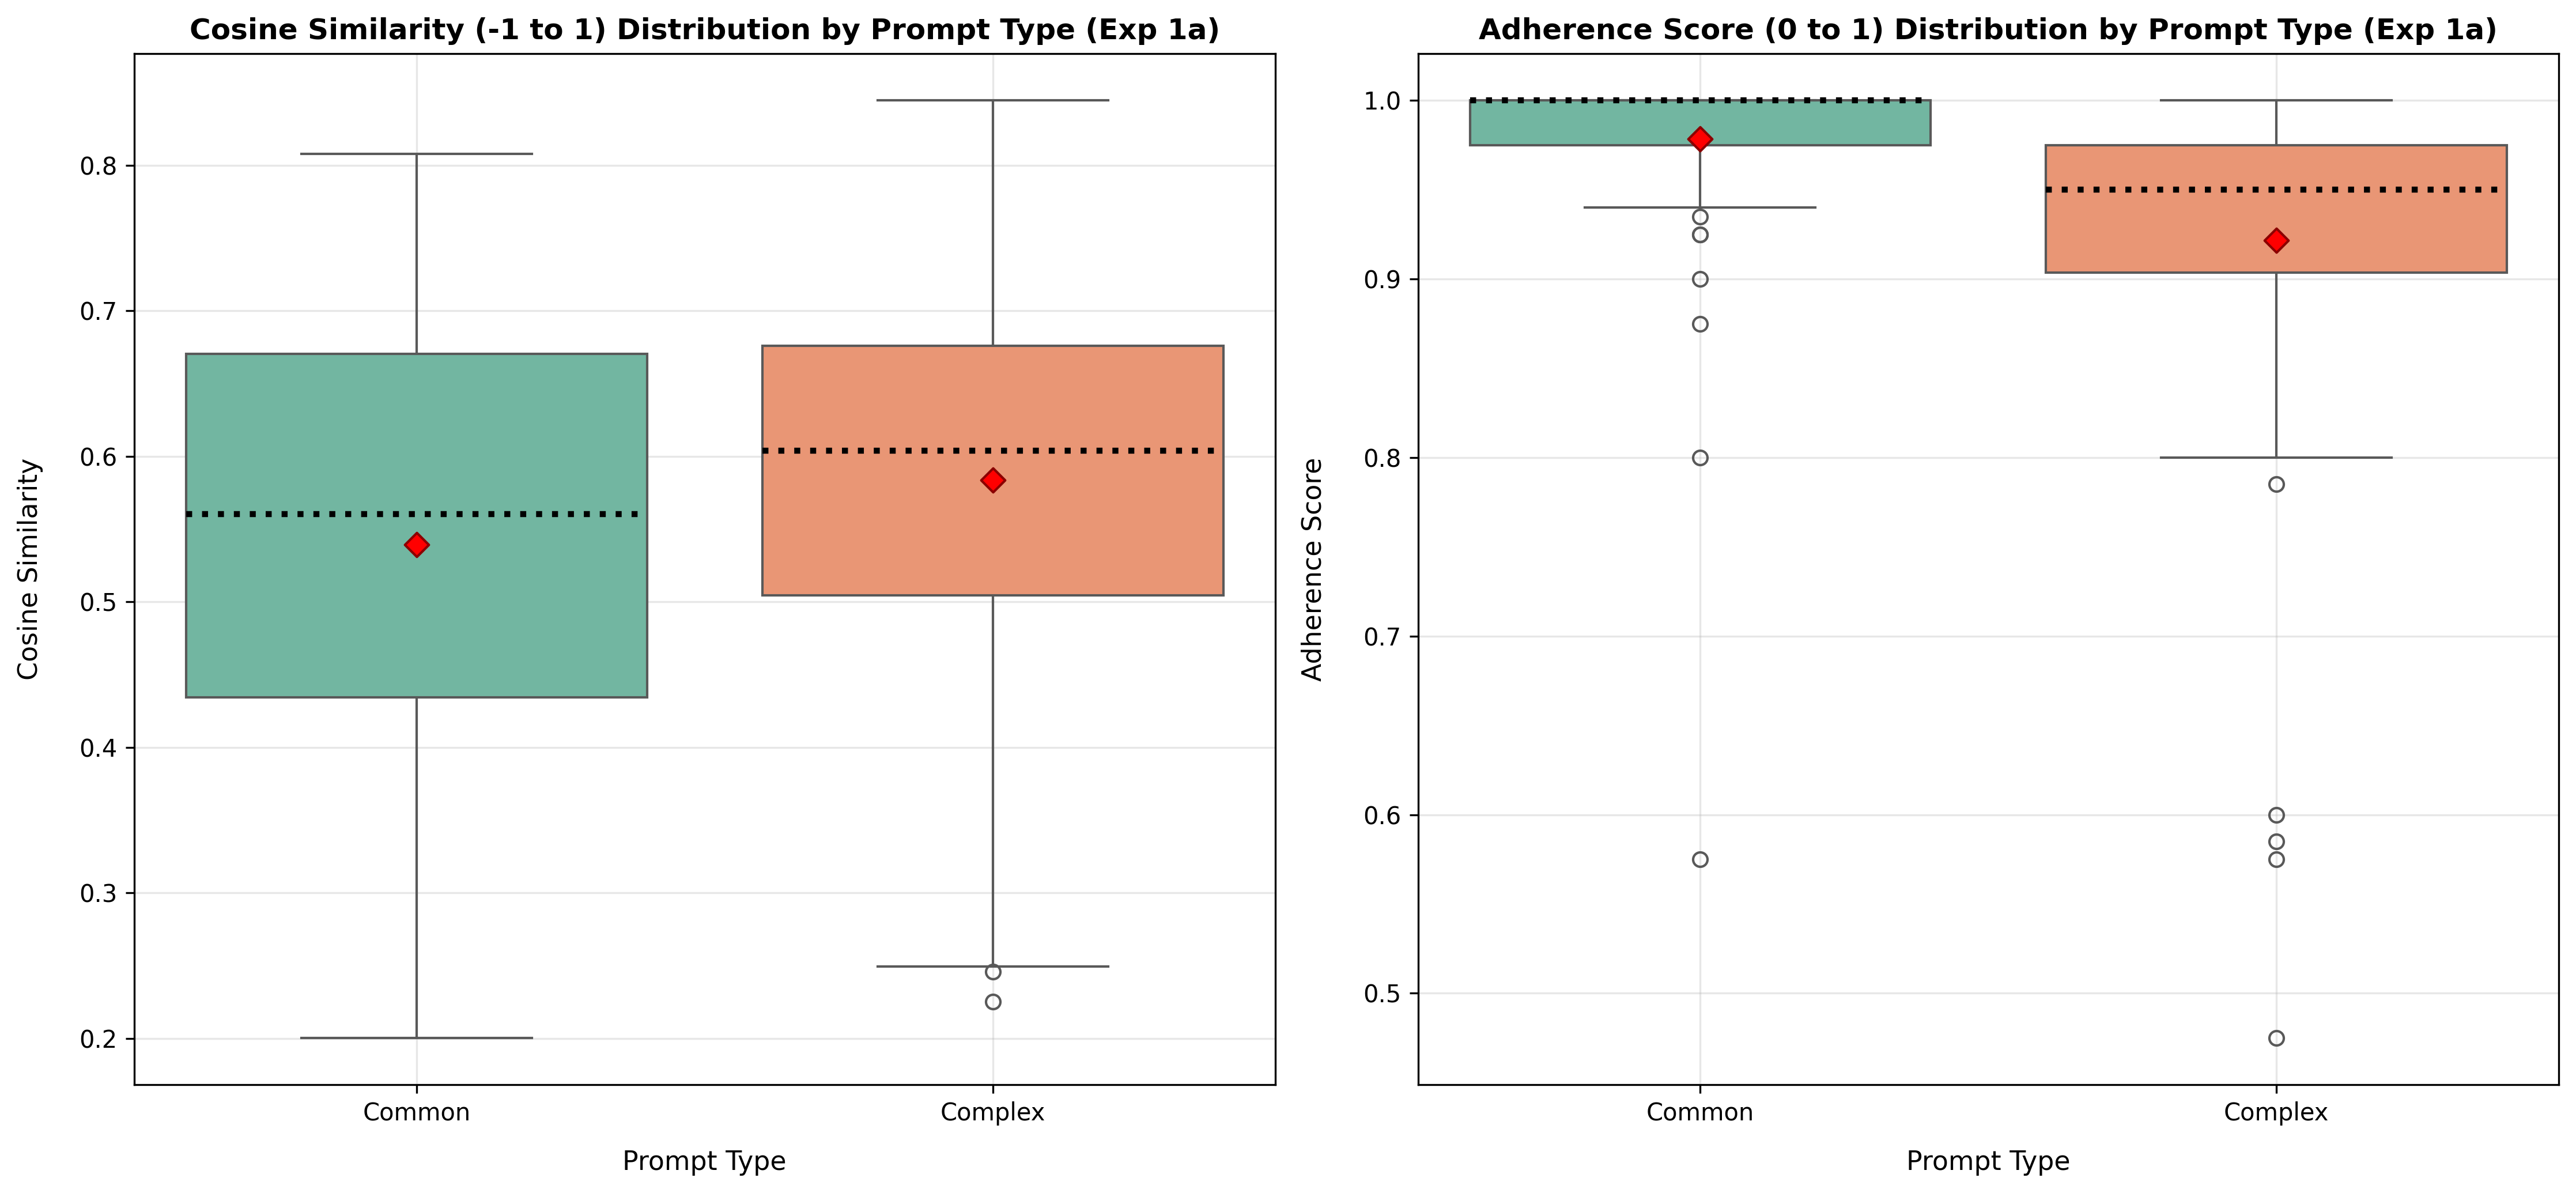

In [55]:
# Boxplot for cosine_similarity and adherence_score by prompt_type
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
plots['exp1a_dist_by_prompt_type'] = fig

create_seaborn_boxplot(exp1a_df, 'prompt_type', 'cosine_similarity', ax[0], 
                      'Cosine Similarity (-1 to 1) Distribution by Prompt Type (Exp 1a)',
                      'Cosine Similarity', 'Prompt Type')

create_seaborn_boxplot(exp1a_df, 'prompt_type', 'adherence_score', ax[1],
                      'Adherence Score (0 to 1) Distribution by Prompt Type (Exp 1a)', 
                      'Adherence Score', 'Prompt Type')

plt.tight_layout()
plt.show()

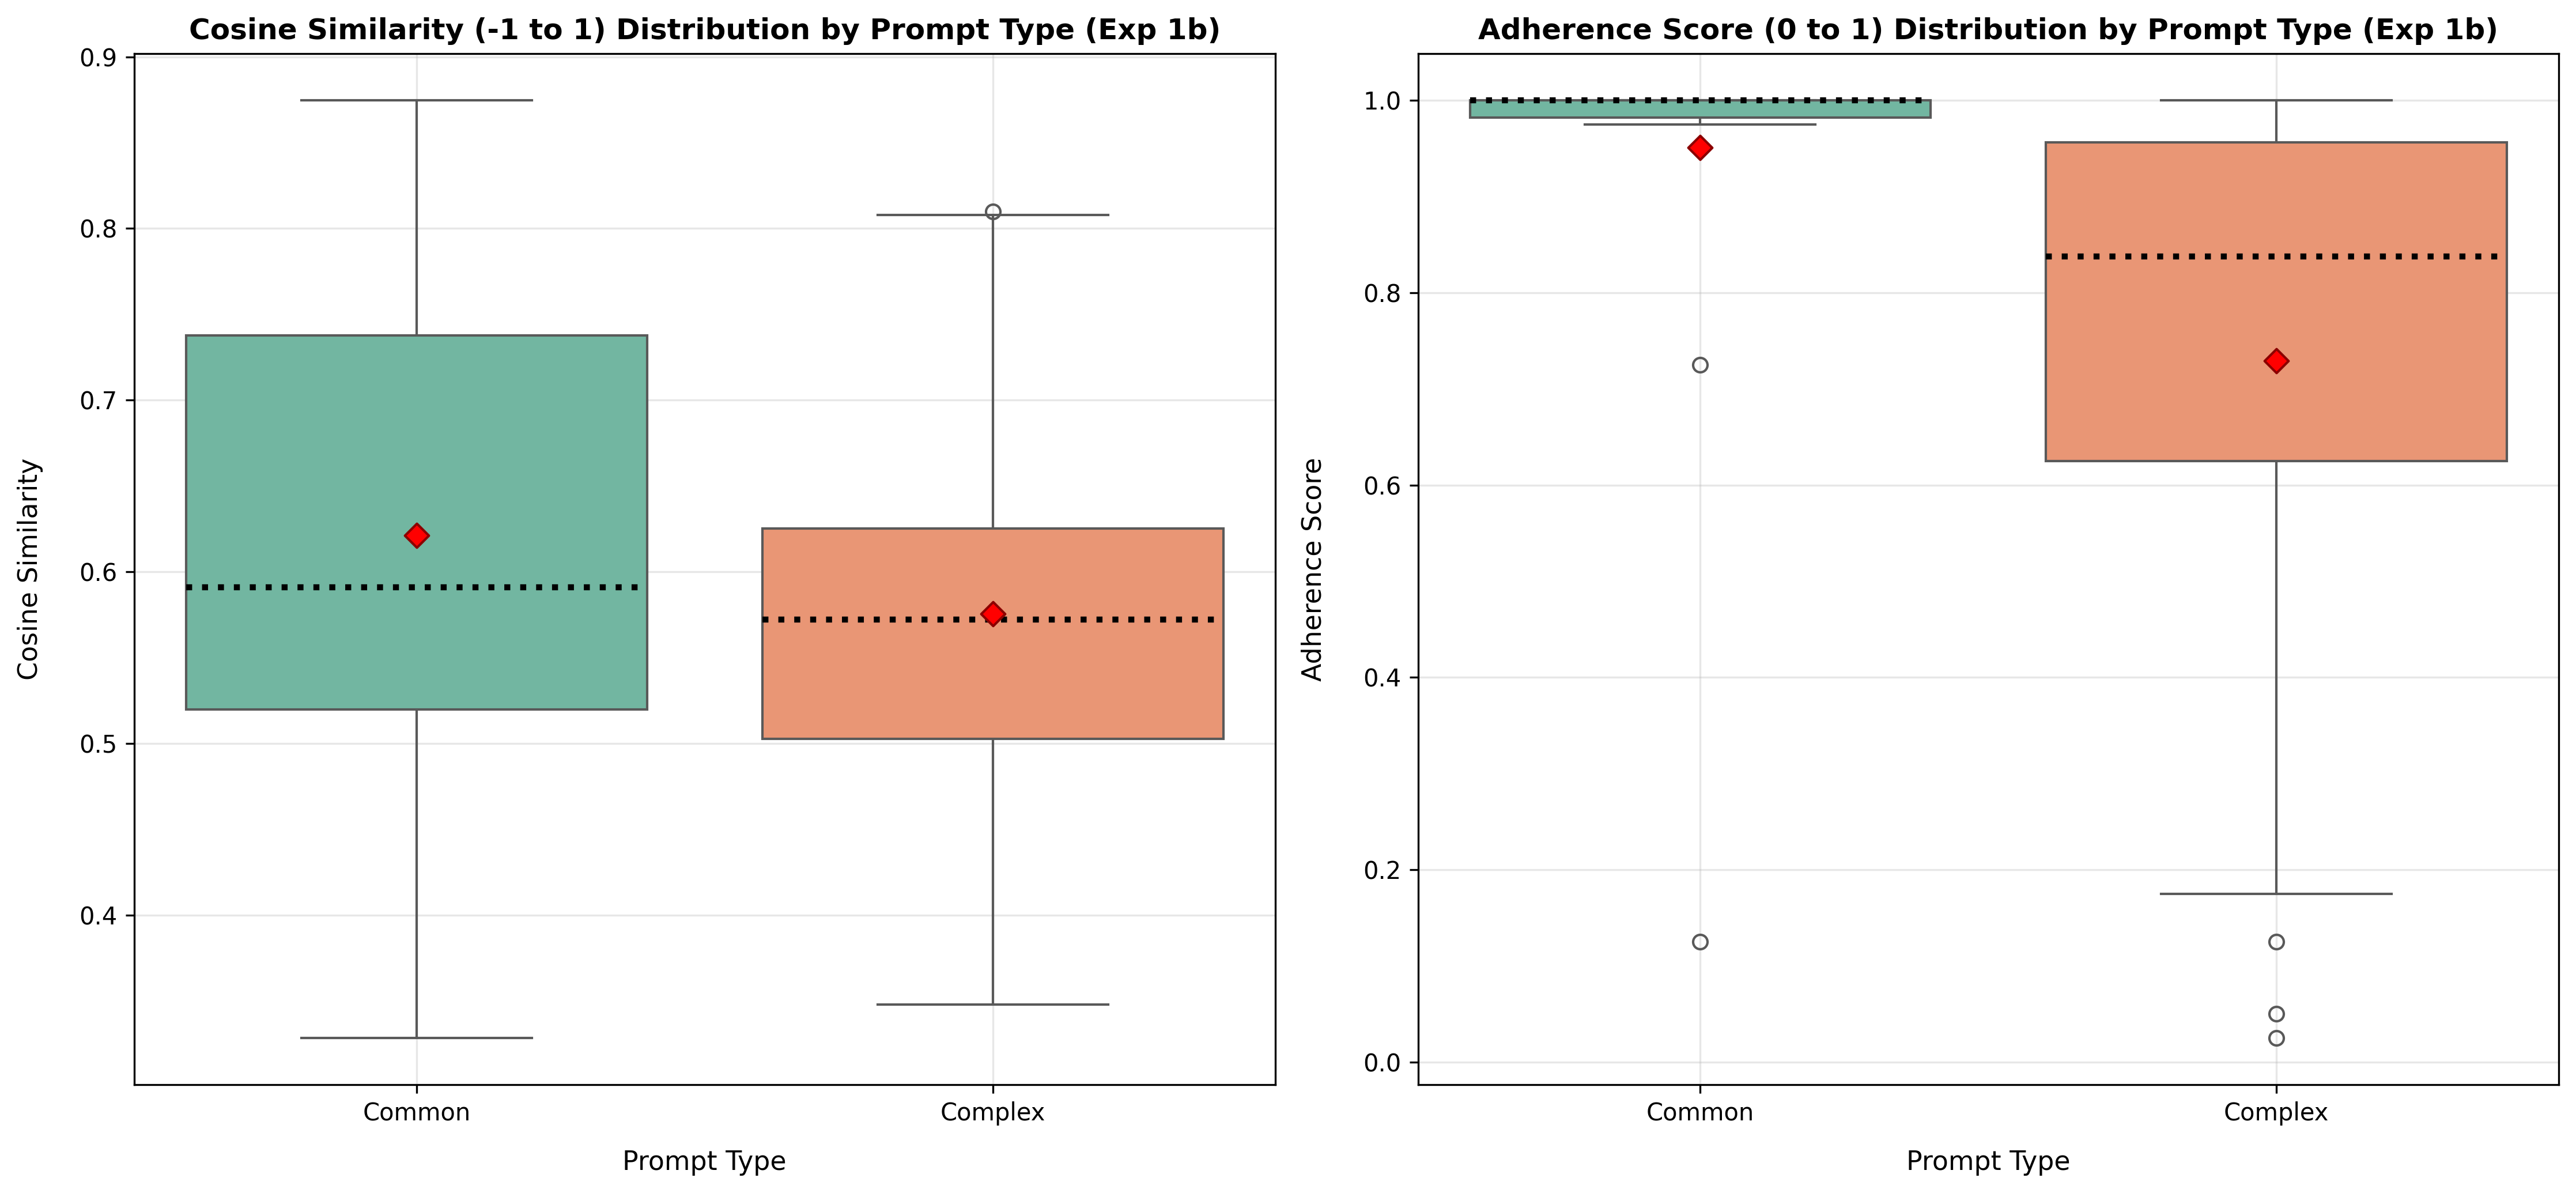

In [56]:
# Boxplot for cosine_similarity and adherence_score by prompt_type
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
plots['exp1b_dist_by_prompt_type'] = fig

create_seaborn_boxplot(exp1b_df, 'prompt_type', 'cosine_similarity', ax[0], 
                      'Cosine Similarity (-1 to 1) Distribution by Prompt Type (Exp 1b)',
                      'Cosine Similarity', 'Prompt Type')

create_seaborn_boxplot(exp1b_df, 'prompt_type', 'adherence_score', ax[1],
                      'Adherence Score (0 to 1) Distribution by Prompt Type (Exp 1b)', 
                      'Adherence Score', 'Prompt Type')

plt.tight_layout()
plt.show()

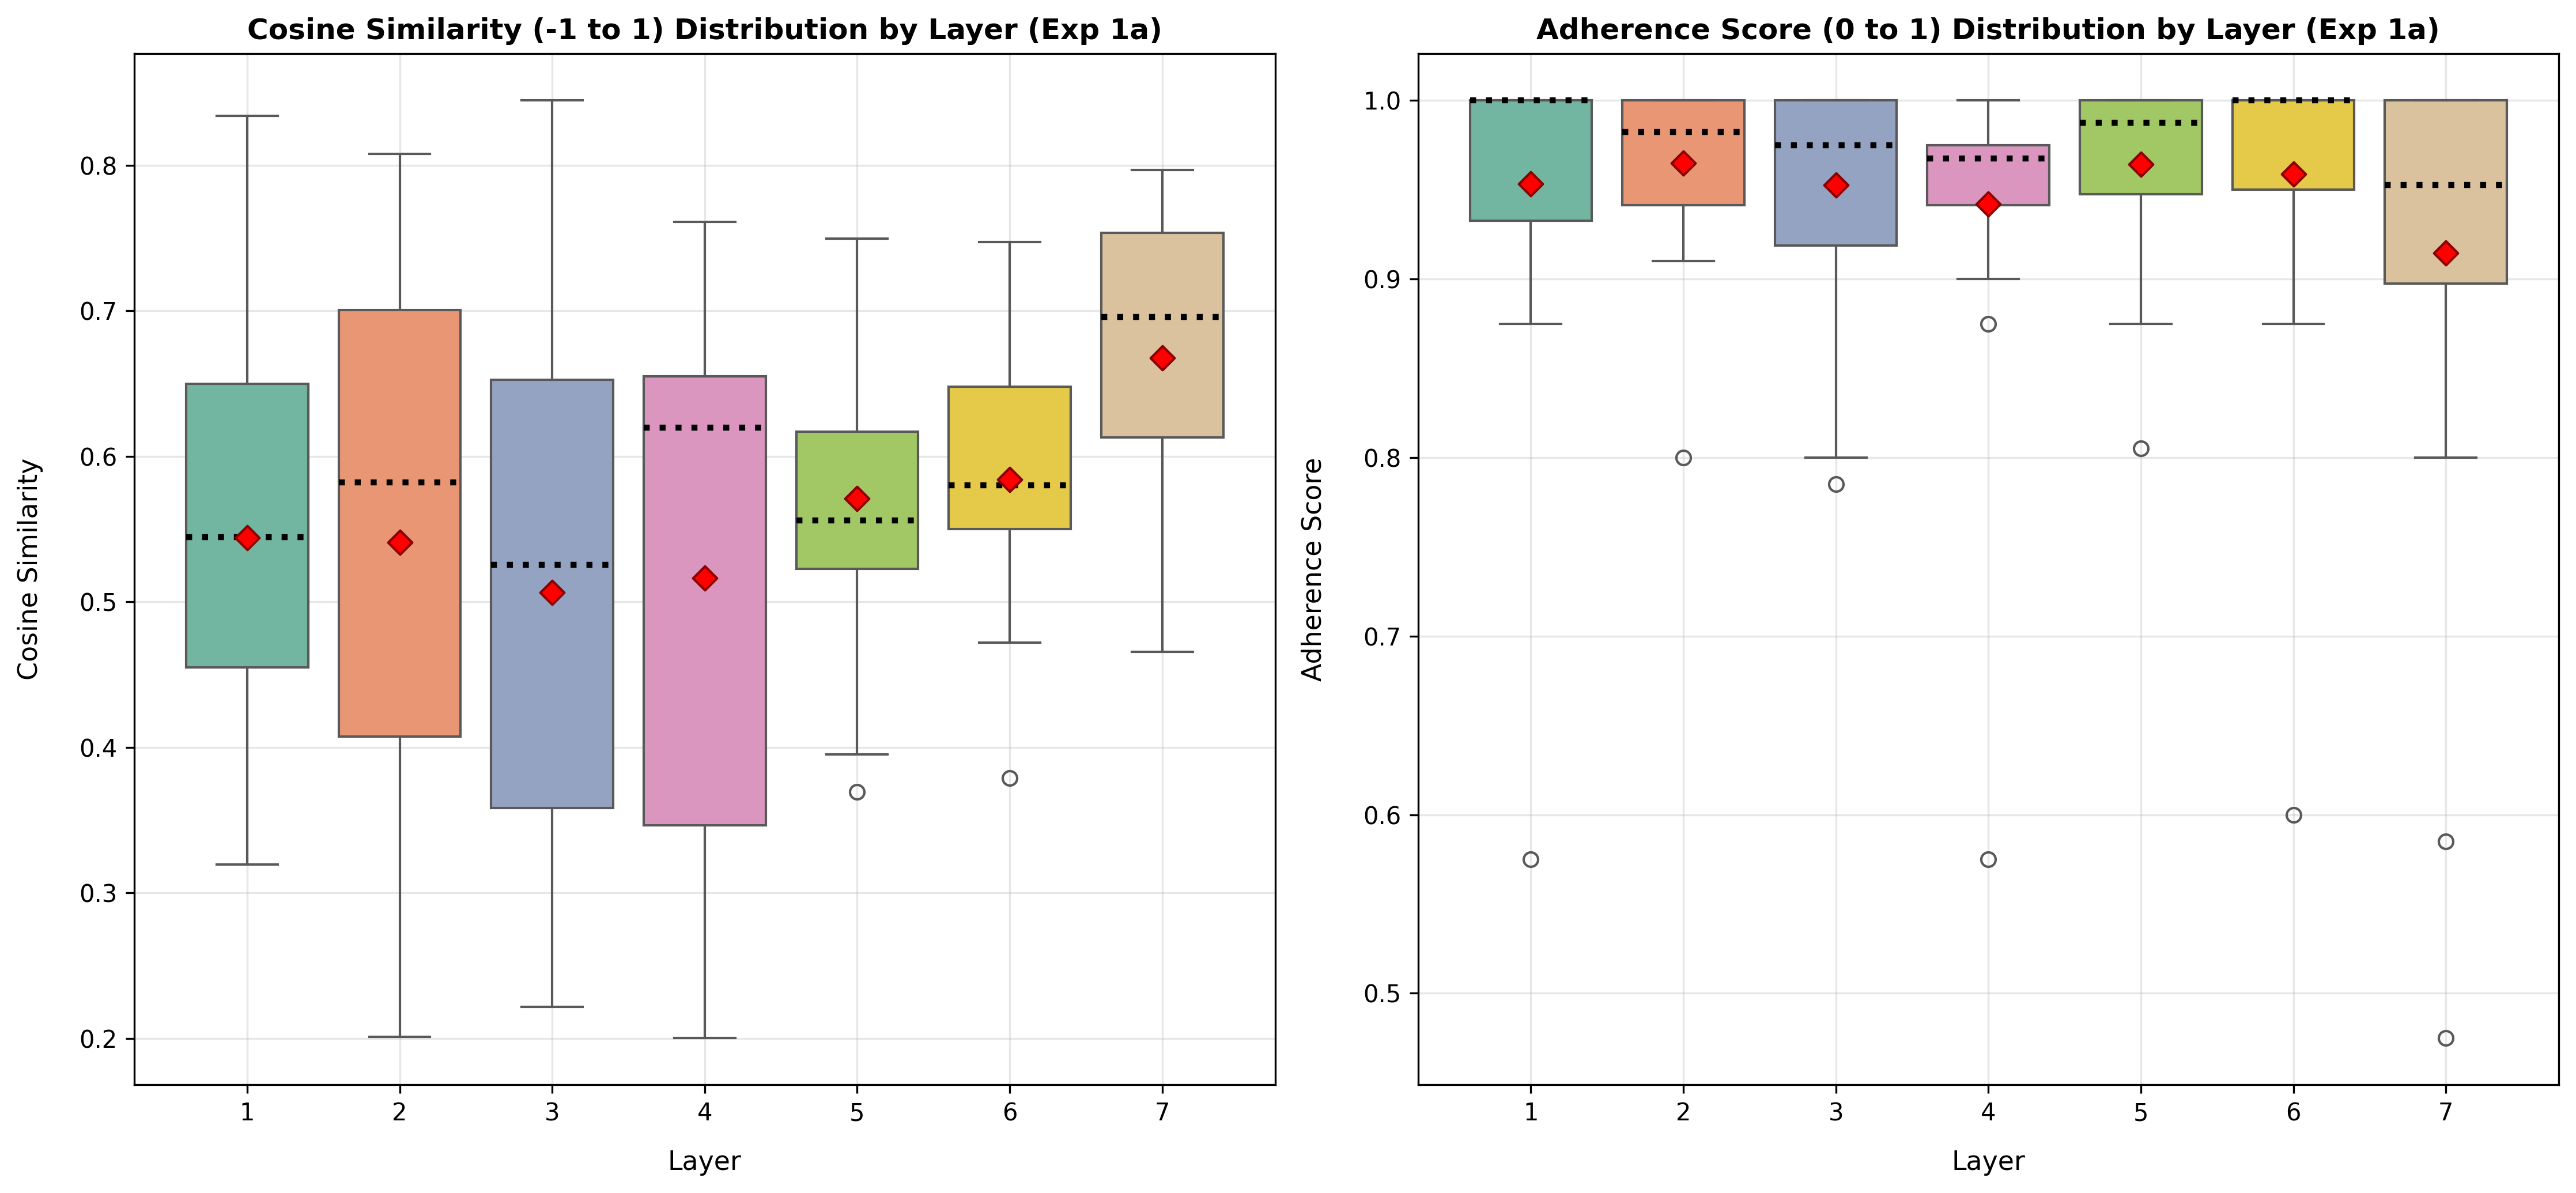

In [57]:
# Boxplot for cosine_similarity and adherence_score by layer
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
plots['exp1a_dist_by_layer'] = fig

create_seaborn_boxplot(exp1a_df, 'layer', 'cosine_similarity', ax[0], 
                      'Cosine Similarity (-1 to 1) Distribution by Layer (Exp 1a)',
                      'Cosine Similarity', 'Layer')

create_seaborn_boxplot(exp1a_df, 'layer', 'adherence_score', ax[1],
                      'Adherence Score (0 to 1) Distribution by Layer (Exp 1a)', 
                      'Adherence Score', 'Layer')

plt.tight_layout()
plt.show()

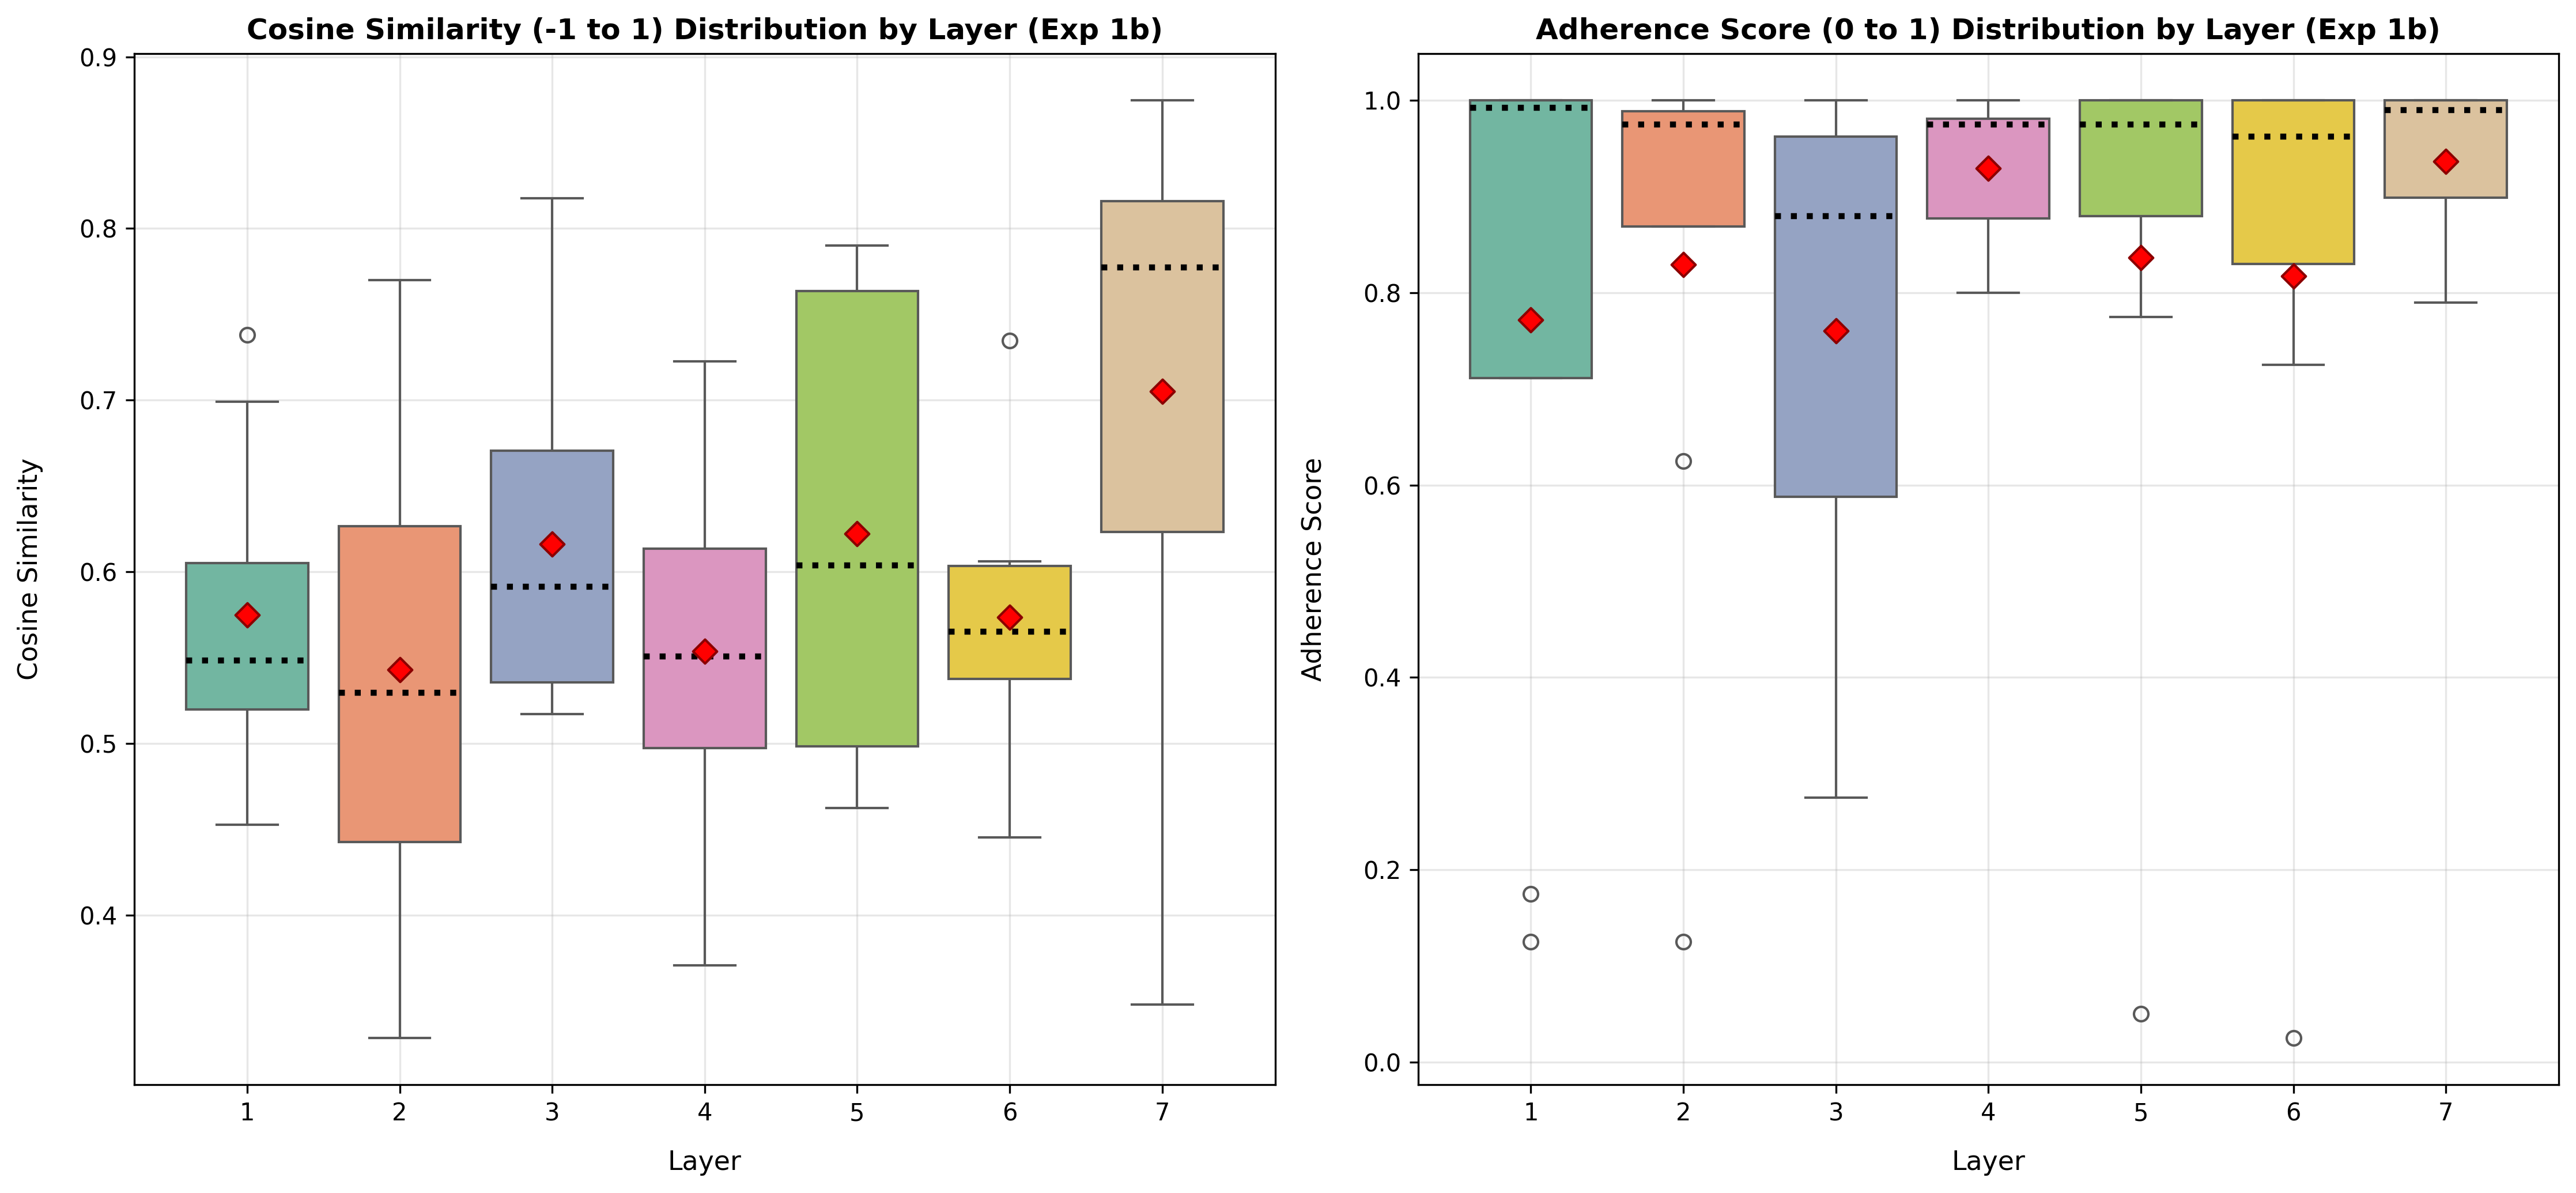

In [58]:
# Boxplot for cosine_similarity and adherence_score by layer
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
plots['exp1b_dist_by_layer'] = fig

create_seaborn_boxplot(exp1b_df, 'layer', 'cosine_similarity', ax[0], 
                      'Cosine Similarity (-1 to 1) Distribution by Layer (Exp 1b)',
                      'Cosine Similarity', 'Layer')

create_seaborn_boxplot(exp1b_df, 'layer', 'adherence_score', ax[1],
                      'Adherence Score (0 to 1) Distribution by Layer (Exp 1b)', 
                      'Adherence Score', 'Layer')

plt.tight_layout()
plt.show()

In [59]:
# # Boxplot for cosine_similarity and adherence_score by question_type
# fig, ax = plt.subplots(1, 2, figsize=(15, 7))
# plots['exp1a_dist_by_question_type'] = fig

# sns.boxplot(x='question_type', y='cosine_similarity', data=exp1a_df, ax=ax[0], color='lightcoral')
# ax[0].set_title('Cosine Similarity Distribution by Question Type (Exp 1a)')
# ax[0].tick_params(axis='x', rotation=45)

# sns.boxplot(x='question_type', y='adherence_score', data=exp1a_df, ax=ax[1], color='lightcoral')
# ax[1].set_title('Adherence Score Distribution by Question Type (Exp 1a)')
# ax[1].tick_params(axis='x', rotation=45)

# plt.tight_layout()
# plt.show()

In [60]:
# # Boxplot for cosine_similarity and adherence_score by question_type
# fig, ax = plt.subplots(1, 2, figsize=(15, 7))
# plots['exp1b_dist_by_question_type'] = fig

# sns.boxplot(x='question_type', y='cosine_similarity', data=exp1b_df, ax=ax[0], color='lightcoral')
# ax[0].set_title('Cosine Similarity Distribution by Question Type (Exp 1b)')
# ax[0].tick_params(axis='x', rotation=45)

# sns.boxplot(x='question_type', y='adherence_score', data=exp1b_df, ax=ax[1], color='lightcoral')
# ax[1].set_title('Adherence Score Distribution by Question Type (Exp 1b)')
# ax[1].tick_params(axis='x', rotation=45)

# plt.tight_layout()
# plt.show()

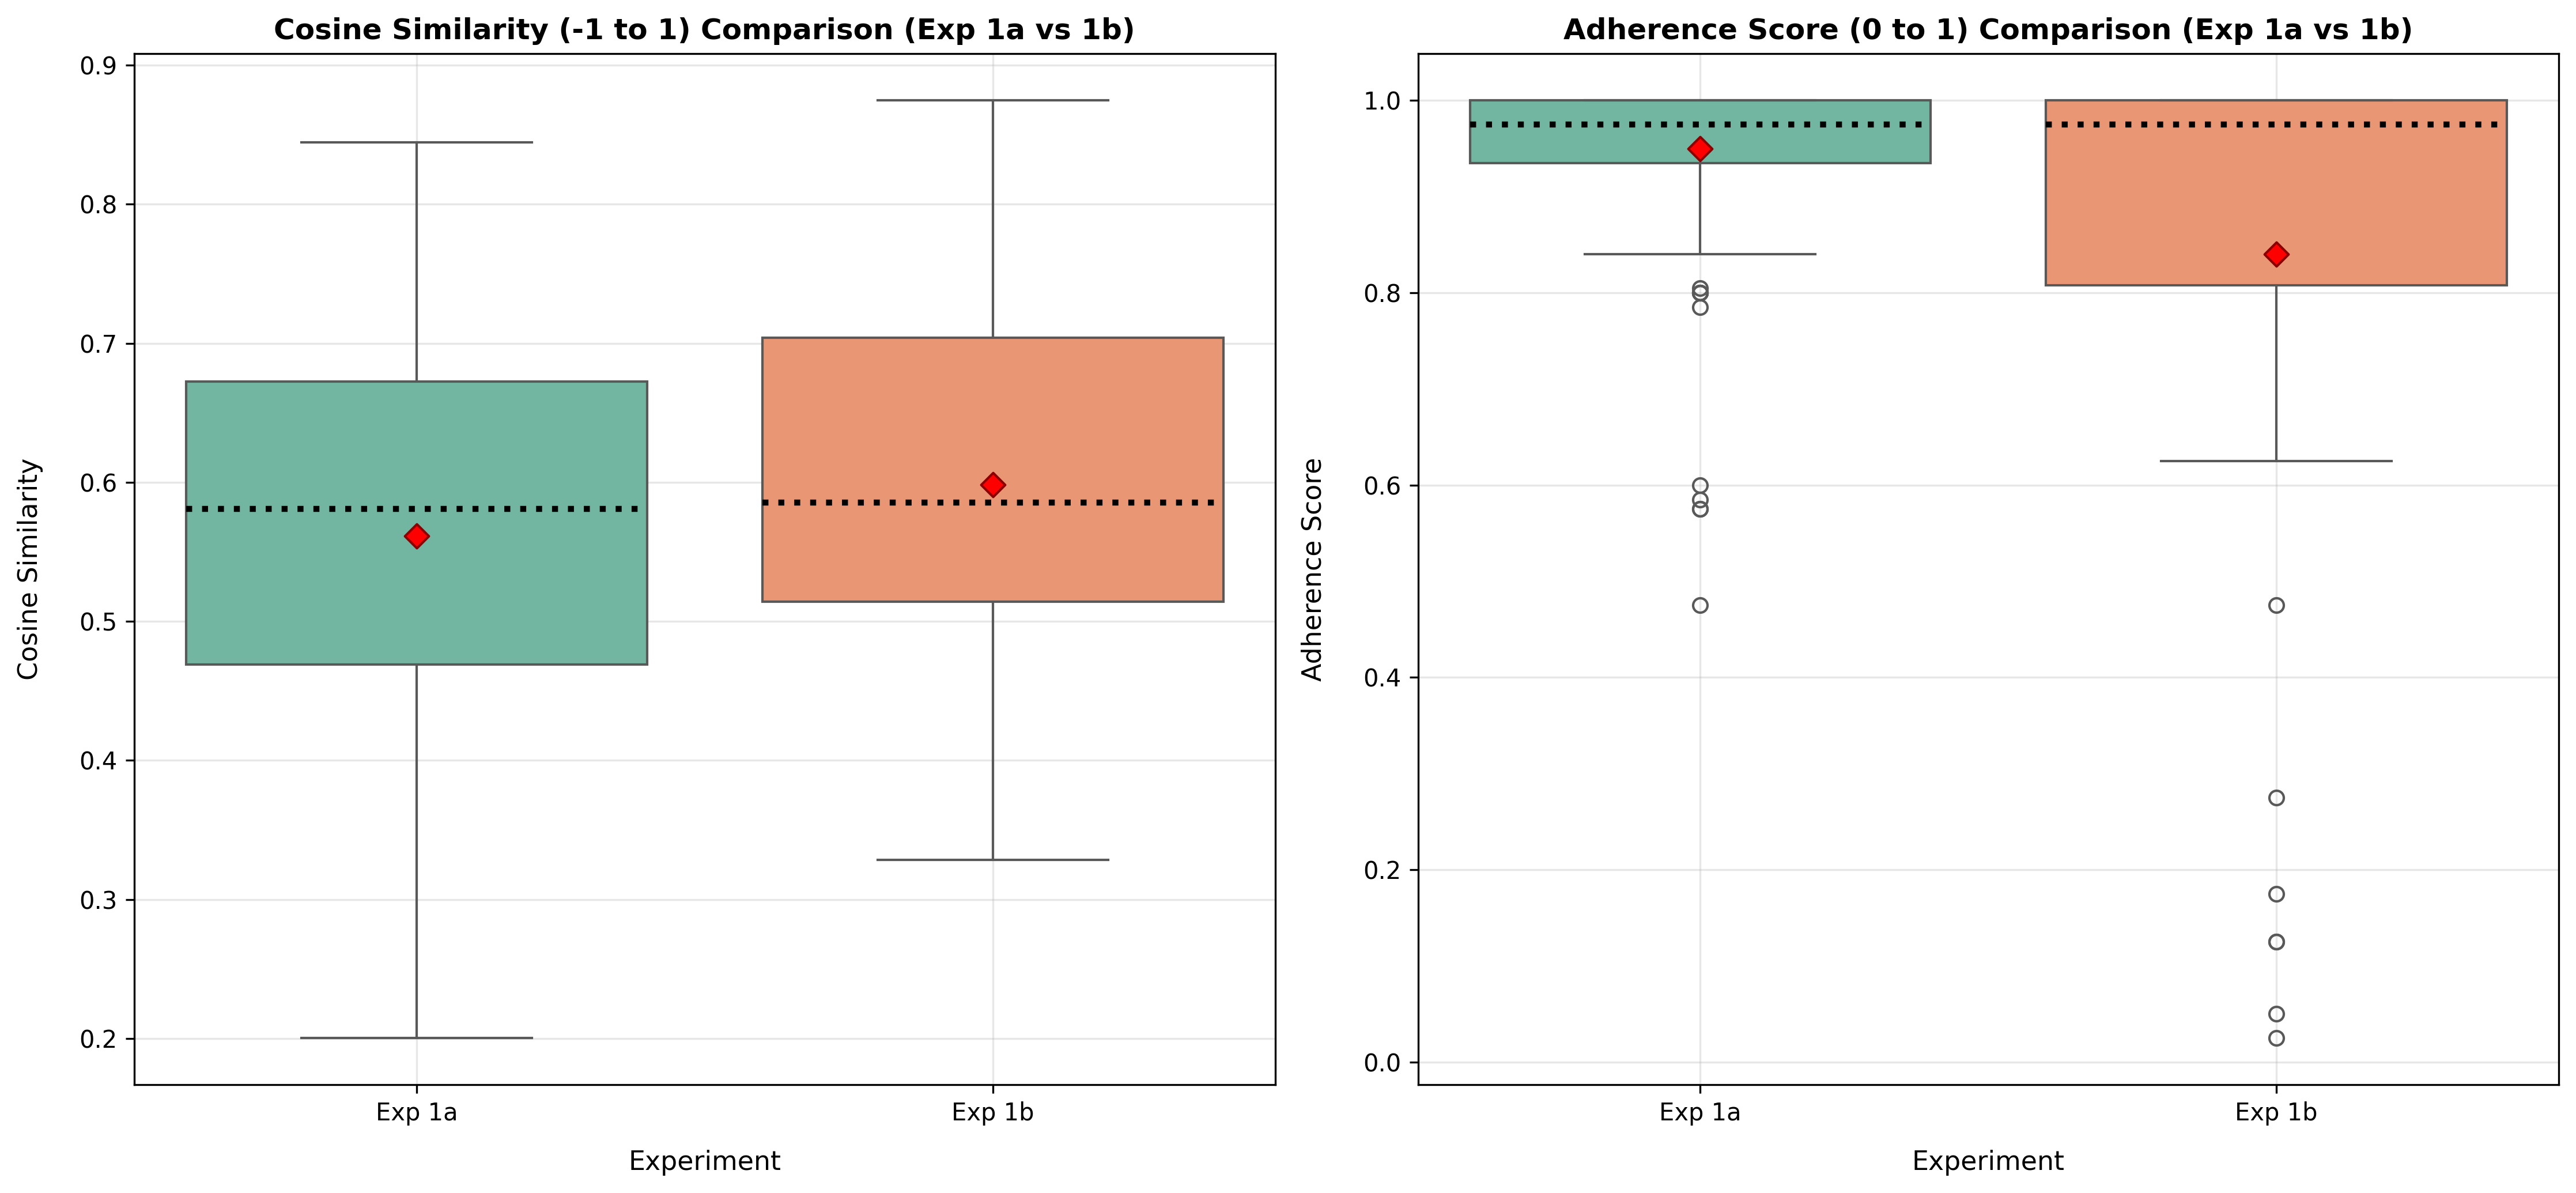

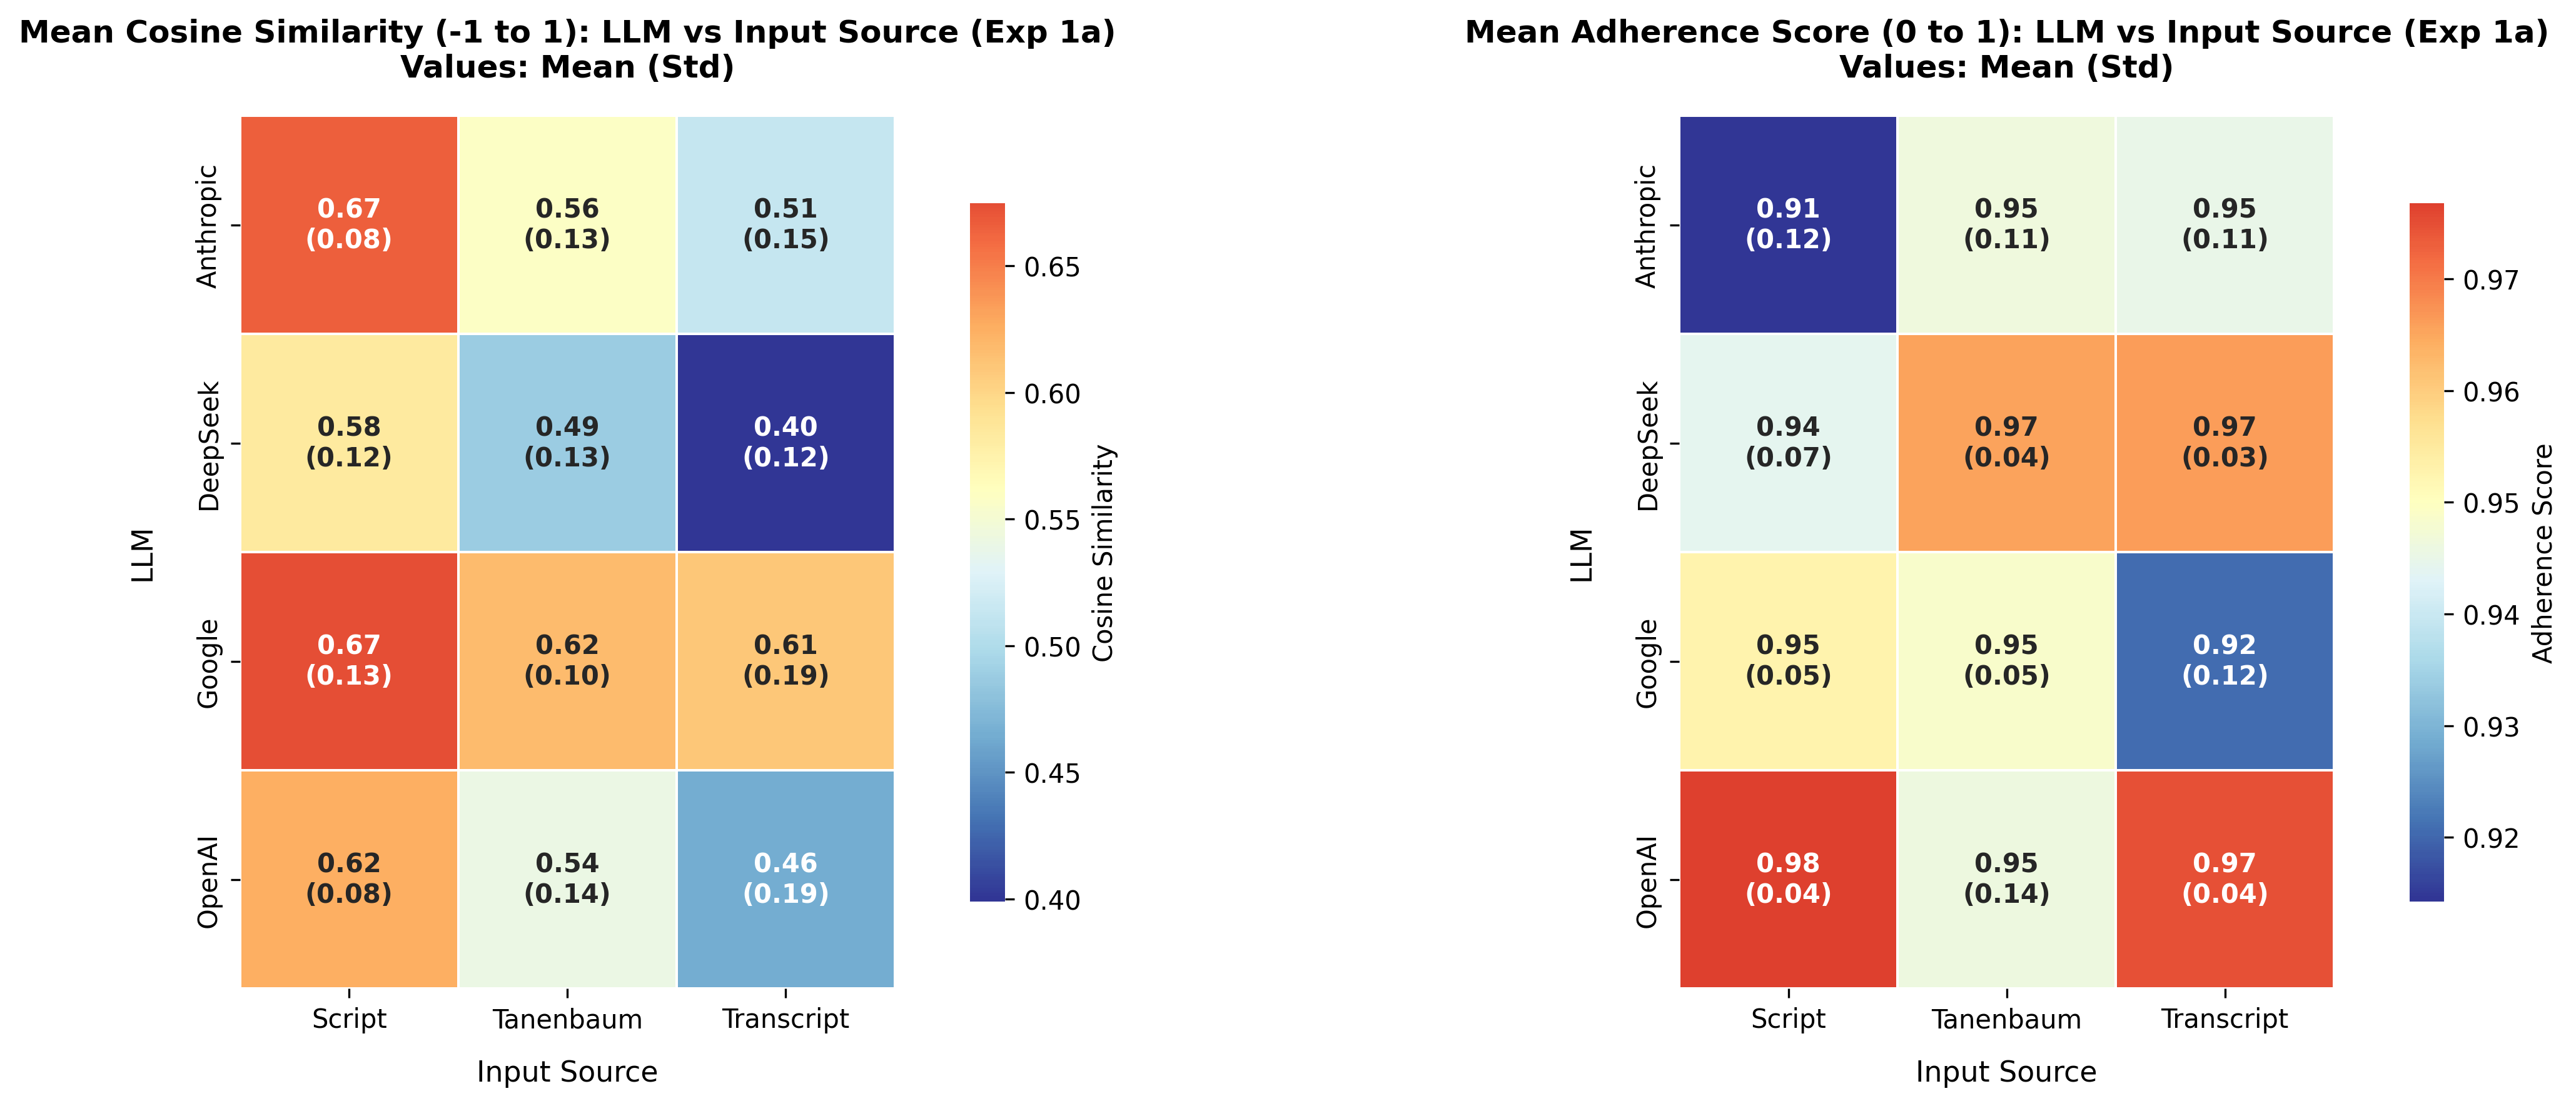

In [61]:
exp1a_temp = exp1a_df.copy()
exp1b_temp = exp1b_df.copy()

exp1a_temp['experiment'] = '1a'
exp1b_temp['experiment'] = '1b'

combined_df = pd.concat([exp1a_temp, exp1b_temp])

fig, ax = plt.subplots(1, 2, figsize=(15, 7))
plots['exp1_comparison'] = fig

create_seaborn_boxplot(combined_df, 'experiment', 'cosine_similarity', ax[0], 
                      'Cosine Similarity (-1 to 1) Comparison (Exp 1a vs 1b)',
                      'Cosine Similarity', 'Experiment')

create_seaborn_boxplot(combined_df, 'experiment', 'adherence_score', ax[1],
                      'Adherence Score (0 to 1) Comparison (Exp 1a vs 1b)', 
                      'Adherence Score', 'Experiment')

plt.tight_layout()
plt.show()

# Updated combined heatmap section
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# For cosine similarity
llm_vs_input_source_cos_sim_1a_std_final = llm_vs_input_source_cos_sim_1a["std"].copy()
annot_matrix_cosine_final = llm_vs_input_source_cos_sim_1a_display.copy()
for i in range(len(llm_vs_input_source_cos_sim_1a_display.index)):
    for j in range(len(llm_vs_input_source_cos_sim_1a_display.columns)):
        mean_val = llm_vs_input_source_cos_sim_1a_display.iloc[i, j]
        std_val = llm_vs_input_source_cos_sim_1a_std_final.iloc[i, j]
        if pd.notna(mean_val) and pd.notna(std_val):
            annot_matrix_cosine_final.iloc[i, j] = f"{mean_val:.2f}\n({std_val:.2f})"
        elif pd.notna(mean_val):
            annot_matrix_cosine_final.iloc[i, j] = f"{mean_val:.2f}"

sns.heatmap(llm_vs_input_source_cos_sim_1a_display, 
            annot=annot_matrix_cosine_final, 
            fmt='', 
            cmap='RdYlBu_r',
            center=llm_vs_input_source_cos_sim_1a_display.mean().mean(),
            square=True,
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Cosine Similarity'},
            annot_kws={'size': 10, 'weight': 'bold'},
            ax=ax1)
ax1.set_title("Mean Cosine Similarity (-1 to 1): LLM vs Input Source (Exp 1a)\nValues: Mean (Std)", 
              fontsize=12, fontweight='bold', pad=15)
ax1.set_ylabel("LLM", fontsize=11, labelpad=15)
ax1.set_xlabel("Input Source", fontsize=11, labelpad=10)

# For adherence score
llm_vs_input_source_adherence_1a_std_final = llm_vs_input_source_adherence_1a["std"].copy()
annot_matrix_adherence_final = llm_vs_input_source_adherence_1a_display.copy()
for i in range(len(llm_vs_input_source_adherence_1a_display.index)):
    for j in range(len(llm_vs_input_source_adherence_1a_display.columns)):
        mean_val = llm_vs_input_source_adherence_1a_display.iloc[i, j]
        std_val = llm_vs_input_source_adherence_1a_std_final.iloc[i, j]
        if pd.notna(mean_val) and pd.notna(std_val):
            annot_matrix_adherence_final.iloc[i, j] = f"{mean_val:.2f}\n({std_val:.2f})"
        elif pd.notna(mean_val):
            annot_matrix_adherence_final.iloc[i, j] = f"{mean_val:.2f}"

sns.heatmap(llm_vs_input_source_adherence_1a_display, 
            annot=annot_matrix_adherence_final, 
            fmt='', 
            cmap='RdYlBu_r',
            center=llm_vs_input_source_adherence_1a_display.mean().mean(),
            square=True,
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Adherence Score'},
            annot_kws={'size': 10, 'weight': 'bold'},
            ax=ax2)
ax2.set_title("Mean Adherence Score (0 to 1): LLM vs Input Source (Exp 1a)\nValues: Mean (Std)", 
              fontsize=12, fontweight='bold', pad=15)
ax2.set_ylabel("LLM", fontsize=11, labelpad=15)
ax2.set_xlabel("Input Source", fontsize=11, labelpad=10)

plt.tight_layout()
plt.show()


## Experiment 1b

### 2.1: Metrics by LLM

In [62]:
llm_metrics_1b = exp1b_df.groupby("llm")[["cosine_similarity", "adherence_score"]].agg(
    ["mean", "std"]
)
tables["exp1b_metrics_by_llm"] = llm_metrics_1b
display(llm_metrics_1b)


cosine_similarity           adherence_score          
                       mean       std            mean       std
llm                                                            
anthropic          0.639624  0.120503        0.903571  0.123186
deepseek           0.535659  0.120614        0.731071  0.355929
google             0.618493  0.155956        0.920357  0.142942
openai             0.599776  0.107091        0.806071  0.358974

### 2.2: Metrics by Input Source

In [63]:
input_source_metrics_1b = exp1b_df.groupby("input_source")[
    ["cosine_similarity", "adherence_score"]
].agg(["mean", "std"])
tables["exp1b_metrics_by_input_source"] = input_source_metrics_1b
display(input_source_metrics_1b)

cosine_similarity           adherence_score          
                                mean       std            mean       std
input_source                                                            
script_manipulated          0.598388  0.129878        0.840268  0.273503

### 2.3: Metrics by Prompt Type

In [64]:
prompt_type_metrics_1b = exp1b_df.groupby("prompt_type")[
    ["cosine_similarity", "adherence_score"]
].agg(["mean", "std"])
tables["exp1b_metrics_by_prompt_type"] = prompt_type_metrics_1b
display(prompt_type_metrics_1b)

cosine_similarity           adherence_score          
                         mean       std            mean       std
prompt_type                                                      
common               0.621259  0.137741        0.951250  0.170368
complex              0.575516  0.119598        0.729286  0.312741

### 2.4: Metrics by Layer

In [65]:
layer_metrics_1b = exp1b_df.groupby("layer")[["cosine_similarity", "adherence_score"]].agg(
    ["mean", "std"]
)
tables["exp1b_metrics_by_layer"] = layer_metrics_1b
display(layer_metrics_1b)

cosine_similarity           adherence_score          
                   mean       std            mean       std
layer                                                      
1              0.574804  0.096853        0.771875  0.385866
2              0.542807  0.150093        0.829375  0.311063
3              0.616298  0.103107        0.760625  0.273750
4              0.553682  0.110393        0.929375  0.082870
5              0.622286  0.137674        0.836250  0.326964
6              0.573622  0.083204        0.817500  0.334055
7              0.705217  0.175271        0.936875  0.093310

### 2.5: Cosine Similarity: LLM vs Input Source

In [66]:
# TODO important
llm_vs_input_source_cos_sim_1b = pd.pivot_table(
    exp1b_df,
    values="cosine_similarity",
    index="llm",
    columns="input_source",
    aggfunc=["mean", "std"],
)
tables["exp1b_cosine_sim_llm_vs_input_source"] = llm_vs_input_source_cos_sim_1b
display(llm_vs_input_source_cos_sim_1b)

,mean,std
input_source,script_manipulated,script_manipulated
llm,,
anthropic,0.639624,0.120503
deepseek,0.535659,0.120614
google,0.618493,0.155956
openai,0.599776,0.107091


In [67]:

# fig, ax = plt.subplots(figsize=(10, 6))
# plots['exp1b_cosine_sim_llm_vs_input_source'] = fig
# sns.heatmap(llm_vs_input_source_cos_sim_1b["mean"], annot=True, fmt=".2f", cmap="viridis", ax=ax)
# ax.set_title("Mean Cosine Similarity: LLM vs Input Source (Exp 1b)")
# plt.show()


### 2.6: Cosine Similarity: LLM vs Prompt Type

In [68]:
# TODO important
llm_vs_prompt_type_cos_sim_1b = pd.pivot_table(
    exp1b_df,
    values="cosine_similarity",
    index="llm",
    columns="prompt_type",
    aggfunc=["mean", "std"],
)
tables["exp1b_cosine_sim_llm_vs_prompt_type"] = llm_vs_prompt_type_cos_sim_1b
display(llm_vs_prompt_type_cos_sim_1b)

mean                 std          
prompt_type    common   complex    common   complex
llm                                                
anthropic    0.702068  0.577180  0.139379  0.054194
deepseek     0.532872  0.538446  0.123492  0.127482
google       0.648236  0.588749  0.150385  0.167388
openai       0.601861  0.597690  0.100315  0.121553

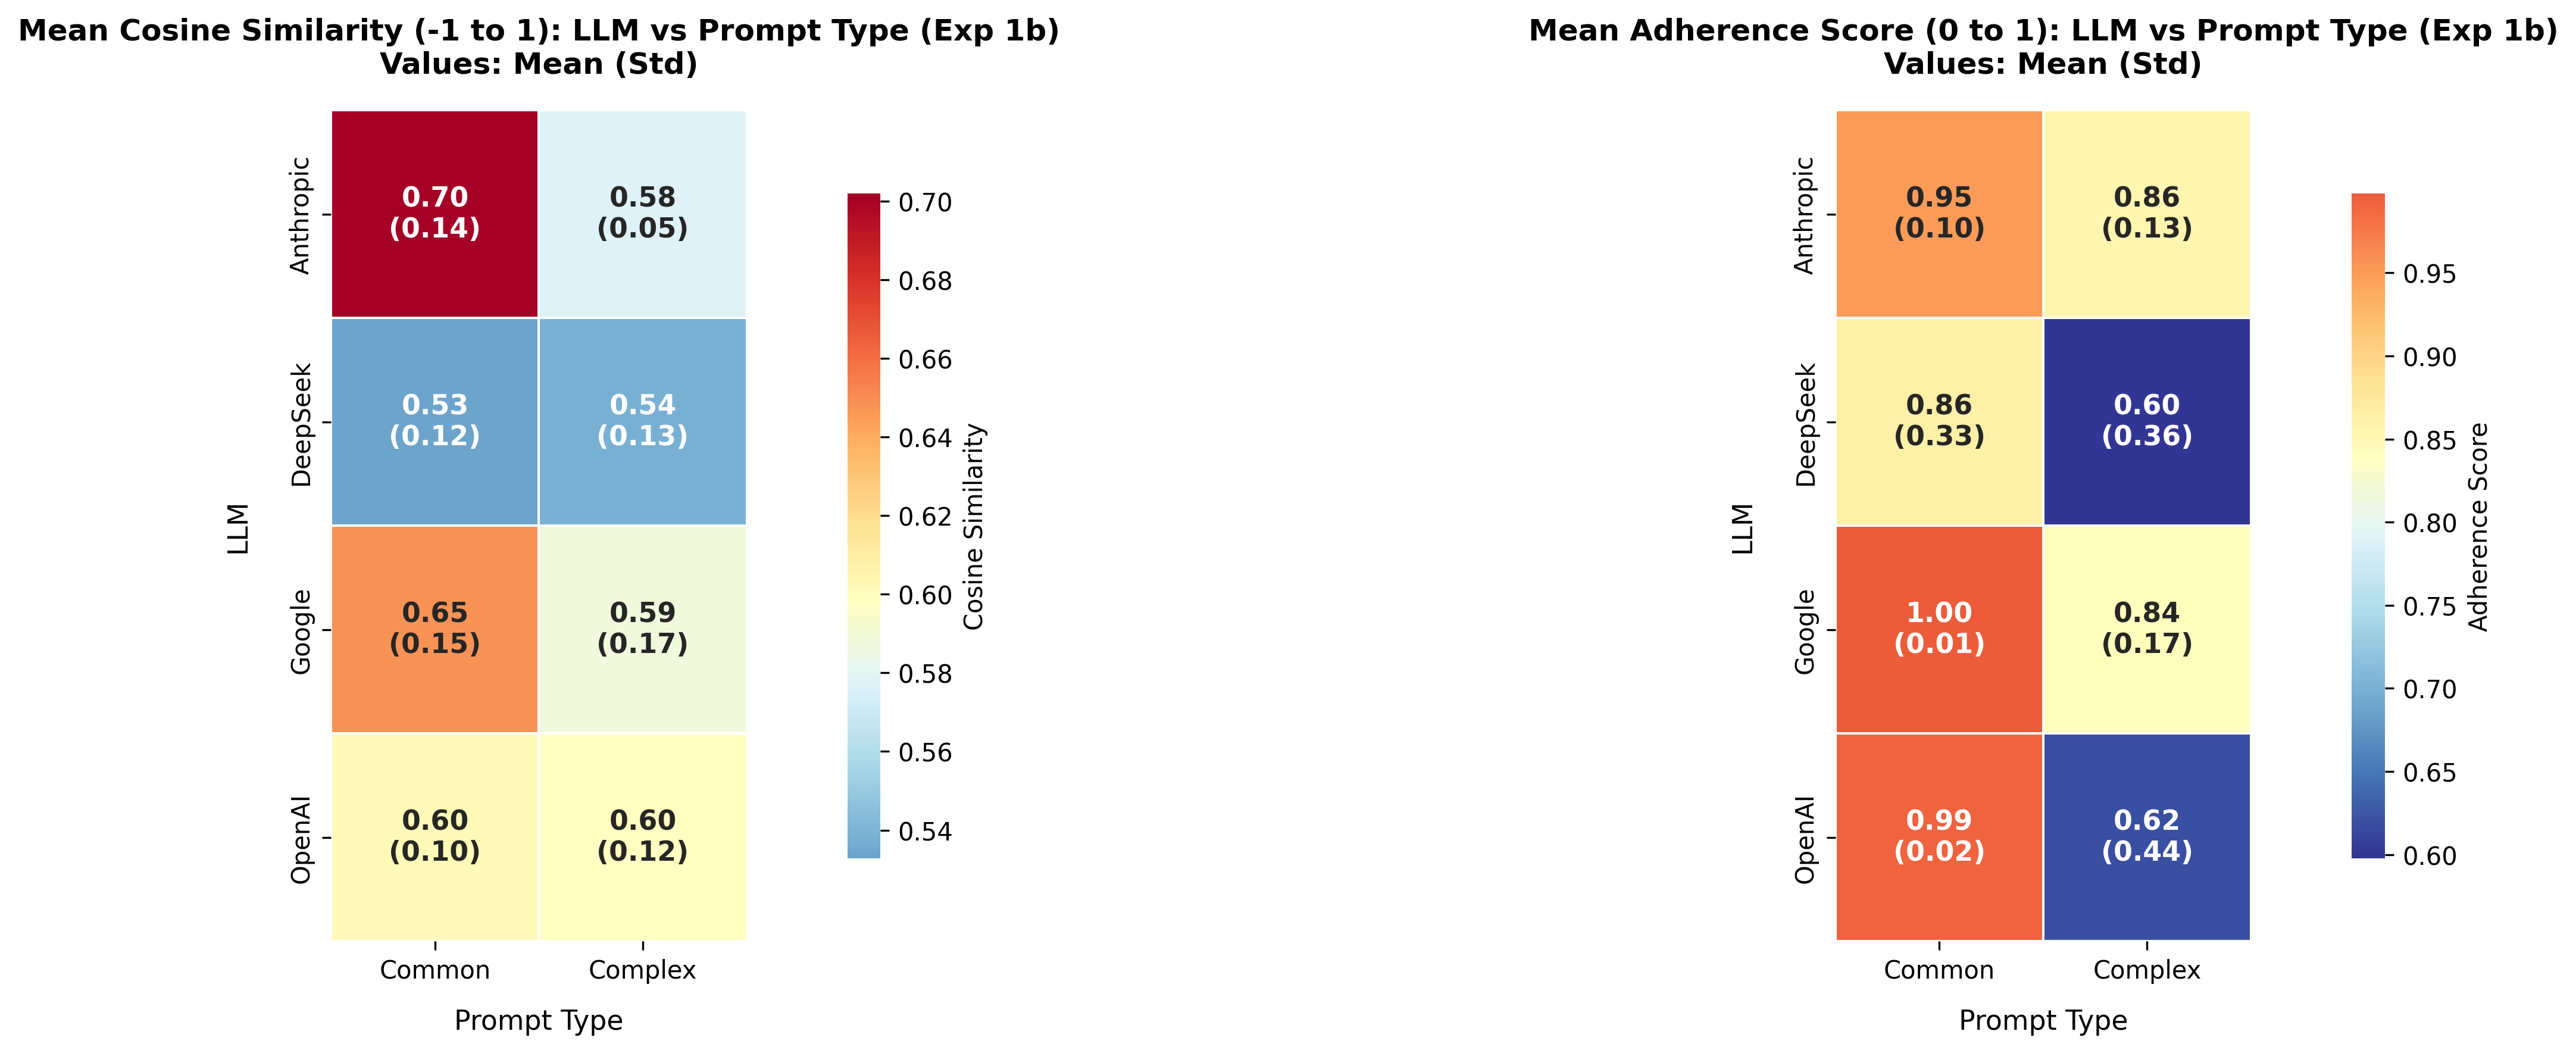

In [69]:
# Combined heatmaps: LLM vs Prompt Type (Exp 1b)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
plots['exp1b_combined_llm_vs_prompt_type'] = fig

llm_vs_prompt_type_cos_sim_1b_display = llm_vs_prompt_type_cos_sim_1b["mean"].copy()
llm_vs_prompt_type_cos_sim_1b_std = llm_vs_prompt_type_cos_sim_1b["std"].copy()

# Create annotation matrix with mean and std
annot_matrix_cosine_prompt_1b = llm_vs_prompt_type_cos_sim_1b_display.copy()
for i in range(len(llm_vs_prompt_type_cos_sim_1b_display.index)):
    for j in range(len(llm_vs_prompt_type_cos_sim_1b_display.columns)):
        mean_val = llm_vs_prompt_type_cos_sim_1b_display.iloc[i, j]
        std_val = llm_vs_prompt_type_cos_sim_1b_std.iloc[i, j]
        if pd.notna(mean_val) and pd.notna(std_val):
            annot_matrix_cosine_prompt_1b.iloc[i, j] = f"{mean_val:.2f}\n({std_val:.2f})"
        elif pd.notna(mean_val):
            annot_matrix_cosine_prompt_1b.iloc[i, j] = f"{mean_val:.2f}"

llm_vs_prompt_type_cos_sim_1b_display.index = llm_vs_prompt_type_cos_sim_1b_display.index.map({
    'anthropic': 'Anthropic', 'openai': 'OpenAI', 'google': 'Google', 'deepseek': 'DeepSeek'
})
llm_vs_prompt_type_cos_sim_1b_display.columns = llm_vs_prompt_type_cos_sim_1b_display.columns.map({
    'common': 'Common', 'complex': 'Complex'
})
annot_matrix_cosine_prompt_1b.index = annot_matrix_cosine_prompt_1b.index.map({
    'anthropic': 'Anthropic', 'openai': 'OpenAI', 'google': 'Google', 'deepseek': 'DeepSeek'
})
annot_matrix_cosine_prompt_1b.columns = annot_matrix_cosine_prompt_1b.columns.map({
    'common': 'Common', 'complex': 'Complex'
})

sns.heatmap(llm_vs_prompt_type_cos_sim_1b_display, 
            annot=annot_matrix_cosine_prompt_1b, 
            fmt='', 
            cmap='RdYlBu_r',
            center=llm_vs_prompt_type_cos_sim_1b_display.mean().mean(),
            square=True,
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Cosine Similarity'},
            annot_kws={'size': 11, 'weight': 'bold'},
            ax=ax1)
ax1.set_title("Mean Cosine Similarity (-1 to 1): LLM vs Prompt Type (Exp 1b)\nValues: Mean (Std)", 
              fontsize=12, fontweight='bold', pad=15)
ax1.set_xlabel("Prompt Type", fontsize=11, labelpad=10)
ax1.set_ylabel("LLM", fontsize=11, labelpad=15)

llm_vs_prompt_type_adherence_1b = pd.pivot_table(
    exp1b_df,
    values="adherence_score",
    index="llm",
    columns="prompt_type",
    aggfunc=["mean", "std"],
)

llm_vs_prompt_type_adherence_1b_display = llm_vs_prompt_type_adherence_1b["mean"].copy()
llm_vs_prompt_type_adherence_1b_std = llm_vs_prompt_type_adherence_1b["std"].copy()

# Create annotation matrix with mean and std
annot_matrix_adherence_prompt_1b = llm_vs_prompt_type_adherence_1b_display.copy()
for i in range(len(llm_vs_prompt_type_adherence_1b_display.index)):
    for j in range(len(llm_vs_prompt_type_adherence_1b_display.columns)):
        mean_val = llm_vs_prompt_type_adherence_1b_display.iloc[i, j]
        std_val = llm_vs_prompt_type_adherence_1b_std.iloc[i, j]
        if pd.notna(mean_val) and pd.notna(std_val):
            annot_matrix_adherence_prompt_1b.iloc[i, j] = f"{mean_val:.2f}\n({std_val:.2f})"
        elif pd.notna(mean_val):
            annot_matrix_adherence_prompt_1b.iloc[i, j] = f"{mean_val:.2f}"

llm_vs_prompt_type_adherence_1b_display.index = llm_vs_prompt_type_adherence_1b_display.index.map({
    'anthropic': 'Anthropic', 'openai': 'OpenAI', 'google': 'Google', 'deepseek': 'DeepSeek'
})
llm_vs_prompt_type_adherence_1b_display.columns = llm_vs_prompt_type_adherence_1b_display.columns.map({
    'common': 'Common', 'complex': 'Complex'
})
annot_matrix_adherence_prompt_1b.index = annot_matrix_adherence_prompt_1b.index.map({
    'anthropic': 'Anthropic', 'openai': 'OpenAI', 'google': 'Google', 'deepseek': 'DeepSeek'
})
annot_matrix_adherence_prompt_1b.columns = annot_matrix_adherence_prompt_1b.columns.map({
    'common': 'Common', 'complex': 'Complex'
})

sns.heatmap(llm_vs_prompt_type_adherence_1b_display, 
            annot=annot_matrix_adherence_prompt_1b, 
            fmt='', 
            cmap='RdYlBu_r',
            center=llm_vs_prompt_type_adherence_1b_display.mean().mean(),
            square=True,
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Adherence Score'},
            annot_kws={'size': 11, 'weight': 'bold'},
            ax=ax2)
ax2.set_title("Mean Adherence Score (0 to 1): LLM vs Prompt Type (Exp 1b)\nValues: Mean (Std)", 
              fontsize=12, fontweight='bold', pad=15)
ax2.set_xlabel("Prompt Type", fontsize=11, labelpad=10)
ax2.set_ylabel("LLM", fontsize=11, labelpad=15)

plt.tight_layout()
plt.show()


### 2.7: Adherence Score: LLM vs Prompt Type

In [70]:
# TODO important
llm_vs_prompt_type_adherence_1b = pd.pivot_table(
    exp1b_df,
    values="adherence_score",
    index="llm",
    columns="prompt_type",
    aggfunc=["mean", "std"],
)
tables["exp1b_adherence_llm_vs_prompt_type"] = llm_vs_prompt_type_adherence_1b
display(llm_vs_prompt_type_adherence_1b)

mean                 std          
prompt_type    common   complex    common   complex
llm                                                
anthropic    0.950000  0.857143  0.101036  0.132817
deepseek     0.864286  0.597857  0.326553  0.355585
google       0.997857  0.842857  0.005669  0.173850
openai       0.992857  0.619286  0.018898  0.444339

In [71]:
# TODO can be important
# Diese Heatmap ist jetzt im kombinierten Plot oben enthalten
# fig, ax = plt.subplots(figsize=(10, 6))
# plots['exp1b_adherence_llm_vs_prompt_type'] = fig
# sns.heatmap(llm_vs_prompt_type_adherence_1b["mean"], annot=True, fmt=".2f", cmap="viridis", ax=ax)
# ax.set_title("Mean Adherence Score: LLM vs Prompt Type (Exp 1b)")
# plt.show()


### 2.8: Adherence Score: LLM vs Input Source

In [72]:
#TODO important
llm_vs_input_source_adherence_1b = pd.pivot_table(
    exp1b_df,
    values="adherence_score",
    index="llm",
    columns="input_source",
    aggfunc=["mean", "std"],
)
tables["exp1b_adherence_llm_vs_input_source"] = llm_vs_input_source_adherence_1b
display(llm_vs_input_source_adherence_1b)

,mean,std
input_source,script_manipulated,script_manipulated
llm,,
anthropic,0.903571,0.123186
deepseek,0.731071,0.355929
google,0.920357,0.142942
openai,0.806071,0.358974


### Including a Run without a Source

Creating plots for exp1a_no_source data...
Data shape: (84, 7)
Comparison sources: ['script' 'tanenbaum' 'transcript']


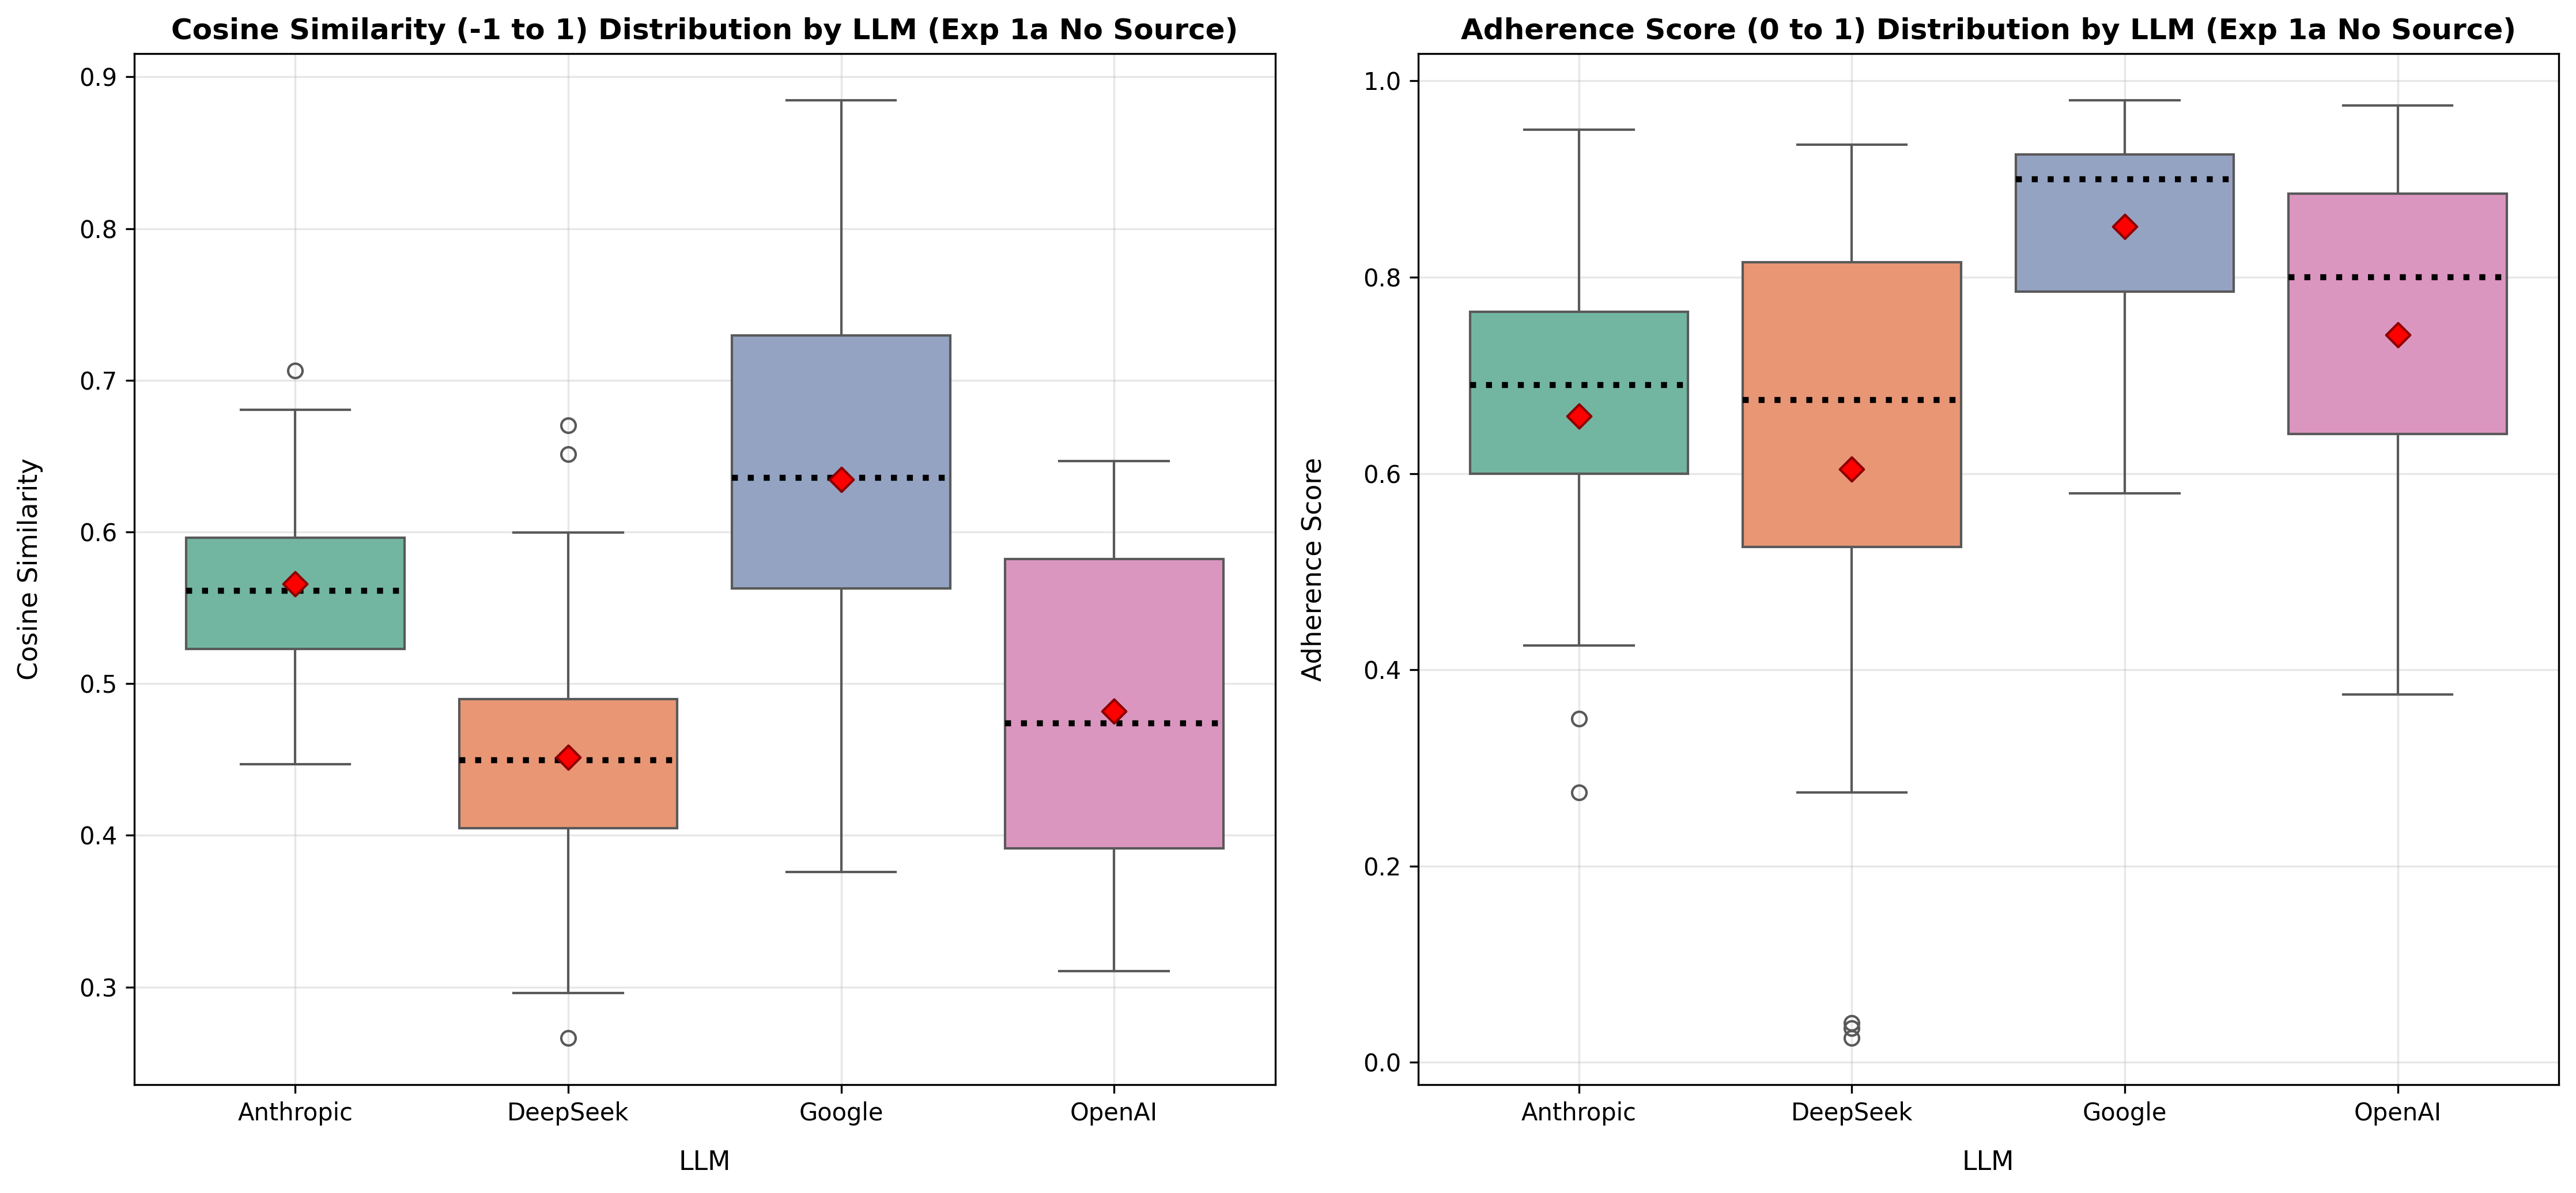

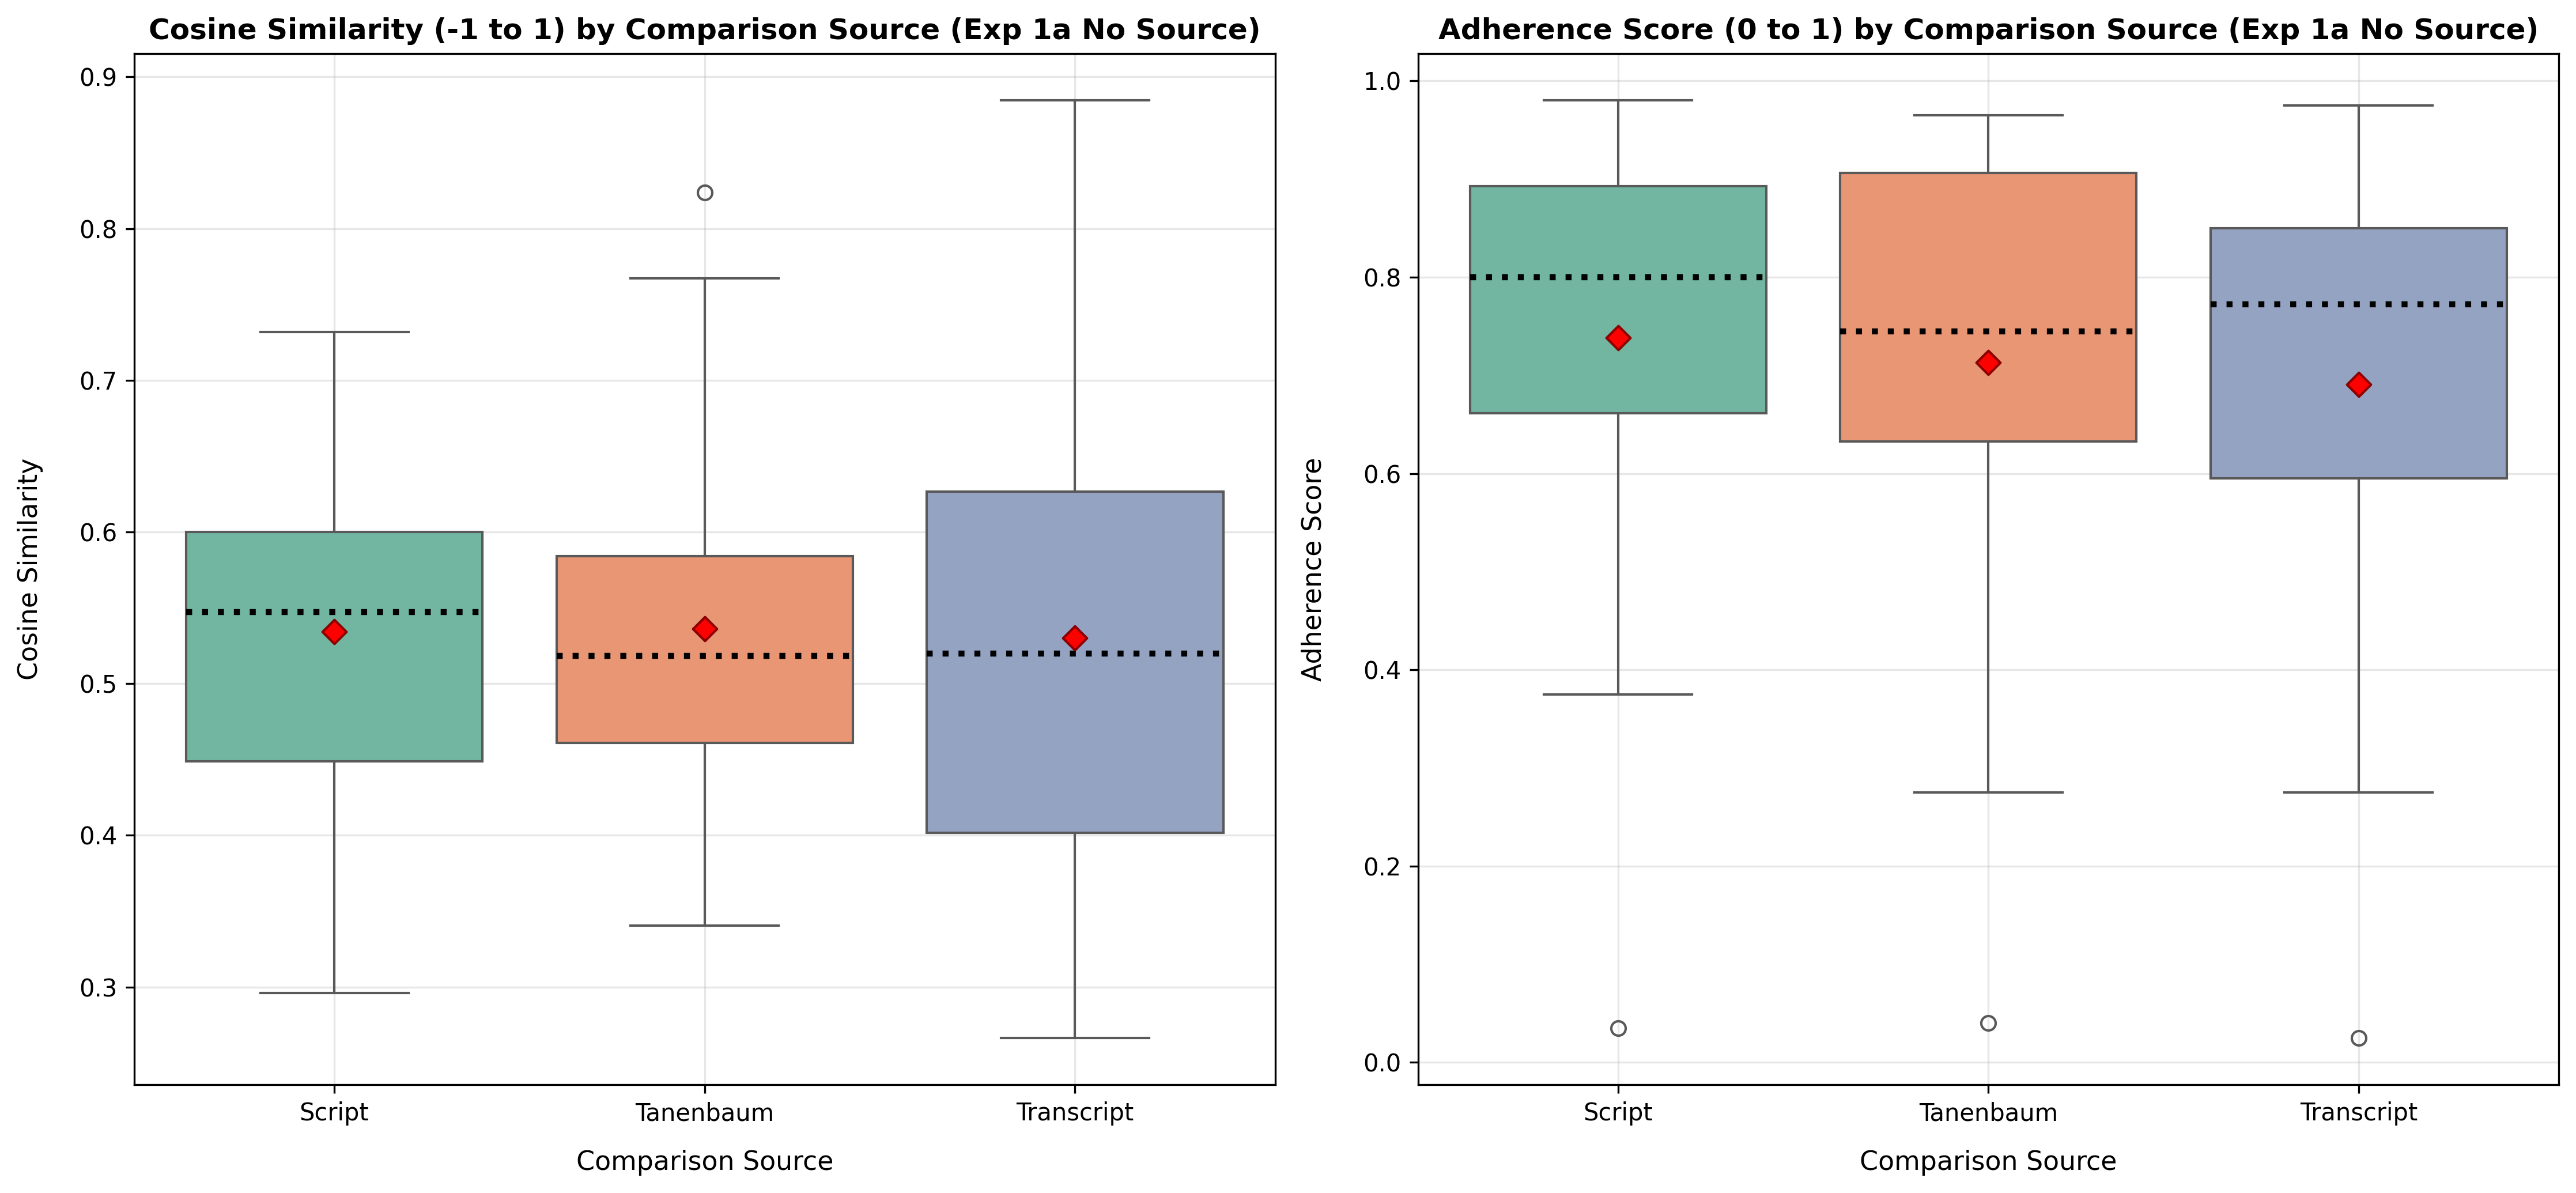

Combined means for cosine similarity:
input_source
script        0.602829
tanenbaum     0.546101
transcript    0.507626
Name: cosine_similarity, dtype: float64

Combined means for adherence score:
input_source
script        0.877381
tanenbaum     0.872143
transcript    0.864702
Name: adherence_score, dtype: float64


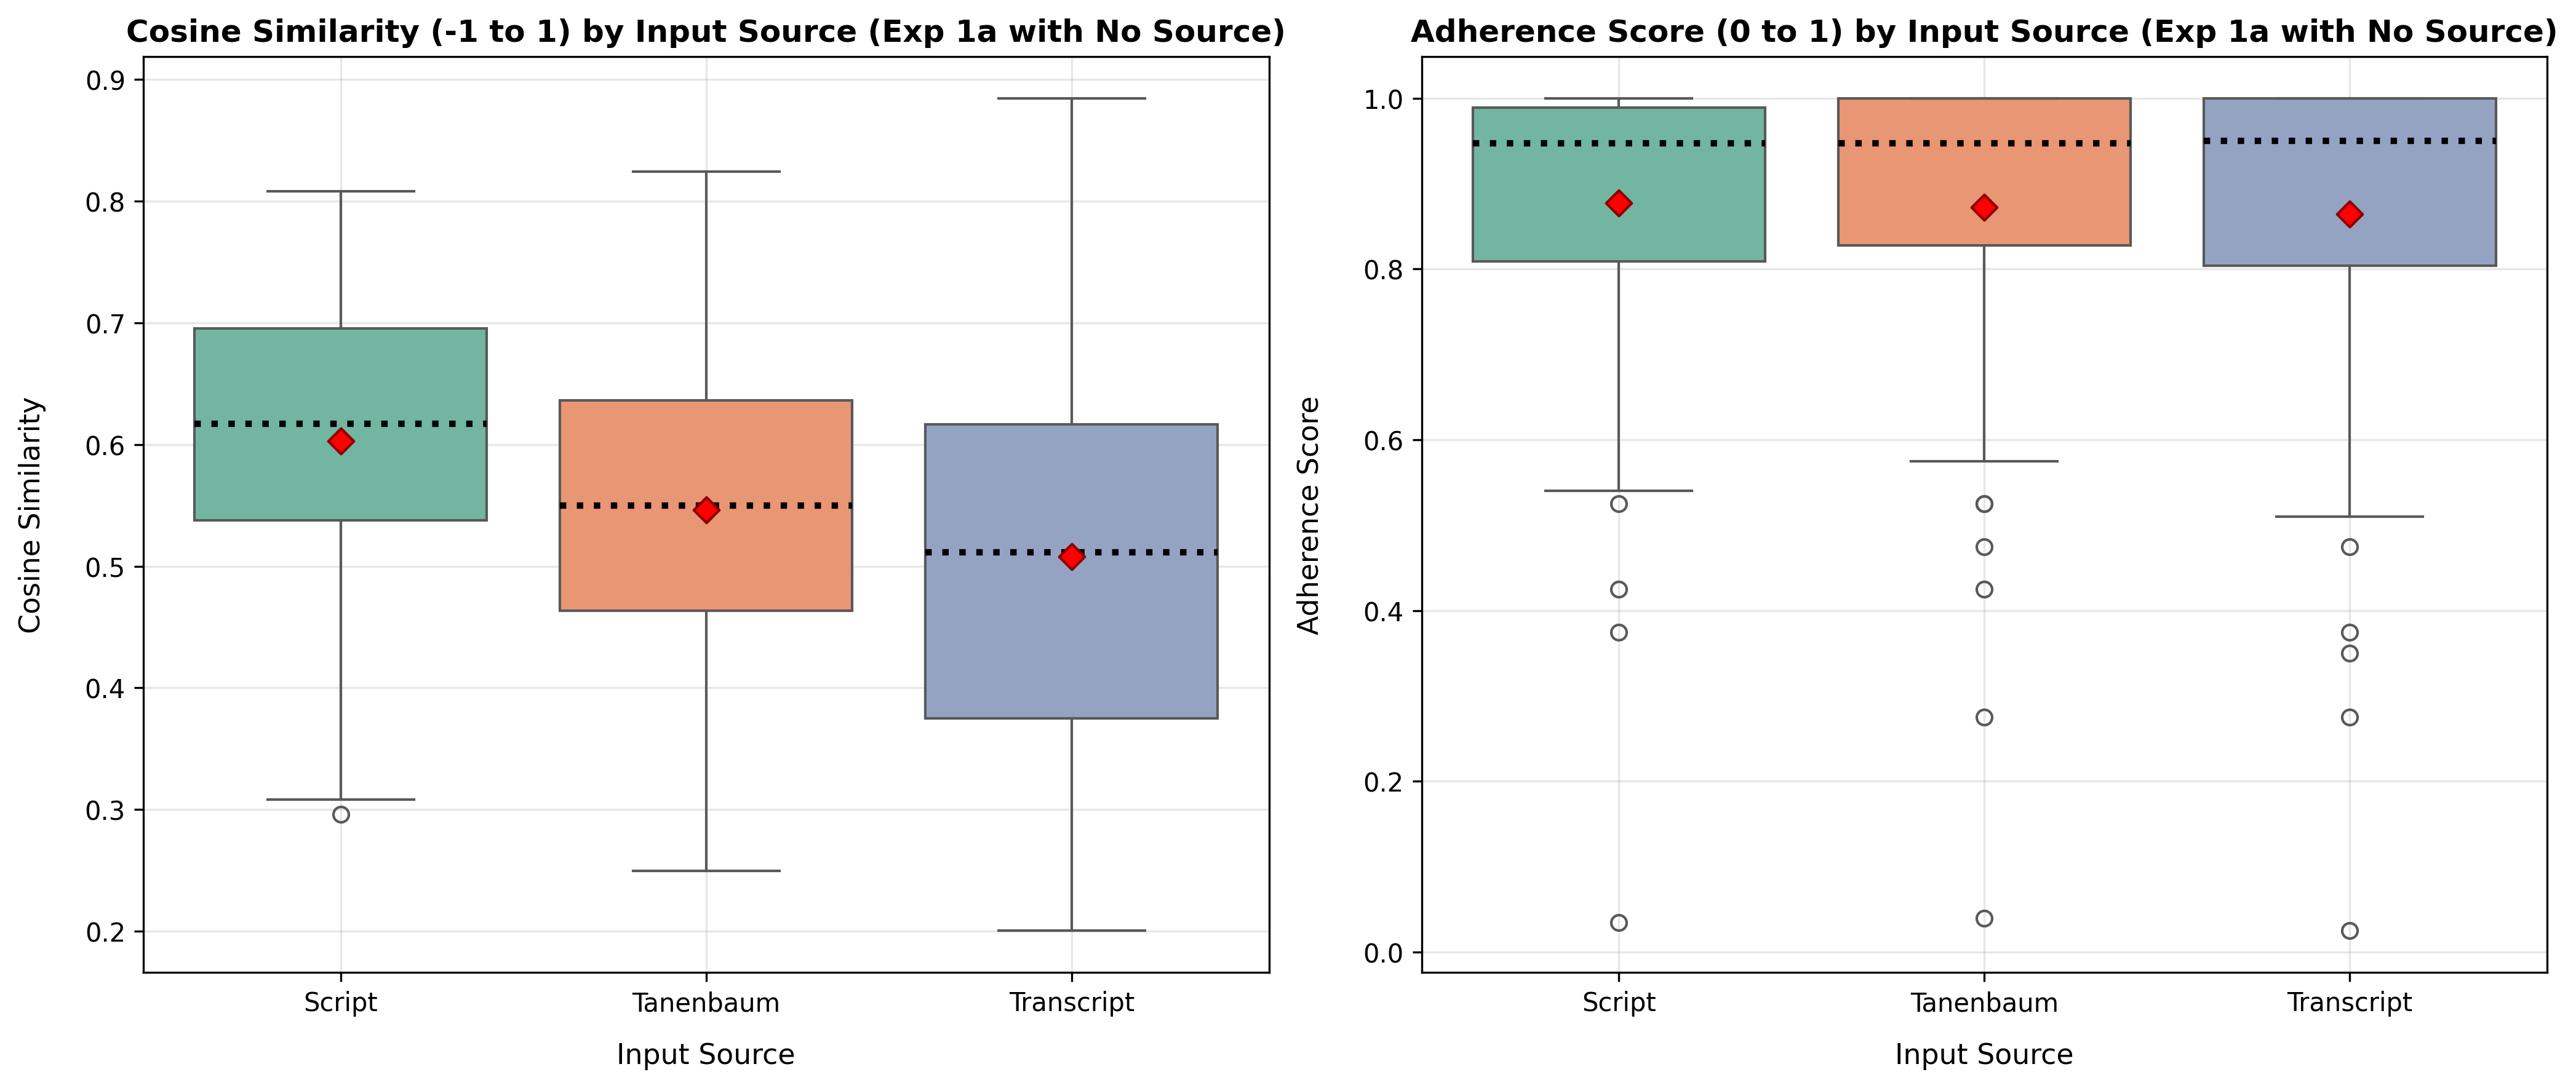

exp1a_no_source plots created successfully!


In [73]:
## Experiment 1a No Source

if exp1a_no_source_df is not None:
    print("Creating plots for exp1a_no_source data...")
    
    # Check if we have the new expanded structure
    has_comparison_source = 'comparison_source' in exp1a_no_source_df.columns
    
    if has_comparison_source:
        # New expanded structure: plot by comparison_source
        print(f"Data shape: {exp1a_no_source_df.shape}")
        print(f"Comparison sources: {exp1a_no_source_df['comparison_source'].unique()}")
        
        # Plot 1: Distribution by LLM (aggregated across all comparison sources)
        fig, ax = plt.subplots(1, 2, figsize=(15, 7))
        plots['exp1a_no_source_dist_by_llm'] = fig

        create_seaborn_boxplot(exp1a_no_source_df, 'llm', 'cosine_similarity', ax[0], 
                              'Cosine Similarity (-1 to 1) Distribution by LLM (Exp 1a No Source)',
                              'Cosine Similarity', 'LLM')

        create_seaborn_boxplot(exp1a_no_source_df, 'llm', 'adherence_score', ax[1],
                              'Adherence Score (0 to 1) Distribution by LLM (Exp 1a No Source)', 
                              'Adherence Score', 'LLM')

        plt.tight_layout()
        plt.show()
        
        # Plot 2: Distribution by comparison source
        fig, ax = plt.subplots(1, 2, figsize=(15, 7))
        plots['exp1a_no_source_dist_by_comparison_source'] = fig

        create_seaborn_boxplot(exp1a_no_source_df, 'comparison_source', 'cosine_similarity', ax[0], 
                              'Cosine Similarity (-1 to 1) by Comparison Source (Exp 1a No Source)',
                              'Cosine Similarity', 'Comparison Source')

        create_seaborn_boxplot(exp1a_no_source_df, 'comparison_source', 'adherence_score', ax[1],
                              'Adherence Score (0 to 1) by Comparison Source (Exp 1a No Source)', 
                              'Adherence Score', 'Comparison Source')

        plt.tight_layout()
        plt.show()
        
        # Plot 3: Comparison with regular exp1a data
        exp1a_fresh = pd.read_csv(exp1a_path)
        exp1a_fresh["adherence_score"] = exp1a_fresh[
            ["adherence_score_openai", "adherence_score_anthropic"]
        ].mean(axis=1)
        exp1a_fresh = exp1a_fresh.drop(
            columns=["adherence_score_openai", "adherence_score_anthropic"]
        )
        
        # Create a unified view for comparison
        exp1a_no_source_unified = exp1a_no_source_df.copy()
        exp1a_no_source_unified['input_source'] = exp1a_no_source_unified['comparison_source']
        
        # Combine the data for plotting
        exp1a_combined_df = pd.concat([exp1a_fresh, exp1a_no_source_unified], ignore_index=True)

        # Calculate means properly - combine data first, then calculate means
        combined_means = exp1a_combined_df.groupby('input_source')[['cosine_similarity', 'adherence_score']].mean()

        print("Combined means for cosine similarity:")
        print(combined_means['cosine_similarity'])
        print("\nCombined means for adherence score:")
        print(combined_means['adherence_score'])

        # Create figure for input source comparison
        fig, ax = plt.subplots(1, 2, figsize=(14, 6))
        plots['exp1a_comparison_with_no_source'] = fig

        # Plot cosine similarity by input source with custom means
        create_seaborn_boxplot(exp1a_combined_df, 'input_source', 'cosine_similarity', ax[0], 
                              'Cosine Similarity (-1 to 1) by Input Source (Exp 1a with No Source)', 
                              'Cosine Similarity', 'Input Source',
                              custom_means=combined_means['cosine_similarity'])

        # Plot adherence score by input source with custom means
        create_seaborn_boxplot(exp1a_combined_df, 'input_source', 'adherence_score', ax[1],
                              'Adherence Score (0 to 1) by Input Source (Exp 1a with No Source)', 
                              'Adherence Score', 'Input Source',
                              custom_means=combined_means['adherence_score'])

        plt.tight_layout()
        plt.show()
        
    else:
        # Legacy structure: original plotting code
        # Plot 1: Distribution by LLM for no_source
        fig, ax = plt.subplots(1, 2, figsize=(15, 7))
        plots['exp1a_no_source_dist_by_llm'] = fig

        create_seaborn_boxplot(exp1a_no_source_df, 'llm', 'cosine_similarity', ax[0], 
                              'Cosine Similarity (-1 to 1) Distribution by LLM (Exp 1a No Source)',
                              'Cosine Similarity', 'LLM')

        create_seaborn_boxplot(exp1a_no_source_df, 'llm', 'adherence_score', ax[1],
                              'Adherence Score (0 to 1) Distribution by LLM (Exp 1a No Source)', 
                              'Adherence Score', 'LLM')

        plt.tight_layout()
        plt.show()
        
        # Plot 2: Comparison between all input sources (including no_source)
        exp1a_fresh = pd.read_csv(exp1a_path)
        exp1a_fresh["adherence_score"] = exp1a_fresh[
            ["adherence_score_openai", "adherence_score_anthropic"]
        ].mean(axis=1)
        exp1a_fresh = exp1a_fresh.drop(
            columns=["adherence_score_openai", "adherence_score_anthropic"]
        )

        # Combine the data for plotting
        exp1a_combined_df = pd.concat([exp1a_fresh, exp1a_no_source_df], ignore_index=True)

        # Calculate means for each input source from the separate datasets
        exp1a_means = exp1a_fresh.groupby('input_source')[['cosine_similarity', 'adherence_score']].mean()
        no_source_means = exp1a_no_source_df.groupby('input_source')[['cosine_similarity', 'adherence_score']].mean()

        # Combine all means
        all_means = pd.concat([exp1a_means, no_source_means])

        print("Means for cosine similarity:")
        print(all_means['cosine_similarity'])
        print("\nMeans for adherence score:")
        print(all_means['adherence_score'])

        # Create figure for input source comparison
        fig, ax = plt.subplots(1, 2, figsize=(14, 6))
        plots['exp1a_comparison_with_no_source'] = fig

        # Plot cosine similarity by input source with custom means
        create_seaborn_boxplot(exp1a_combined_df, 'input_source', 'cosine_similarity', ax[0], 
                              'Cosine Similarity (-1 to 1) by Input Source (Exp 1a with No Source)', 
                              'Cosine Similarity', 'Input Source',
                              custom_means=all_means['cosine_similarity'])

        # Plot adherence score by input source with custom means
        create_seaborn_boxplot(exp1a_combined_df, 'input_source', 'adherence_score', ax[1],
                              'Adherence Score (0 to 1) by Input Source (Exp 1a with No Source)', 
                              'Adherence Score', 'Input Source',
                              custom_means=all_means['adherence_score'])

        plt.tight_layout()
        plt.show()
    
    print("exp1a_no_source plots created successfully!")
else:
    print("Skipping exp1a_no_source plots - data not available.")

In [74]:
# Generate tables for exp1a_no_source data
if exp1a_no_source_df is not None:
    print("Generating tables for exp1a_no_source data...")
    
    has_comparison_source = 'comparison_source' in exp1a_no_source_df.columns
    
    if has_comparison_source:
        # Tables for expanded structure
        
        # 1. Summary by LLM (aggregated across comparison sources)
        llm_summary = exp1a_no_source_df.groupby('llm')[['cosine_similarity', 'adherence_score']].agg(['mean', 'std', 'count'])
        tables['exp1a_no_source_summary_by_llm'] = llm_summary
        print("Summary by LLM:")
        display(llm_summary)
        
        # 2. Summary by comparison source
        comparison_source_summary = exp1a_no_source_df.groupby('comparison_source')[['cosine_similarity', 'adherence_score']].agg(['mean', 'std', 'count'])
        tables['exp1a_no_source_summary_by_comparison_source'] = comparison_source_summary
        print("\nSummary by Comparison Source:")
        display(comparison_source_summary)
        
        # 3. Pivot table: LLM vs Comparison Source for cosine similarity
        llm_vs_comparison_cosine = pd.pivot_table(
            exp1a_no_source_df,
            values="cosine_similarity",
            index="llm",
            columns="comparison_source",
            aggfunc=["mean", "std"],
        )
        tables["exp1a_no_source_cosine_llm_vs_comparison"] = llm_vs_comparison_cosine
        print("\nCosine Similarity: LLM vs Comparison Source:")
        display(llm_vs_comparison_cosine)
        
        # 4. Pivot table: LLM vs Comparison Source for adherence score
        llm_vs_comparison_adherence = pd.pivot_table(
            exp1a_no_source_df,
            values="adherence_score",
            index="llm",
            columns="comparison_source",
            aggfunc=["mean", "std"],
        )
        tables["exp1a_no_source_adherence_llm_vs_comparison"] = llm_vs_comparison_adherence
        print("\nAdherence Score: LLM vs Comparison Source:")
        display(llm_vs_comparison_adherence)
        
    else:
        # Tables for legacy structure
        llm_summary = exp1a_no_source_df.groupby('llm')[['cosine_similarity', 'adherence_score']].agg(['mean', 'std', 'count'])
        tables['exp1a_no_source_summary_by_llm'] = llm_summary
        print("Summary by LLM (legacy structure):")
        display(llm_summary)

Generating tables for exp1a_no_source data...
Summary by LLM:


cosine_similarity                 adherence_score                
                       mean       std count            mean       std count
llm                                                                        
anthropic          0.565697  0.062657    21        0.658571  0.175948    21
deepseek           0.451437  0.102049    21        0.604286  0.295754    21
google             0.634723  0.137430    21        0.851667  0.103348    21
openai             0.481776  0.102098    21        0.741429  0.178193    21


Summary by Comparison Source:


cosine_similarity                 adherence_score            \
                               mean       std count            mean       std   
comparison_source                                                               
script                     0.534157  0.105765    28        0.738036  0.211132   
tanenbaum                  0.536071  0.113432    28        0.713036  0.218375   
transcript                 0.529997  0.156061    28        0.690893  0.229819   

                         
                  count  
comparison_source        
script               28  
tanenbaum            28  
transcript           28


Cosine Similarity: LLM vs Comparison Source:


mean                            std            \
comparison_source    script tanenbaum transcript    script tanenbaum   
llm                                                                    
anthropic          0.548239  0.562556   0.586296  0.081390  0.047419   
deepseek           0.477027  0.464354   0.412930  0.122683  0.044324   
google             0.564199  0.657348   0.682623  0.125610  0.117607   
openai             0.547162  0.460027   0.438139  0.087151  0.095554   

                              
comparison_source transcript  
llm                           
anthropic           0.057889  
deepseek            0.122512  
google              0.155790  
openai              0.101288


Adherence Score: LLM vs Comparison Source:


mean                            std            \
comparison_source    script tanenbaum transcript    script tanenbaum   
llm                                                                    
anthropic          0.707857  0.652857   0.615000  0.153157  0.213987   
deepseek           0.578571  0.629286   0.605000  0.305638  0.298167   
google             0.882857  0.835000   0.837143  0.075821  0.105791   
openai             0.782857  0.735000   0.706429  0.142941  0.195917   

                              
comparison_source transcript  
llm                           
anthropic           0.169877  
deepseek            0.328253  
google              0.130220  
openai              0.208681

Creating combined Input Source vs No Source comparison plot...
Comparison means:
Cosine Similarity:
  no_source: 0.5334
  script: 0.6372
  tanenbaum: 0.5511
  transcript: 0.4964

Adherence Score:
  no_source: 0.7140
  script: 0.9471
  tanenbaum: 0.9517
  transcript: 0.9516


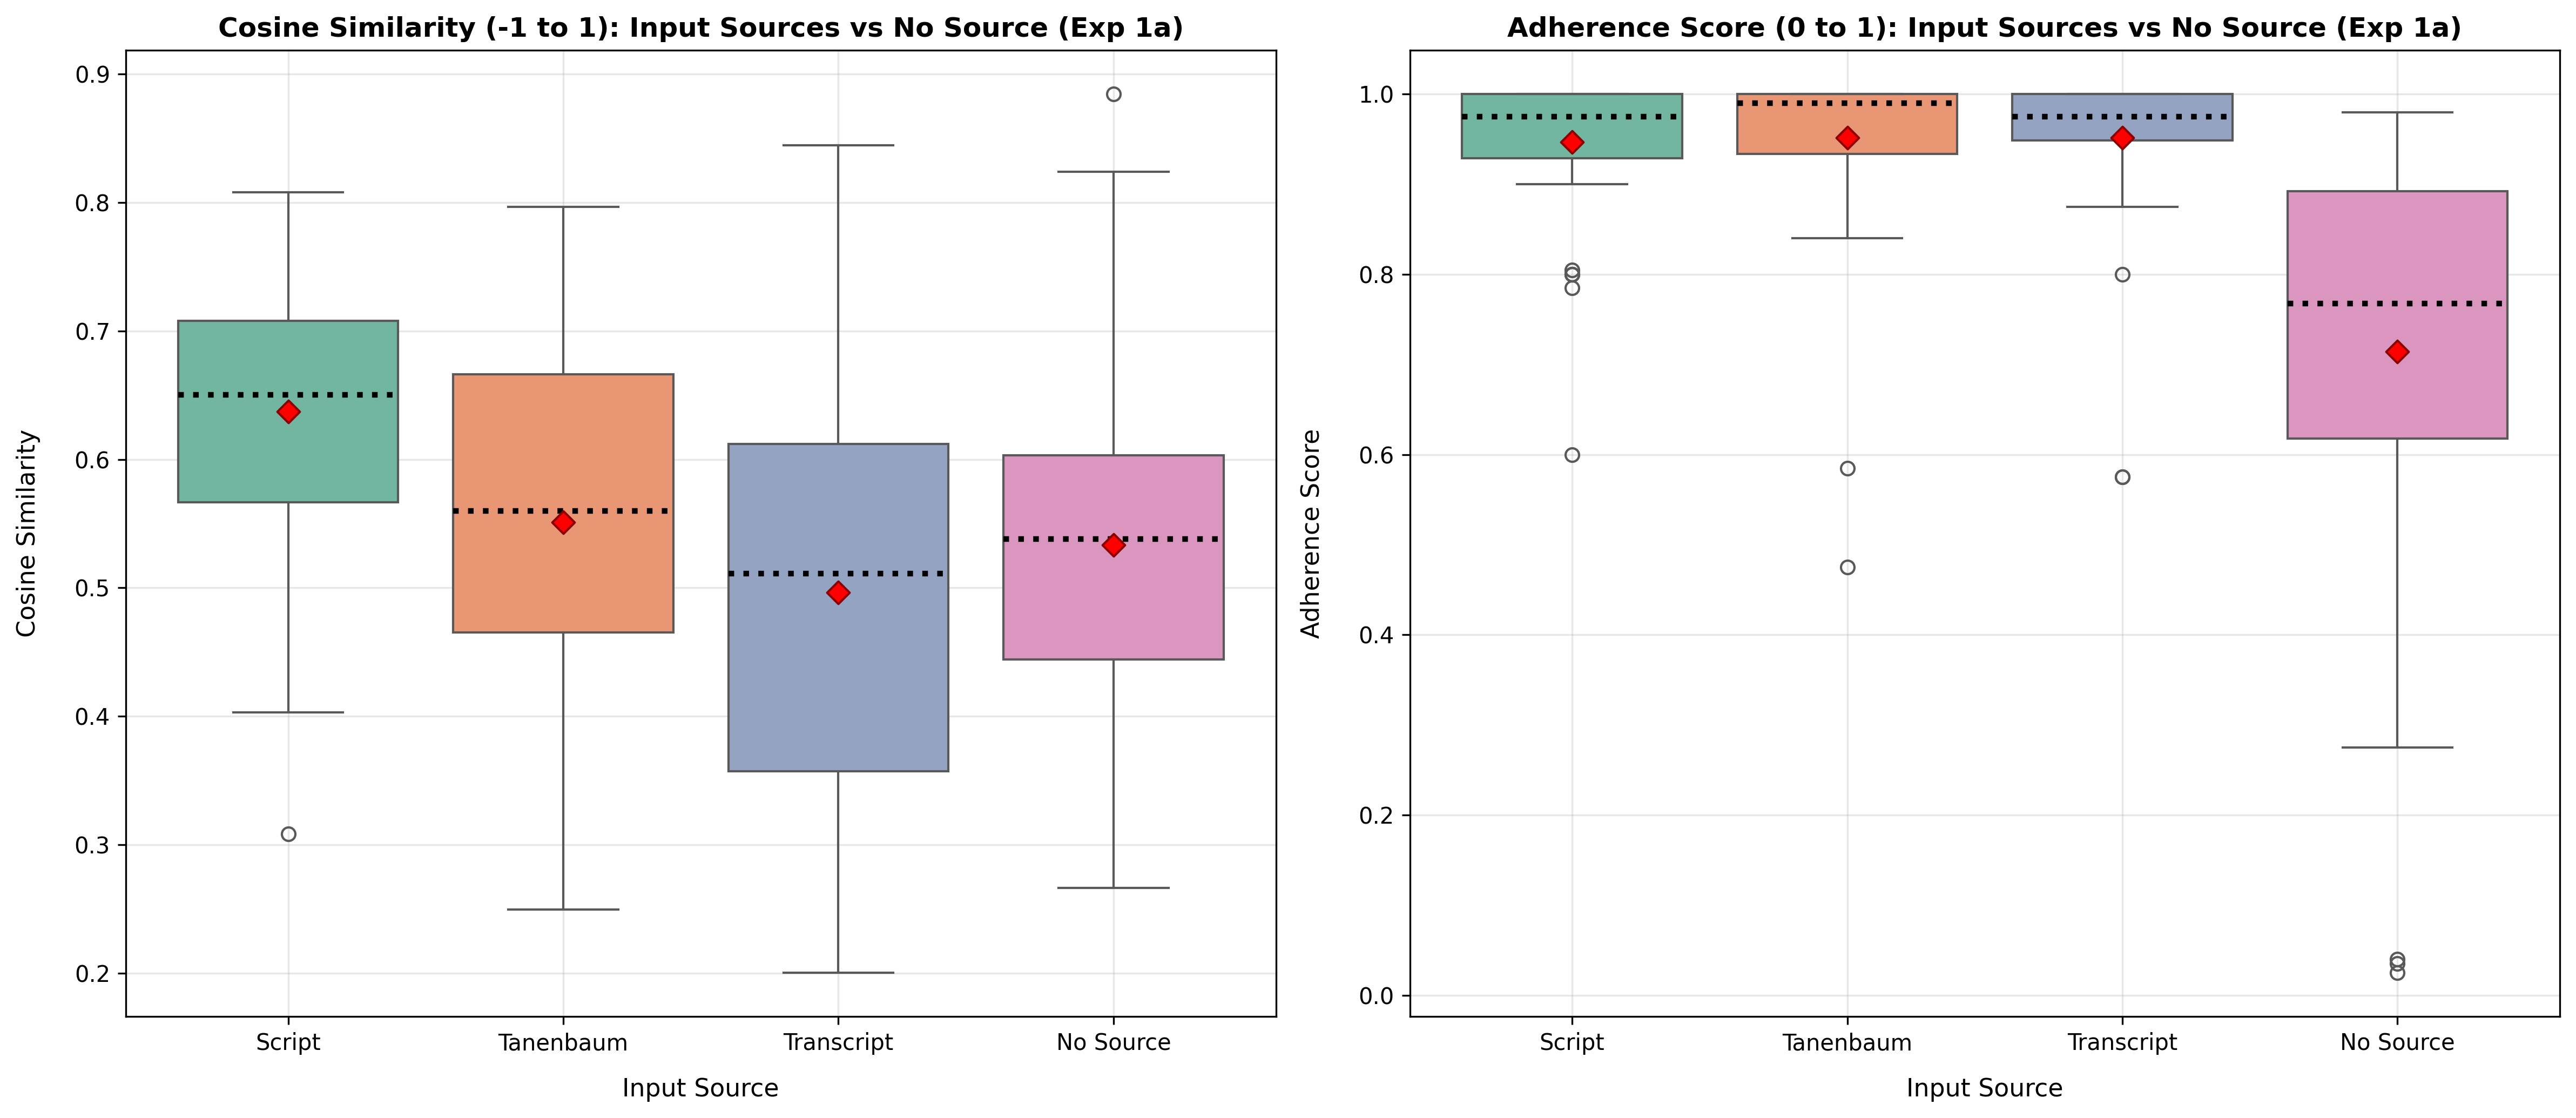


Summary Statistics:


cosine_similarity                 adherence_score                
                          mean       std count            mean       std count
input_source                                                                  
no_source             0.533408  0.125514    84        0.713988  0.218106    84
script                0.637166  0.107065    56        0.947054  0.075364    56
tanenbaum             0.551117  0.131404    56        0.951696  0.092713    56
transcript            0.496441  0.177308    56        0.951607  0.084521    56


Effect Analysis (compared to no_source):

Cosine Similarity improvements over no_source:
  script: +0.1038 (+19.5%)
  tanenbaum: +0.0177 (+3.3%)
  transcript: +-0.0370 (-6.9%)

Adherence Score improvements over no_source:
  script: +0.2331 (+32.6%)
  tanenbaum: +0.2377 (+33.3%)
  transcript: +0.2376 (+33.3%)

Input Source vs No Source comparison created successfully!


In [75]:
# Combined Input Source vs No Source Comparison
if exp1a_no_source_df is not None:
    print("Creating combined Input Source vs No Source comparison plot...")
    
    # Prepare regular exp1a data
    exp1a_regular = exp1a_df.copy()
    
    # Prepare no_source data - aggregate across all comparison sources
    exp1a_no_source_agg = exp1a_no_source_df.copy()
    exp1a_no_source_agg['input_source'] = 'no_source'  # Set all to 'no_source' for comparison
    
    # Combine regular exp1a data with aggregated no_source data
    comparison_df = pd.concat([exp1a_regular, exp1a_no_source_agg], ignore_index=True)
    
    # Create the comparison plot
    fig, ax = plt.subplots(1, 2, figsize=(16, 7))
    plots['exp1a_input_source_vs_no_source_comparison'] = fig
    
    # Calculate means for display
    comparison_means = comparison_df.groupby('input_source')[['cosine_similarity', 'adherence_score']].mean()
    
    print("Comparison means:")
    print("Cosine Similarity:")
    for source, mean_val in comparison_means['cosine_similarity'].items():
        print(f"  {source}: {mean_val:.4f}")
    print("\nAdherence Score:")
    for source, mean_val in comparison_means['adherence_score'].items():
        print(f"  {source}: {mean_val:.4f}")
    
    # Plot 1: Cosine Similarity
    create_seaborn_boxplot(comparison_df, 'input_source', 'cosine_similarity', ax[0], 
                          'Cosine Similarity: Input Sources vs No Source (Exp 1a)', 
                          'Cosine Similarity', 'Input Source',
                          custom_means=comparison_means['cosine_similarity'])
    
    # Plot 2: Adherence Score  
    create_seaborn_boxplot(comparison_df, 'input_source', 'adherence_score', ax[1],
                          'Adherence Score: Input Sources vs No Source (Exp 1a)', 
                          'Adherence Score', 'Input Source',
                          custom_means=comparison_means['adherence_score'])
    
    plt.tight_layout()
    plt.show()
    
    # Generate summary statistics table
    comparison_summary = comparison_df.groupby('input_source')[['cosine_similarity', 'adherence_score']].agg(['mean', 'std', 'count'])
    tables['exp1a_input_source_vs_no_source_summary'] = comparison_summary
    
    print("\nSummary Statistics:")
    display(comparison_summary)
    
    # Calculate effect sizes (difference in means)
    print("\nEffect Analysis (compared to no_source):")
    no_source_cosine_mean = comparison_means.loc['no_source', 'cosine_similarity']
    no_source_adherence_mean = comparison_means.loc['no_source', 'adherence_score']
    
    print("\nCosine Similarity improvements over no_source:")
    for source in ['script', 'tanenbaum', 'transcript']:
        if source in comparison_means.index:
            improvement = comparison_means.loc[source, 'cosine_similarity'] - no_source_cosine_mean
            improvement_pct = (improvement / no_source_cosine_mean) * 100
            print(f"  {source}: +{improvement:.4f} ({improvement_pct:+.1f}%)")
    
    print("\nAdherence Score improvements over no_source:")
    for source in ['script', 'tanenbaum', 'transcript']:
        if source in comparison_means.index:
            improvement = comparison_means.loc[source, 'adherence_score'] - no_source_adherence_mean
            improvement_pct = (improvement / no_source_adherence_mean) * 100
            print(f"  {source}: +{improvement:.4f} ({improvement_pct:+.1f}%)")
    
    print("\nInput Source vs No Source comparison created successfully!")
else:
    print("Skipping Input Source vs No Source comparison - exp1a_no_source data not available.")

## Save all tables and plots

In [76]:
def save_all_tables_and_plots():
    for name, df in tables.items():
        if name.startswith("exp1a_no_source"):
            output_dir = output_dir_exp1a_no_source
            table_name = name.replace("exp1a_no_source_", "")
        elif name.startswith("exp1a"):
            output_dir = output_dir_exp1a
            table_name = name.replace("exp1a_", "")
        elif name.startswith("exp1b"):
            output_dir = output_dir_exp1b
            table_name = name.replace("exp1b_", "")
        else:
            if "exp1" in name:
                base_filename = os.path.join(output_dir_exp1a, name)
                csv_path = f"{base_filename}.csv"
                df.to_csv(csv_path)
                print(f"Saved {csv_path}")
            continue

        base_filename = os.path.join(output_dir, table_name)
        
        csv_path = f"{base_filename}.csv"
        df.to_csv(csv_path)
        print(f"Saved {csv_path}")

    for name, fig in plots.items():
        if name.startswith("exp1a_no_source") or "no_source" in name:
            output_dir = output_plot_dir_exp1a_no_source
            plot_name = name.replace("exp1a_no_source_", "").replace("exp1a_", "")
        elif name.startswith("exp1a"):
            output_dir = output_plot_dir_exp1a
            plot_name = name.replace("exp1a_", "")
        elif name.startswith("exp1b"):
            output_dir = output_plot_dir_exp1b
            plot_name = name.replace("exp1b_", "")
        else:
            if "exp1" in name:
                base_filename = os.path.join(output_plot_dir_exp1a, name)
                png_path = f"{base_filename}.png"
                fig.savefig(png_path, bbox_inches='tight')
                print(f"Saved {png_path}")
            continue
        
        base_filename = os.path.join(output_dir, plot_name)
        
        png_path = f"{base_filename}.png"
        fig.savefig(png_path, bbox_inches='tight')
        print(f"Saved {png_path}")

save_all_tables_and_plots()

Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1a/metrics_by_llm.csv
Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1a/metrics_by_input_source.csv
Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1a/metrics_by_prompt_type.csv
Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1a/metrics_by_layer.csv
Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1a/cosine_sim_llm_vs_input_source.csv
Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1a/cosine_sim_llm_vs_prompt_type.csv
Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1a/adherence_llm_vs_prompt_type.csv
Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1a/adherence_llm_vs_input_source.csv
Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1b/metrics_by_llm.csv
Sav